# Default Probability Prediction

In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from lightgbm import LGBMClassifier, early_stopping
from sklearn.model_selection import train_test_split, StratifiedKFold
import optuna
from sklearn.metrics import roc_auc_score, RocCurveDisplay
import shap

Loading the training dataset:

In [2]:
file_name = "train_LTFS.csv"
df_loan_default = pd.read_csv(file_name)
df_loan_default

,UniqueID,disbursed_amount,asset_cost,ltv,branch_id,supplier_id,manufacturer_id,Current_pincode_ID,Date.of.Birth,Employment.Type,...,SEC.SANCTIONED.AMOUNT,SEC.DISBURSED.AMOUNT,PRIMARY.INSTAL.AMT,SEC.INSTAL.AMT,NEW.ACCTS.IN.LAST.SIX.MONTHS,DELINQUENT.ACCTS.IN.LAST.SIX.MONTHS,AVERAGE.ACCT.AGE,CREDIT.HISTORY.LENGTH,NO.OF_INQUIRIES,loan_default
0,420825,50578,58400,89.55,67,22807,45,1441,01-01-84,Salaried,...,0,0,0,0,0,0,0yrs 0mon,0yrs 0mon,0,0
1,537409,47145,65550,73.23,67,22807,45,1502,31-07-85,Self employed,...,0,0,1991,0,0,1,1yrs 11mon,1yrs 11mon,0,1
2,417566,53278,61360,89.63,67,22807,45,1497,24-08-85,Self employed,...,0,0,0,0,0,0,0yrs 0mon,0yrs 0mon,0,0
3,624493,57513,66113,88.48,67,22807,45,1501,30-12-93,Self employed,...,0,0,31,0,0,0,0yrs 8mon,1yrs 3mon,1,1
4,539055,52378,60300,88.39,67,22807,45,1495,09-12-77,Self employed,...,0,0,0,0,0,0,0yrs 0mon,0yrs 0mon,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
233149,626432,63213,105405,60.72,34,20700,48,1050,01-08-88,Salaried,...,0,0,4084,0,0,0,1yrs 9mon,3yrs 3mon,0,0
233150,606141,73651,100600,74.95,34,23775,51,990,05-12-88,Self employed,...,0,0,1565,0,0,0,0yrs 6mon,0yrs 6mon,0,0
233151,613658,33484,71212,48.45,77,22186,86,2299,01-06-76,Salaried,...,0,0,0,0,0,0,0yrs 0mon,0yrs 0mon,0,0
233152,548084,34259,73286,49.10,77,22186,86,2299,26-03-94,Salaried,...,0,0,0,0,0,0,0yrs 0mon,0yrs 0mon,0,0


Performing Exploratory Data Analysis (EDA) on a dataset:

In [3]:
df_loan_default.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 233154 entries, 0 to 233153
Data columns (total 41 columns):
 #   Column                               Non-Null Count   Dtype  
---  ------                               --------------   -----  
 0   UniqueID                             233154 non-null  int64  
 1   disbursed_amount                     233154 non-null  int64  
 2   asset_cost                           233154 non-null  int64  
 3   ltv                                  233154 non-null  float64
 4   branch_id                            233154 non-null  int64  
 5   supplier_id                          233154 non-null  int64  
 6   manufacturer_id                      233154 non-null  int64  
 7   Current_pincode_ID                   233154 non-null  int64  
 8   Date.of.Birth                        233154 non-null  object 
 9   Employment.Type                      225493 non-null  object 
 10  DisbursalDate                        233154 non-null  object 
 11  State_ID     

In [4]:
df_loan_default.isnull().sum()

UniqueID                                  0
disbursed_amount                          0
asset_cost                                0
ltv                                       0
branch_id                                 0
supplier_id                               0
manufacturer_id                           0
Current_pincode_ID                        0
Date.of.Birth                             0
Employment.Type                        7661
DisbursalDate                             0
State_ID                                  0
Employee_code_ID                          0
MobileNo_Avl_Flag                         0
Aadhar_flag                               0
PAN_flag                                  0
VoterID_flag                              0
Driving_flag                              0
Passport_flag                             0
PERFORM_CNS.SCORE                         0
PERFORM_CNS.SCORE.DESCRIPTION             0
PRI.NO.OF.ACCTS                           0
PRI.ACTIVE.ACCTS                

In [5]:
df_loan_default.describe()

,UniqueID,disbursed_amount,asset_cost,ltv,branch_id,supplier_id,manufacturer_id,Current_pincode_ID,State_ID,Employee_code_ID,...,SEC.OVERDUE.ACCTS,SEC.CURRENT.BALANCE,SEC.SANCTIONED.AMOUNT,SEC.DISBURSED.AMOUNT,PRIMARY.INSTAL.AMT,SEC.INSTAL.AMT,NEW.ACCTS.IN.LAST.SIX.MONTHS,DELINQUENT.ACCTS.IN.LAST.SIX.MONTHS,NO.OF_INQUIRIES,loan_default
count,233154.000000,233154.000000,2.331540e+05,233154.000000,233154.000000,233154.000000,233154.000000,233154.000000,233154.000000,233154.000000,...,233154.000000,2.331540e+05,2.331540e+05,2.331540e+05,2.331540e+05,2.331540e+05,233154.000000,233154.000000,233154.000000,233154.000000
mean,535917.573376,54356.993528,7.586507e+04,74.746530,72.936094,19638.635035,69.028054,3396.880247,7.262243,1549.477148,...,0.007244,5.427793e+03,7.295923e+03,7.179998e+03,1.310548e+04,3.232684e+02,0.381833,0.097481,0.206615,0.217071
std,68315.693711,12971.314171,1.894478e+04,11.456636,69.834995,3491.949566,22.141304,2238.147502,4.482230,975.261278,...,0.111079,1.702370e+05,1.831560e+05,1.825925e+05,1.513679e+05,1.555369e+04,0.955107,0.384439,0.706498,0.412252
min,417428.000000,13320.000000,3.700000e+04,10.030000,1.000000,10524.000000,45.000000,1.000000,1.000000,1.000000,...,0.000000,-5.746470e+05,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000
25%,476786.250000,47145.000000,6.571700e+04,68.880000,14.000000,16535.000000,48.000000,1511.000000,4.000000,713.000000,...,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000
50%,535978.500000,53803.000000,7.094600e+04,76.800000,61.000000,20333.000000,86.000000,2970.000000,6.000000,1451.000000,...,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000
75%,595039.750000,60413.000000,7.920175e+04,83.670000,130.000000,23000.000000,86.000000,5677.000000,10.000000,2362.000000,...,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,1.999000e+03,0.000000e+00,0.000000,0.000000,0.000000,0.000000
max,671084.000000,990572.000000,1.628992e+06,95.000000,261.000000,24803.000000,156.000000,7345.000000,22.000000,3795.000000,...,8.000000,3.603285e+07,3.000000e+07,3.000000e+07,2.564281e+07,4.170901e+06,35.000000,20.000000,36.000000,1.000000


Removing uninformative features: `UniqueID` (all values are unique) and `MobileNo_Avl_Flag` (constant feature):

In [6]:
df_loan_default = df_loan_default.drop(columns=["UniqueID", "MobileNo_Avl_Flag"], errors="ignore")
df_loan_default

,disbursed_amount,asset_cost,ltv,branch_id,supplier_id,manufacturer_id,Current_pincode_ID,Date.of.Birth,Employment.Type,DisbursalDate,...,SEC.SANCTIONED.AMOUNT,SEC.DISBURSED.AMOUNT,PRIMARY.INSTAL.AMT,SEC.INSTAL.AMT,NEW.ACCTS.IN.LAST.SIX.MONTHS,DELINQUENT.ACCTS.IN.LAST.SIX.MONTHS,AVERAGE.ACCT.AGE,CREDIT.HISTORY.LENGTH,NO.OF_INQUIRIES,loan_default
0,50578,58400,89.55,67,22807,45,1441,01-01-84,Salaried,03-08-18,...,0,0,0,0,0,0,0yrs 0mon,0yrs 0mon,0,0
1,47145,65550,73.23,67,22807,45,1502,31-07-85,Self employed,26-09-18,...,0,0,1991,0,0,1,1yrs 11mon,1yrs 11mon,0,1
2,53278,61360,89.63,67,22807,45,1497,24-08-85,Self employed,01-08-18,...,0,0,0,0,0,0,0yrs 0mon,0yrs 0mon,0,0
3,57513,66113,88.48,67,22807,45,1501,30-12-93,Self employed,26-10-18,...,0,0,31,0,0,0,0yrs 8mon,1yrs 3mon,1,1
4,52378,60300,88.39,67,22807,45,1495,09-12-77,Self employed,26-09-18,...,0,0,0,0,0,0,0yrs 0mon,0yrs 0mon,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
233149,63213,105405,60.72,34,20700,48,1050,01-08-88,Salaried,26-10-18,...,0,0,4084,0,0,0,1yrs 9mon,3yrs 3mon,0,0
233150,73651,100600,74.95,34,23775,51,990,05-12-88,Self employed,23-10-18,...,0,0,1565,0,0,0,0yrs 6mon,0yrs 6mon,0,0
233151,33484,71212,48.45,77,22186,86,2299,01-06-76,Salaried,24-10-18,...,0,0,0,0,0,0,0yrs 0mon,0yrs 0mon,0,0
233152,34259,73286,49.10,77,22186,86,2299,26-03-94,Salaried,29-09-18,...,0,0,0,0,0,0,0yrs 0mon,0yrs 0mon,0,0


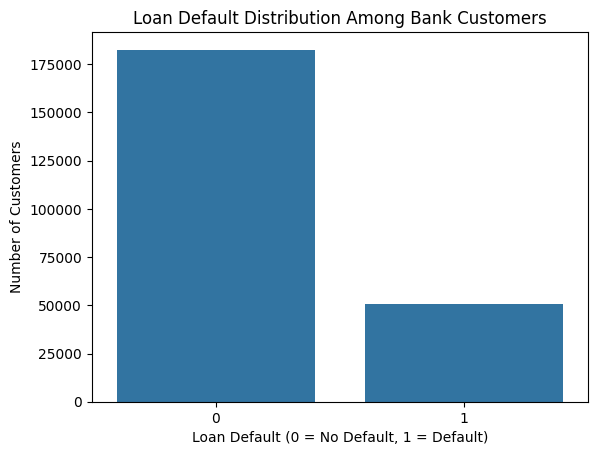

In [7]:
sns.countplot(data=df_loan_default, x="loan_default")
plt.title("Loan Default Distribution Among Bank Customers")
plt.xlabel("Loan Default (0 = No Default, 1 = Default)")
plt.ylabel("Number of Customers")
plt.show()

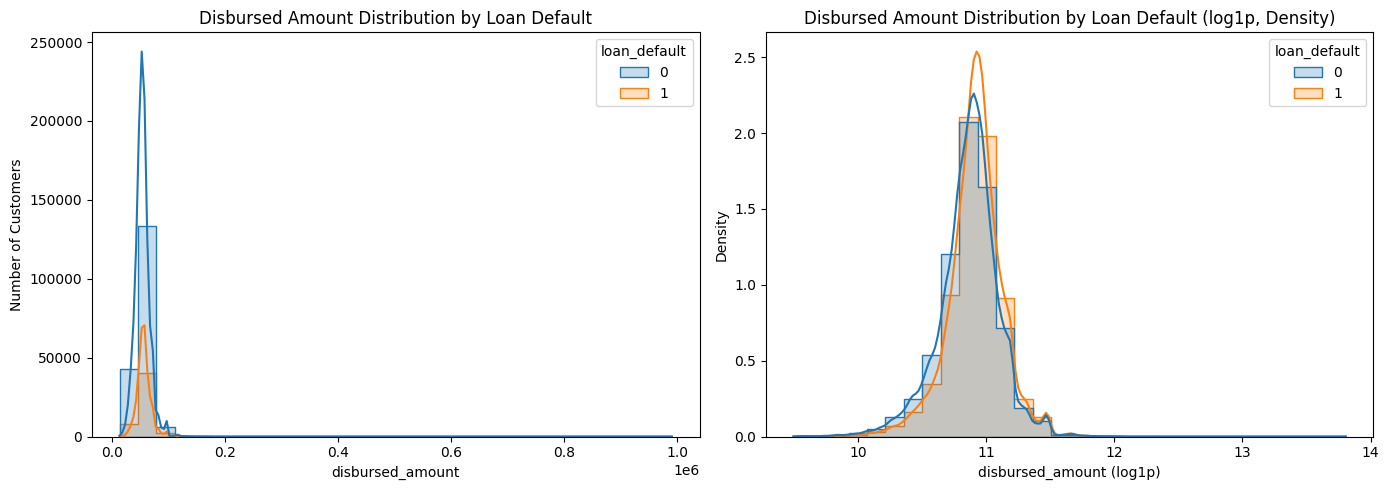

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(data=df_loan_default, x="disbursed_amount", hue="loan_default", bins=30, kde=True, element="step", ax=axes[0])
axes[0].set_title("Disbursed Amount Distribution by Loan Default")
axes[0].set_ylabel("Number of Customers")

sns.histplot(
    data=df_loan_default, 
    x=np.log1p(df_loan_default["disbursed_amount"]), 
    hue="loan_default", 
    bins=30, 
    kde=True, 
    stat="density", 
    common_norm=False, 
    element="step", 
    ax=axes[1]
)
axes[1].set_title("Disbursed Amount Distribution by Loan Default (log1p, Density)")
axes[1].set_xlabel("disbursed_amount (log1p)")
axes[1].set_ylabel("Density")

plt.tight_layout()
plt.show()

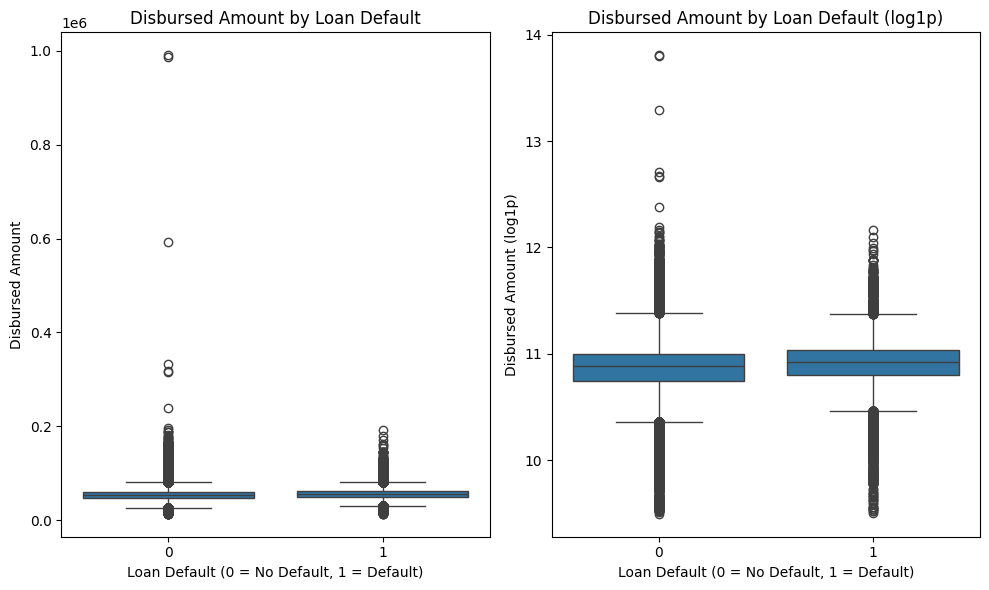

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(10, 6))

sns.boxplot(data=df_loan_default, x="loan_default", y="disbursed_amount", ax=axes[0])
axes[0].set_title("Disbursed Amount by Loan Default")
axes[0].set_xlabel("Loan Default (0 = No Default, 1 = Default)")
axes[0].set_ylabel("Disbursed Amount")

sns.boxplot(data=df_loan_default, x="loan_default", y=np.log1p(df_loan_default["disbursed_amount"]), ax=axes[1])
axes[1].set_title("Disbursed Amount by Loan Default (log1p)")
axes[1].set_xlabel("Loan Default (0 = No Default, 1 = Default)")
axes[1].set_ylabel("Disbursed Amount (log1p)")

plt.tight_layout()
plt.show()

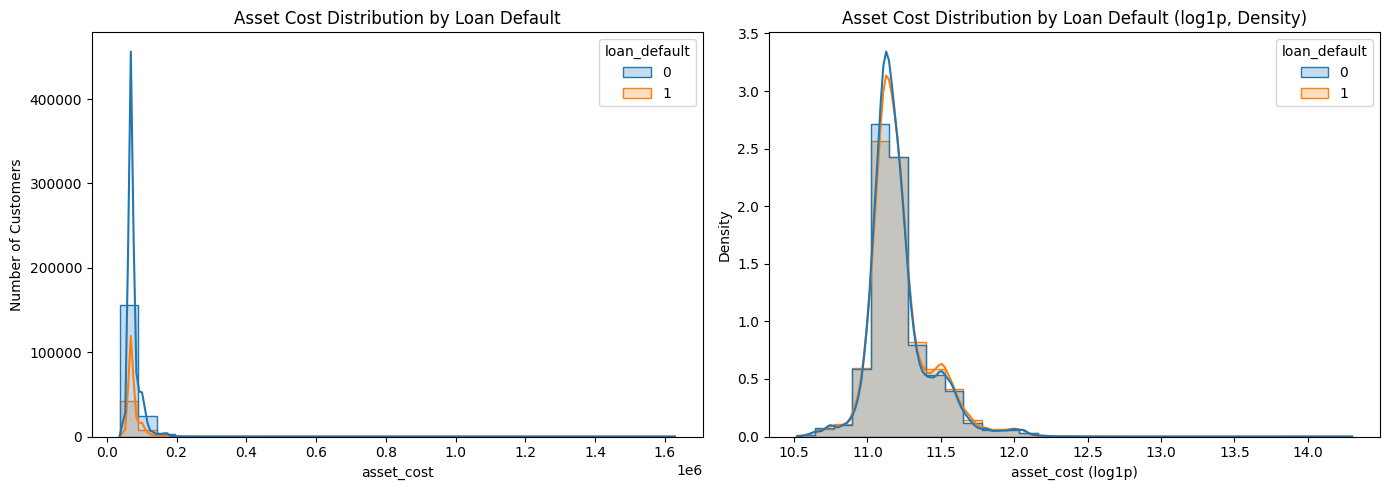

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(data=df_loan_default, x="asset_cost", hue="loan_default", bins=30, kde=True, element="step", ax=axes[0])
axes[0].set_title("Asset Cost Distribution by Loan Default")
axes[0].set_ylabel("Number of Customers")

sns.histplot(
    data=df_loan_default, 
    x=np.log1p(df_loan_default["asset_cost"]), 
    hue="loan_default", bins=30, 
    kde=True, 
    stat="density", 
    common_norm=False, 
    element="step", 
    ax=axes[1]
)
axes[1].set_title("Asset Cost Distribution by Loan Default (log1p, Density)")
axes[1].set_xlabel("asset_cost (log1p)")
axes[1].set_ylabel("Density")

plt.tight_layout()
plt.show()

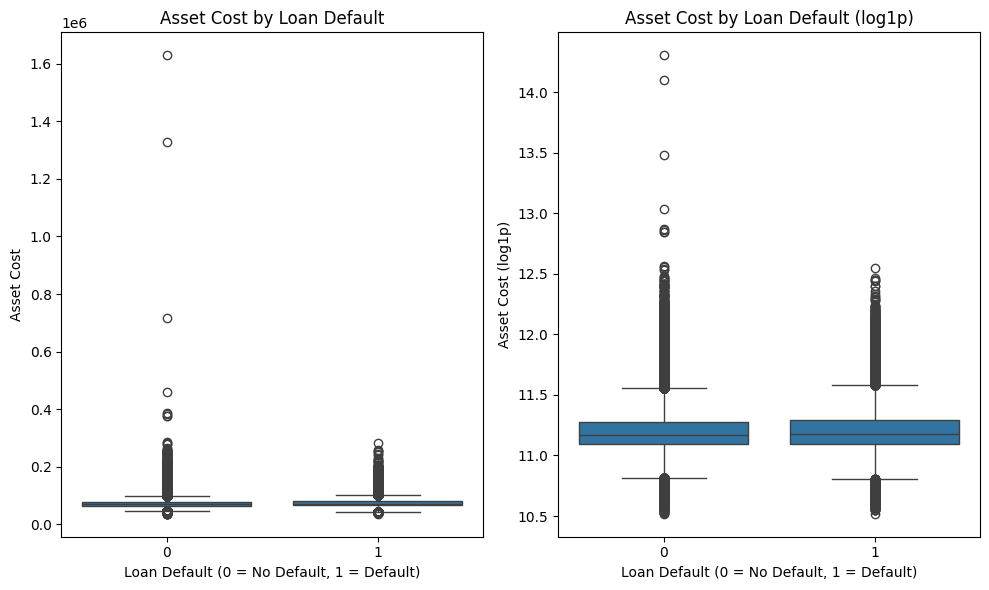

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(10,6))

sns.boxplot(data=df_loan_default, x="loan_default", y="asset_cost", ax=axes[0])
axes[0].set_title("Asset Cost by Loan Default")
axes[0].set_xlabel("Loan Default (0 = No Default, 1 = Default)")
axes[0].set_ylabel("Asset Cost")

sns.boxplot(data=df_loan_default, x="loan_default", y=np.log1p(df_loan_default["asset_cost"]), ax=axes[1])
axes[1].set_title("Asset Cost by Loan Default (log1p)")
axes[1].set_xlabel("Loan Default (0 = No Default, 1 = Default)")
axes[1].set_ylabel("Asset Cost (log1p)")

plt.tight_layout()
plt.show()

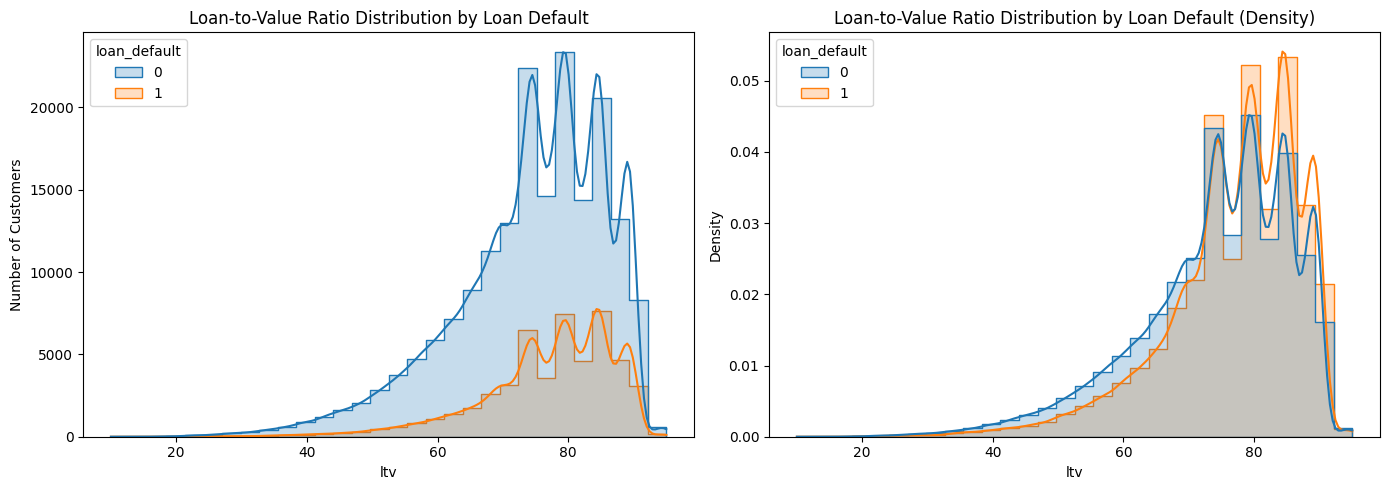

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(data=df_loan_default, x="ltv", hue="loan_default", bins=30, kde=True, element="step", ax=axes[0])
axes[0].set_title("Loan-to-Value Ratio Distribution by Loan Default")
axes[0].set_ylabel("Number of Customers")

sns.histplot(data=df_loan_default, x="ltv", hue="loan_default", bins=30, kde=True, stat="density", common_norm=False, element="step", ax=axes[1])
axes[1].set_title("Loan-to-Value Ratio Distribution by Loan Default (Density)")
axes[1].set_ylabel("Density")

plt.tight_layout()
plt.show()

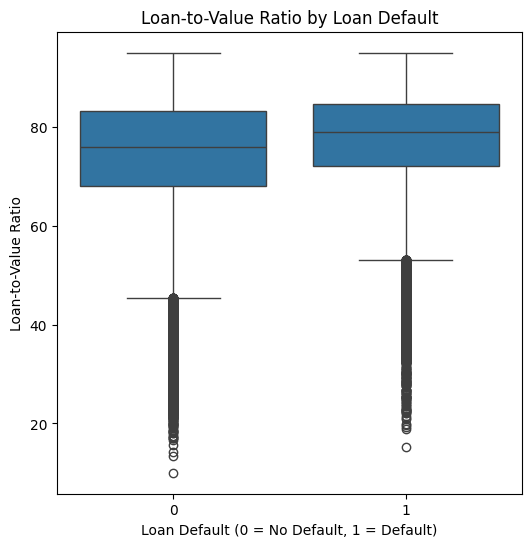

In [13]:
plt.figure(figsize=(6, 6))
sns.boxplot(data=df_loan_default, x="loan_default", y="ltv")
plt.title("Loan-to-Value Ratio by Loan Default")
plt.xlabel("Loan Default (0 = No Default, 1 = Default)")
plt.ylabel("Loan-to-Value Ratio")
plt.show()

Converting `Date.of.Birth` and `DisbursalDate` to `datetime` and creating the `age` feature:

In [14]:
df_loan_default["Date.of.Birth"] = pd.to_datetime(df_loan_default["Date.of.Birth"], format="%d-%m-%y", dayfirst=True)
df_loan_default["DisbursalDate"] = pd.to_datetime(df_loan_default["DisbursalDate"], format="%d-%m-%y", dayfirst=True)

mask = (df_loan_default["Date.of.Birth"].dt.year > df_loan_default["DisbursalDate"].dt.year)
df_loan_default.loc[mask, "Date.of.Birth"] -= pd.DateOffset(years=100)

df_loan_default["age"] = (df_loan_default["DisbursalDate"] - df_loan_default["Date.of.Birth"]).dt.days // 365

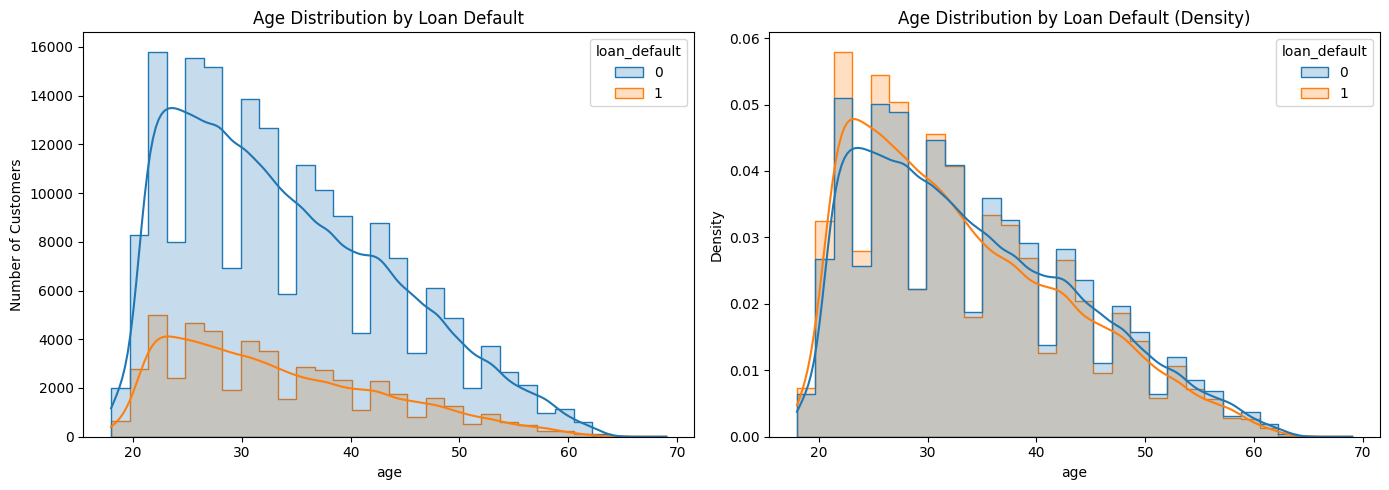

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(data=df_loan_default, x="age", hue="loan_default", bins=30, kde=True, element="step", ax=axes[0])
axes[0].set_title("Age Distribution by Loan Default")
axes[0].set_ylabel("Number of Customers")

sns.histplot(data=df_loan_default, x="age", hue="loan_default", bins=30, kde=True, stat="density", common_norm=False, element="step", ax=axes[1])
axes[1].set_title("Age Distribution by Loan Default (Density)")
axes[1].set_ylabel("Density")

plt.tight_layout()
plt.show()

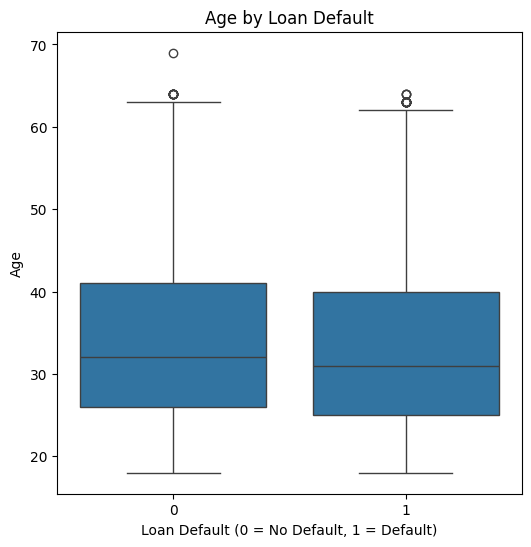

In [16]:
plt.figure(figsize=(6, 6))
sns.boxplot(data=df_loan_default, x="loan_default", y="age")
plt.title("Age by Loan Default")
plt.xlabel("Loan Default (0 = No Default, 1 = Default)")
plt.ylabel("Age")
plt.show()

Creating date-based features: `disbursal_day`, `disbursal_weekday`, `disbursal_month`, `days_to_month_end`, and `day_of_year`:

In [17]:
df_loan_default["disbursal_day"] = df_loan_default["DisbursalDate"].dt.day.astype("int")
df_loan_default["disbursal_weekday"] = df_loan_default["DisbursalDate"].dt.weekday.astype("int")
df_loan_default["disbursal_month"] = df_loan_default["DisbursalDate"].dt.month.astype("int")
df_loan_default["days_to_month_end"] = (df_loan_default["DisbursalDate"].dt.daysinmonth - df_loan_default["DisbursalDate"].dt.day).astype("int")
df_loan_default["day_of_year"] = df_loan_default["DisbursalDate"].dt.dayofyear.astype("int")

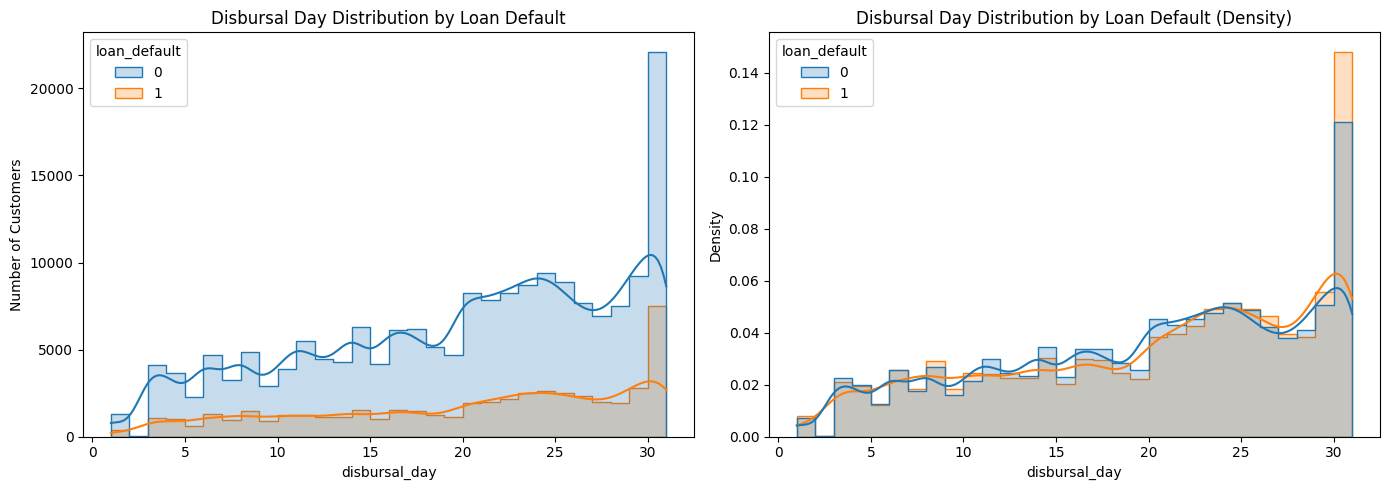

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(data=df_loan_default, x="disbursal_day", hue="loan_default", bins=30, kde=True, element="step", ax=axes[0])
axes[0].set_title("Disbursal Day Distribution by Loan Default")
axes[0].set_ylabel("Number of Customers")

sns.histplot(
    data=df_loan_default, 
    x="disbursal_day", 
    hue="loan_default", 
    bins=30, 
    kde=True, 
    stat="density", 
    common_norm=False, 
    element="step", 
    ax=axes[1]
)
axes[1].set_title("Disbursal Day Distribution by Loan Default (Density)")
axes[1].set_ylabel("Density")

plt.tight_layout()
plt.show()

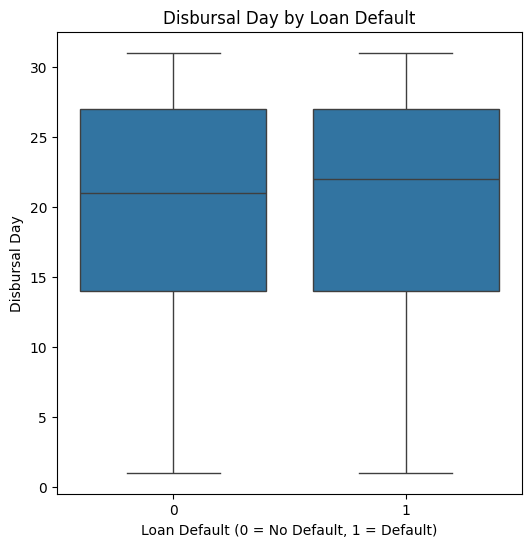

In [19]:
plt.figure(figsize=(6, 6))
sns.boxplot(data=df_loan_default, x="loan_default", y="disbursal_day")
plt.title("Disbursal Day by Loan Default")
plt.xlabel("Loan Default (0 = No Default, 1 = Default)")
plt.ylabel("Disbursal Day")
plt.show()

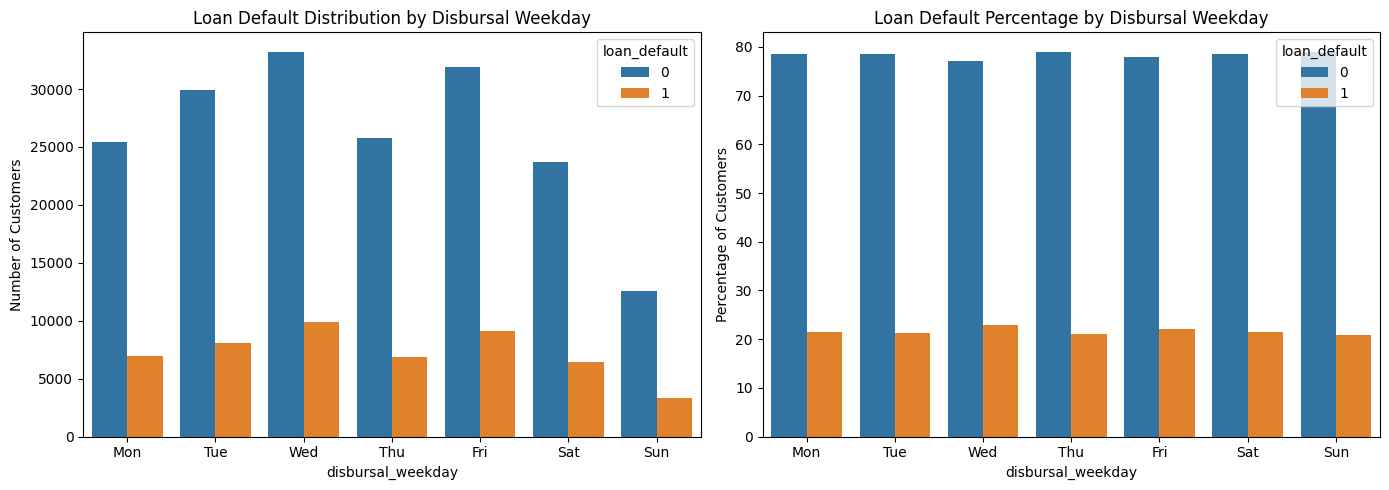

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

weekday_labels = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]

sns.countplot(data=df_loan_default, x="disbursal_weekday", hue="loan_default", ax=axes[0])
axes[0].set_title("Loan Default Distribution by Disbursal Weekday")
axes[0].set_ylabel("Number of Customers")
axes[0].set_xticks(range(7))
axes[0].set_xticklabels(weekday_labels)

df_percent = (
    df_loan_default
    .groupby("disbursal_weekday")["loan_default"]
    .value_counts(normalize=True)
    .mul(100)
    .rename("percent")
    .reset_index()
)

sns.barplot(data=df_percent, x="disbursal_weekday", y="percent", hue="loan_default", ax=axes[1])
axes[1].set_title("Loan Default Percentage by Disbursal Weekday")
axes[1].set_ylabel("Percentage of Customers")
axes[1].set_xticks(range(7))
axes[1].set_xticklabels(weekday_labels)

plt.tight_layout()
plt.show()

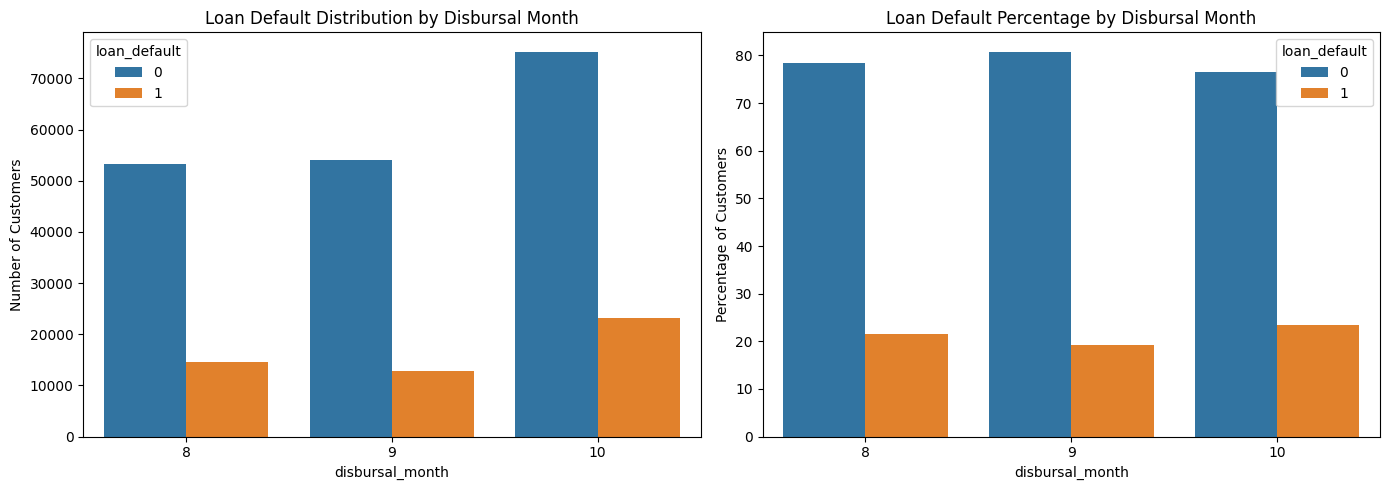

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.countplot(data=df_loan_default, x="disbursal_month", hue="loan_default", ax=axes[0])
axes[0].set_title("Loan Default Distribution by Disbursal Month")
axes[0].set_ylabel("Number of Customers")

df_percent = (
    df_loan_default
    .groupby("disbursal_month")["loan_default"]
    .value_counts(normalize=True)
    .mul(100)
    .rename("percent")
    .reset_index()
)

sns.barplot(data=df_percent, x="disbursal_month", y="percent", hue="loan_default", ax=axes[1])
axes[1].set_title("Loan Default Percentage by Disbursal Month")
axes[1].set_ylabel("Percentage of Customers")

plt.tight_layout()
plt.show()

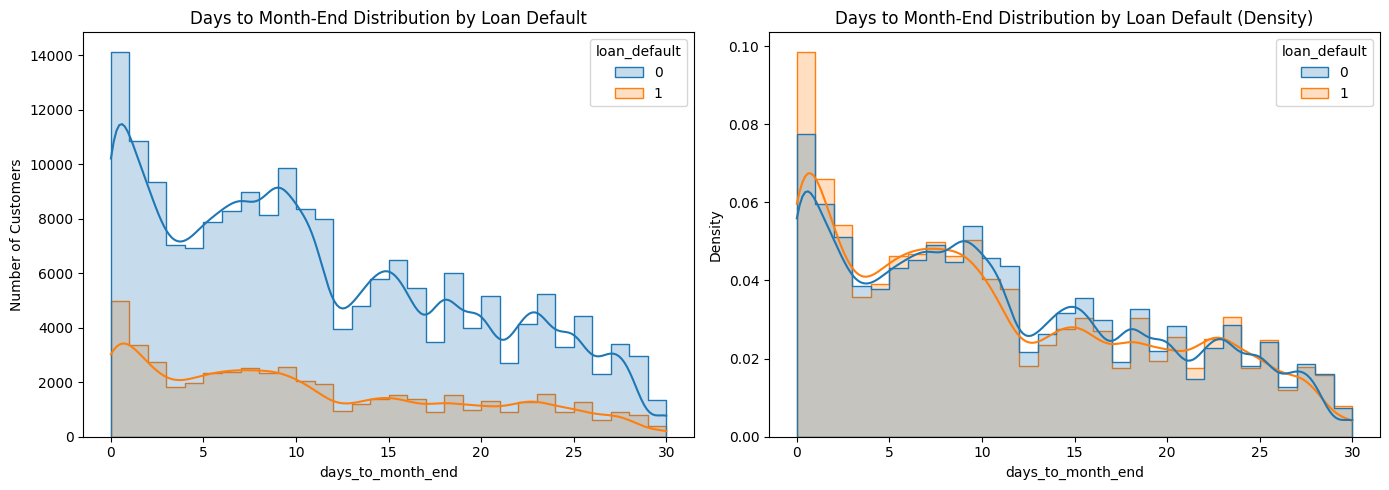

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(data=df_loan_default, x="days_to_month_end", hue="loan_default", bins=30, kde=True, element="step", ax=axes[0])
axes[0].set_title("Days to Month-End Distribution by Loan Default")
axes[0].set_ylabel("Number of Customers")

sns.histplot(
    data=df_loan_default, 
    x="days_to_month_end", 
    hue="loan_default", 
    bins=30, 
    kde=True, 
    stat="density", 
    common_norm=False, 
    element="step", 
    ax=axes[1]
)
axes[1].set_title("Days to Month-End Distribution by Loan Default (Density)")
axes[1].set_ylabel("Density")

plt.tight_layout()
plt.show()

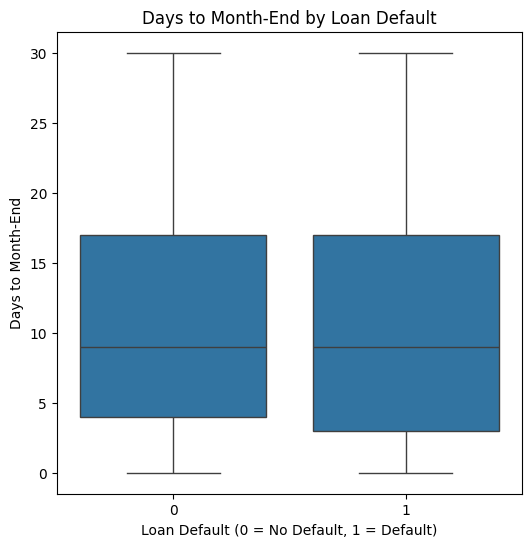

In [23]:
plt.figure(figsize=(6, 6))
sns.boxplot(data=df_loan_default, x="loan_default", y="days_to_month_end")
plt.title("Days to Month-End by Loan Default")
plt.xlabel("Loan Default (0 = No Default, 1 = Default)")
plt.ylabel("Days to Month-End")
plt.show()

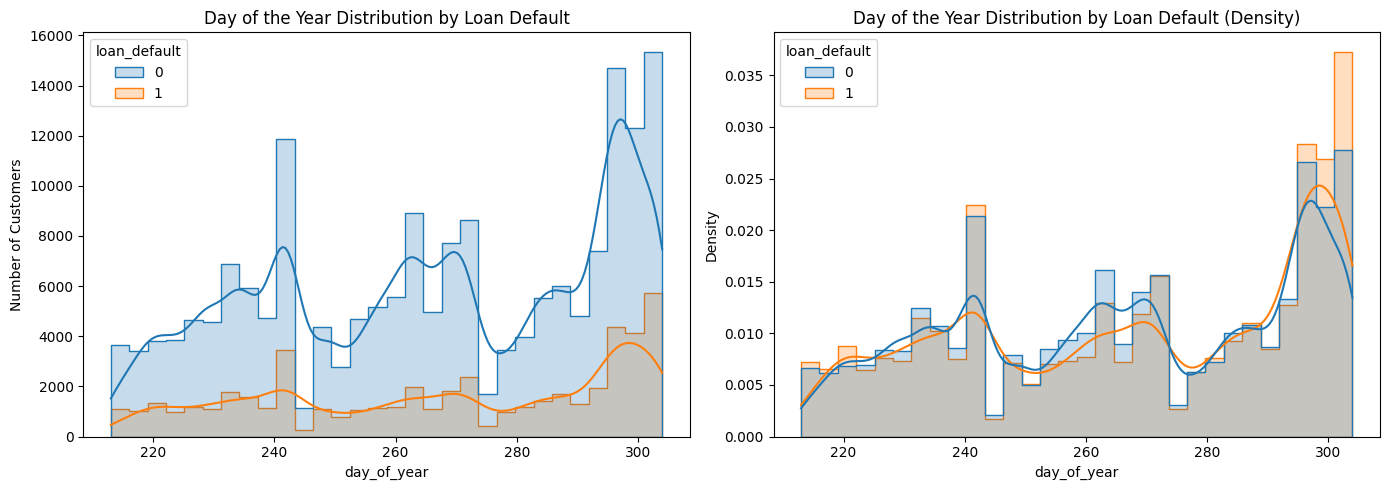

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(data=df_loan_default, x="day_of_year", hue="loan_default", bins=30, kde=True, element="step", ax=axes[0])
axes[0].set_title("Day of the Year Distribution by Loan Default")
axes[0].set_ylabel("Number of Customers")

sns.histplot(
    data=df_loan_default, 
    x="day_of_year", 
    hue="loan_default", 
    bins=30, 
    kde=True, 
    stat="density", 
    common_norm=False, 
    element="step", 
    ax=axes[1]
)
axes[1].set_title("Day of the Year Distribution by Loan Default (Density)")
axes[1].set_ylabel("Density")

plt.tight_layout()
plt.show()

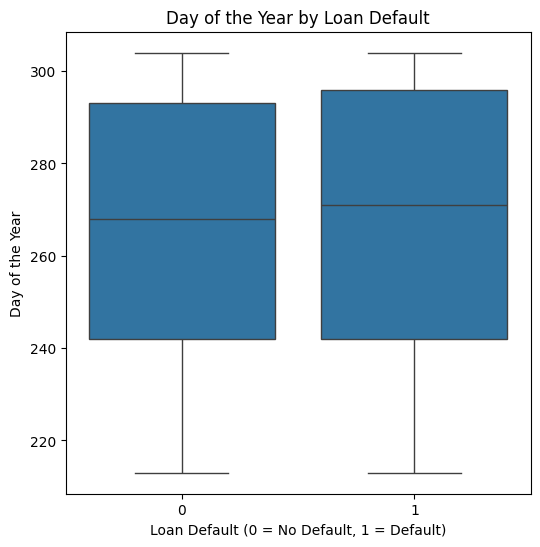

In [25]:
plt.figure(figsize=(6, 6))
sns.boxplot(data=df_loan_default, x="loan_default", y="day_of_year")
plt.title("Day of the Year by Loan Default")
plt.xlabel("Loan Default (0 = No Default, 1 = Default)")
plt.ylabel("Day of the Year")
plt.show()

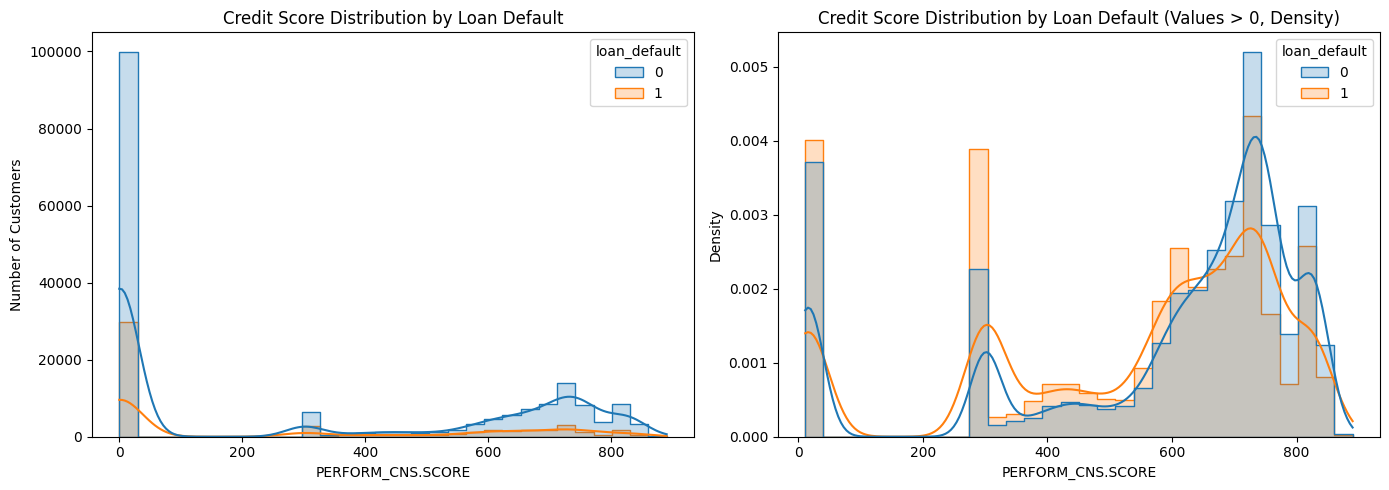

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(data=df_loan_default, x="PERFORM_CNS.SCORE", hue="loan_default", bins=30, kde=True, element="step", ax=axes[0])
axes[0].set_title("Credit Score Distribution by Loan Default")
axes[0].set_ylabel("Number of Customers")

sns.histplot(
    data=df_loan_default[df_loan_default["PERFORM_CNS.SCORE"] > 0], 
    x="PERFORM_CNS.SCORE", 
    hue="loan_default", 
    bins=30, 
    kde=True, 
    stat="density", 
    common_norm=False, 
    element="step", 
    ax=axes[1]
)
axes[1].set_title("Credit Score Distribution by Loan Default (Values > 0, Density)")
axes[1].set_ylabel("Density")

plt.tight_layout()
plt.show()

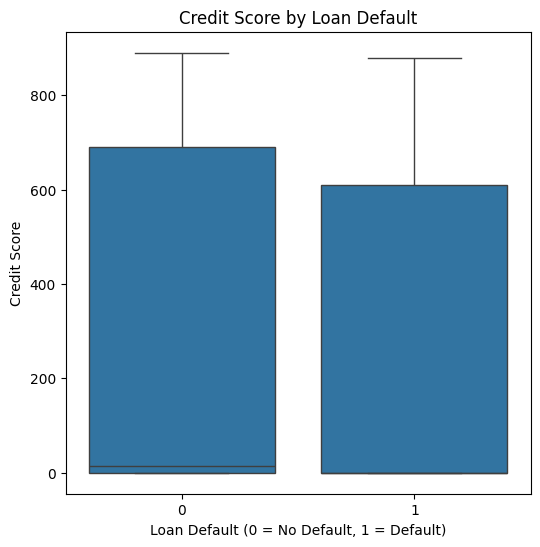

In [27]:
plt.figure(figsize=(6, 6))
sns.boxplot(data=df_loan_default, x="loan_default", y="PERFORM_CNS.SCORE")
plt.title("Credit Score by Loan Default")
plt.xlabel("Loan Default (0 = No Default, 1 = Default)")
plt.ylabel("Credit Score")
plt.show()

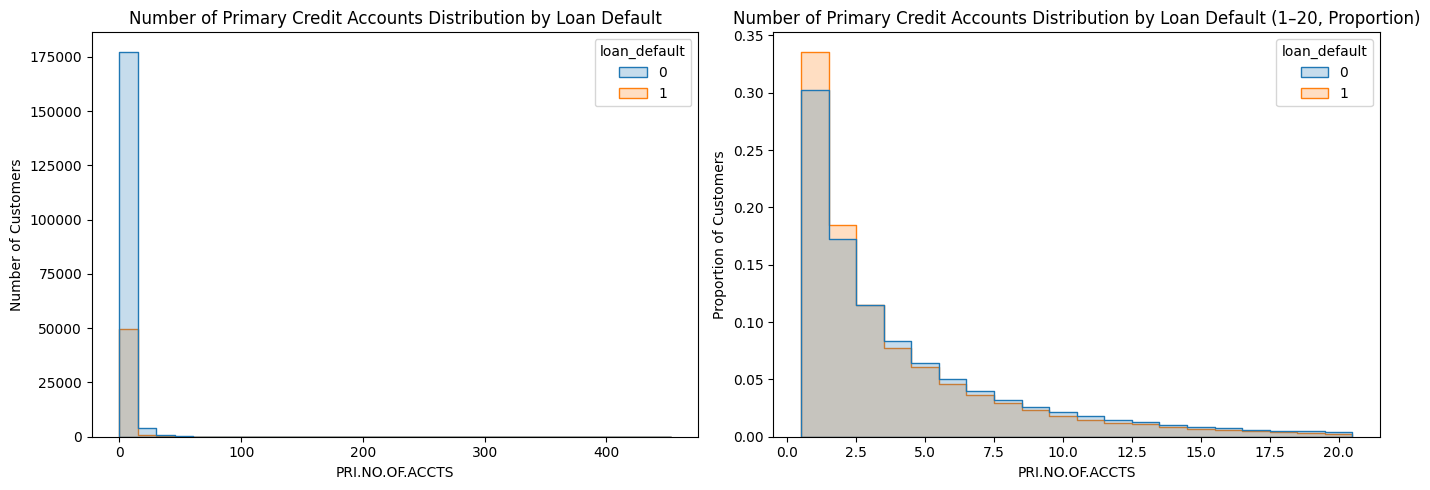

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(data=df_loan_default, x="PRI.NO.OF.ACCTS", hue="loan_default", bins=30, element="step", ax=axes[0])
axes[0].set_title("Number of Primary Credit Accounts Distribution by Loan Default")
axes[0].set_ylabel("Number of Customers")

sns.histplot(
    data=df_loan_default[df_loan_default["PRI.NO.OF.ACCTS"].between(1, 20)], 
    x="PRI.NO.OF.ACCTS", 
    hue="loan_default", 
    discrete=True, 
    stat="probability", 
    common_norm=False, 
    element="step", 
    ax=axes[1]
)
axes[1].set_title("Number of Primary Credit Accounts Distribution by Loan Default (1–20, Proportion)")
axes[1].set_ylabel("Proportion of Customers")

plt.tight_layout()
plt.show()

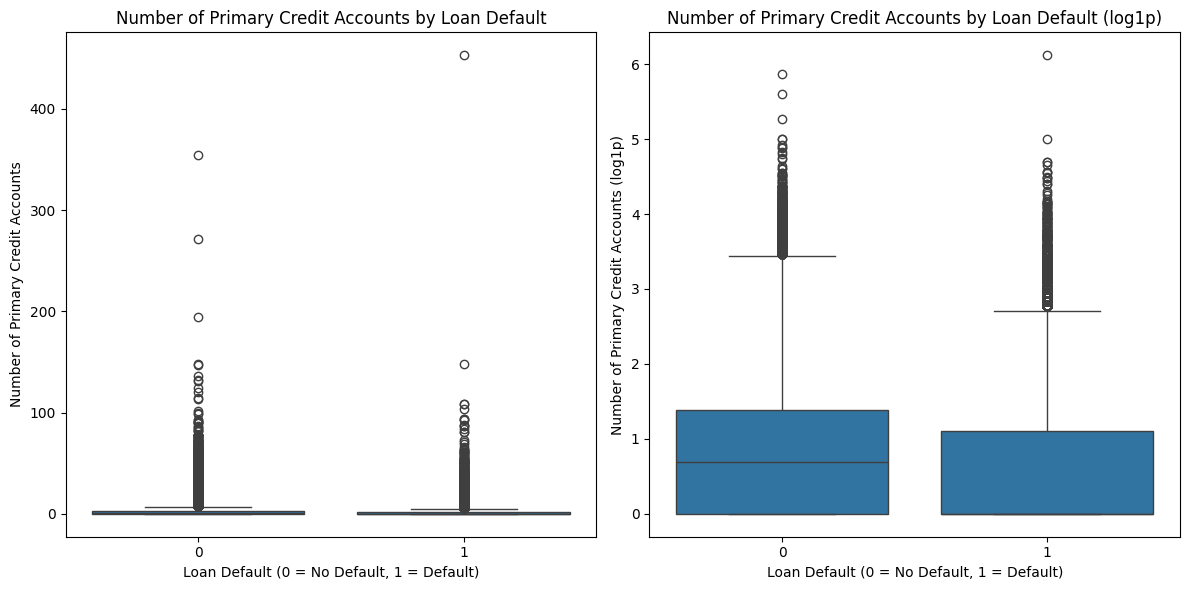

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

sns.boxplot(data=df_loan_default, x="loan_default", y="PRI.NO.OF.ACCTS", ax=axes[0])
axes[0].set_title("Number of Primary Credit Accounts by Loan Default")
axes[0].set_xlabel("Loan Default (0 = No Default, 1 = Default)")
axes[0].set_ylabel("Number of Primary Credit Accounts")

sns.boxplot(data=df_loan_default, x="loan_default", y=np.log1p(df_loan_default["PRI.NO.OF.ACCTS"]), ax=axes[1])
axes[1].set_title("Number of Primary Credit Accounts by Loan Default (log1p)")
axes[1].set_xlabel("Loan Default (0 = No Default, 1 = Default)")
axes[1].set_ylabel("Number of Primary Credit Accounts (log1p)")

plt.tight_layout()
plt.show()

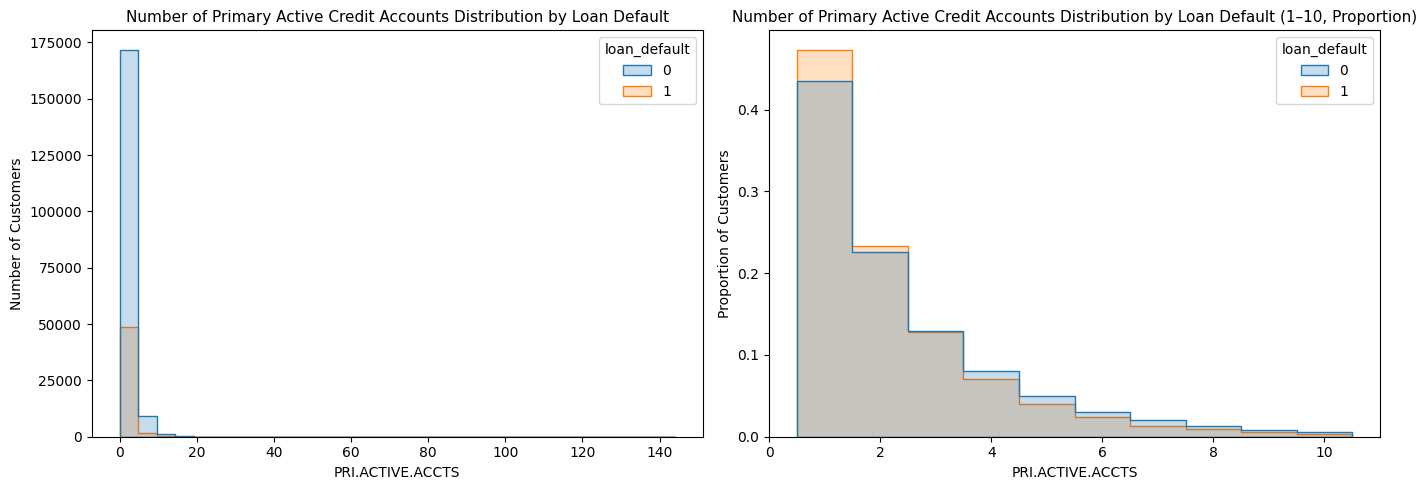

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(data=df_loan_default, x="PRI.ACTIVE.ACCTS", hue="loan_default", bins=30, element="step", ax=axes[0])
axes[0].set_title("Number of Primary Active Credit Accounts Distribution by Loan Default", fontsize=11)
axes[0].set_ylabel("Number of Customers")

sns.histplot(
    data=df_loan_default[df_loan_default["PRI.ACTIVE.ACCTS"].between(1, 10)],
    x="PRI.ACTIVE.ACCTS",
    hue="loan_default",
    discrete=True,
    stat="probability",
    common_norm=False,
    element="step",
    ax=axes[1]
)
axes[1].set_title("Number of Primary Active Credit Accounts Distribution by Loan Default (1–10, Proportion)", fontsize=11)
axes[1].set_ylabel("Proportion of Customers")

plt.tight_layout()
plt.show()

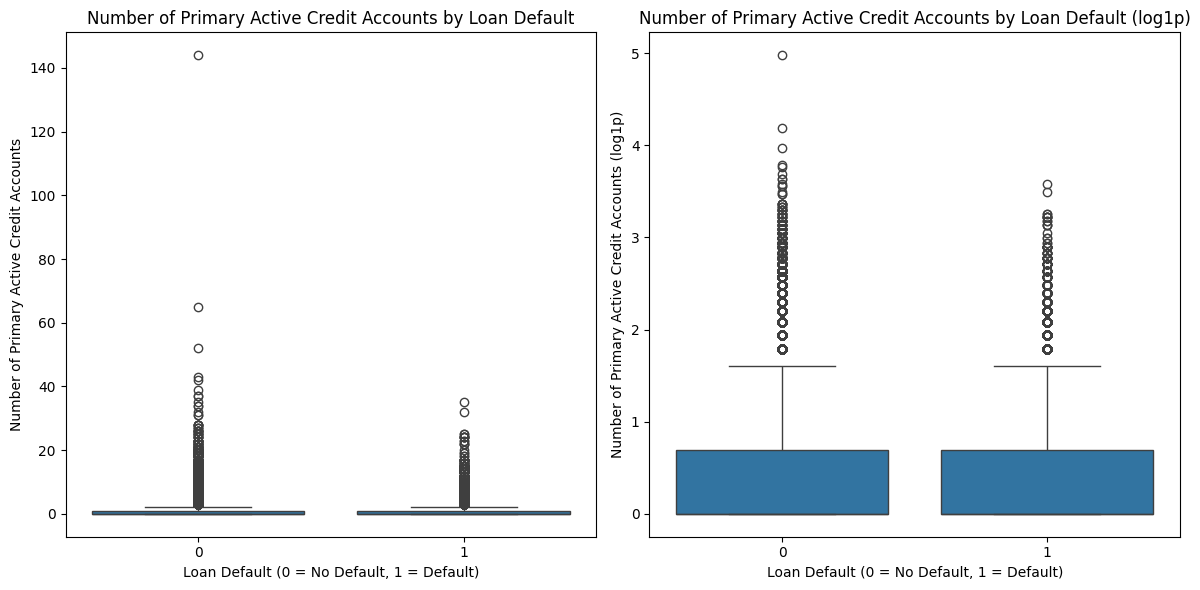

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

sns.boxplot(data=df_loan_default, x="loan_default", y="PRI.ACTIVE.ACCTS", ax=axes[0])
axes[0].set_title("Number of Primary Active Credit Accounts by Loan Default")
axes[0].set_xlabel("Loan Default (0 = No Default, 1 = Default)")
axes[0].set_ylabel("Number of Primary Active Credit Accounts")

sns.boxplot(data=df_loan_default, x="loan_default", y=np.log1p(df_loan_default["PRI.ACTIVE.ACCTS"]), ax=axes[1])
axes[1].set_title("Number of Primary Active Credit Accounts by Loan Default (log1p)")
axes[1].set_xlabel("Loan Default (0 = No Default, 1 = Default)")
axes[1].set_ylabel("Number of Primary Active Credit Accounts (log1p)")

plt.tight_layout()
plt.show()

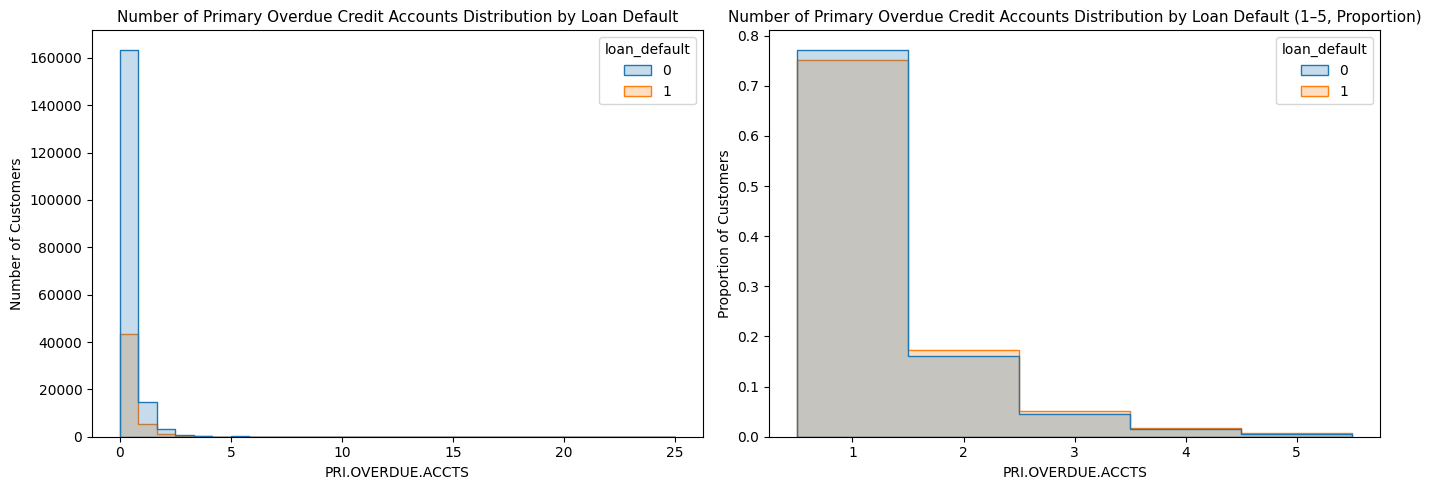

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(data=df_loan_default, x="PRI.OVERDUE.ACCTS", hue="loan_default", bins=30, element="step", ax=axes[0])
axes[0].set_title("Number of Primary Overdue Credit Accounts Distribution by Loan Default", fontsize=11)
axes[0].set_ylabel("Number of Customers")

sns.histplot(
    data=df_loan_default[df_loan_default["PRI.OVERDUE.ACCTS"].between(1, 5)], 
    x="PRI.OVERDUE.ACCTS", 
    hue="loan_default", 
    discrete=True,
    stat="probability",
    common_norm=False,
    element="step", 
    ax=axes[1]
)
axes[1].set_title("Number of Primary Overdue Credit Accounts Distribution by Loan Default (1–5, Proportion)", fontsize=11)
axes[1].set_ylabel("Proportion of Customers")

plt.tight_layout()
plt.show()

Checking for negative values:

In [33]:
(df_loan_default["PRI.CURRENT.BALANCE"] < 0).sum()

np.int64(448)

In [34]:
df_loan_default["PRI.CURRENT.BALANCE"].min()

np.int64(-6678296)

Replacing negative values with 0:

In [35]:
df_loan_default.loc[df_loan_default["PRI.CURRENT.BALANCE"] < 0, "PRI.CURRENT.BALANCE"] = 0

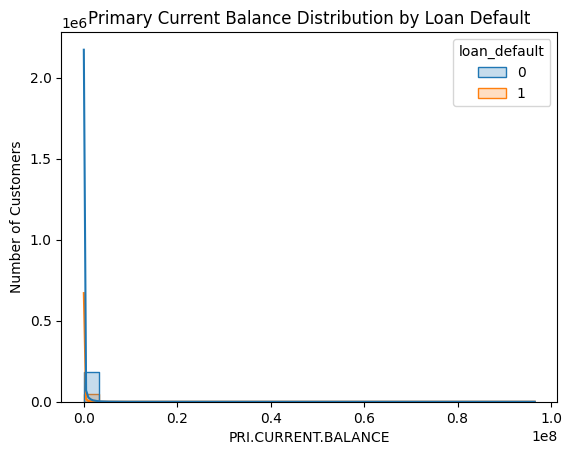

In [36]:
sns.histplot(data=df_loan_default, x="PRI.CURRENT.BALANCE", hue="loan_default", bins=30, kde=True, element="step")
plt.title("Primary Current Balance Distribution by Loan Default")
plt.ylabel("Number of Customers")
plt.show()

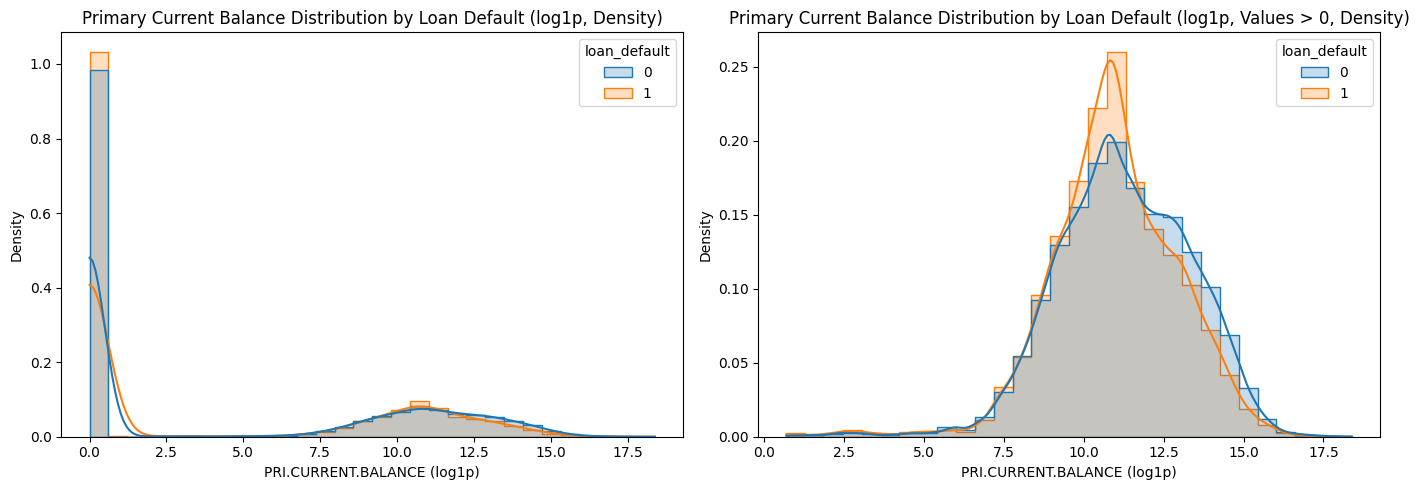

In [37]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(
    data=df_loan_default, 
    x=np.log1p(df_loan_default["PRI.CURRENT.BALANCE"]), 
    hue="loan_default", 
    bins=30, 
    kde=True, 
    stat="density", 
    common_norm=False, 
    element="step", 
    ax=axes[0]
)
axes[0].set_title("Primary Current Balance Distribution by Loan Default (log1p, Density)")
axes[0].set_xlabel("PRI.CURRENT.BALANCE (log1p)")
axes[0].set_ylabel("Density")

nonzero = df_loan_default[df_loan_default["PRI.CURRENT.BALANCE"] > 0]

sns.histplot(
    data=nonzero, 
    x=np.log1p(nonzero["PRI.CURRENT.BALANCE"]), 
    hue="loan_default", 
    bins=30, 
    kde=True, 
    stat="density", 
    common_norm=False, 
    element="step", 
    ax=axes[1]
)
axes[1].set_title("Primary Current Balance Distribution by Loan Default (log1p, Values > 0, Density)")
axes[1].set_xlabel("PRI.CURRENT.BALANCE (log1p)")
axes[1].set_ylabel("Density")

plt.tight_layout()
plt.show()

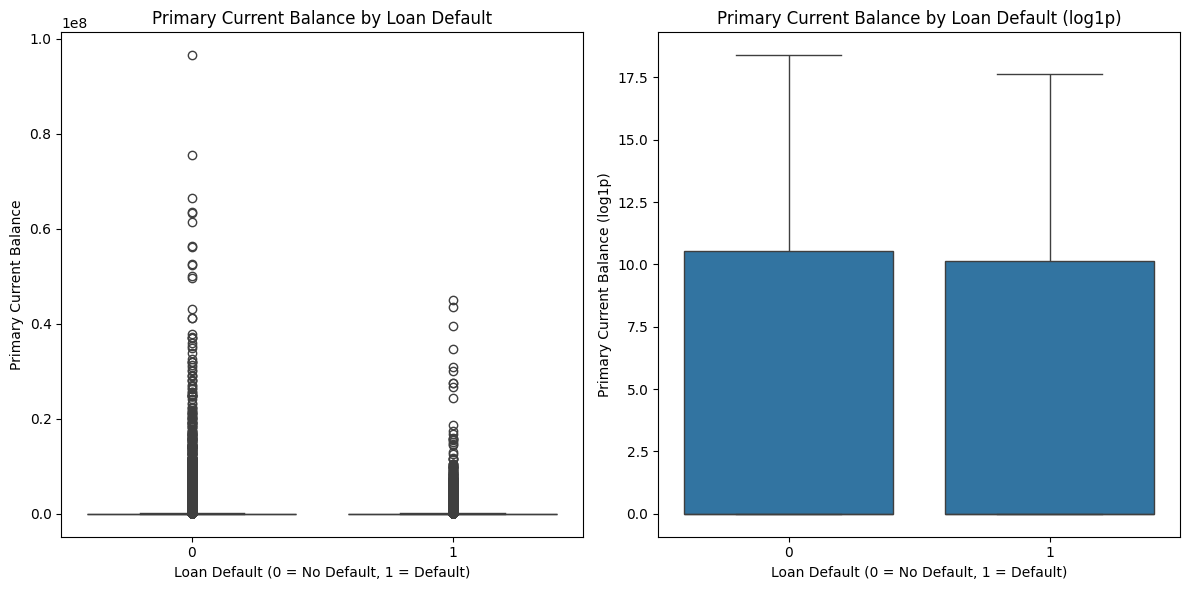

In [38]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

sns.boxplot(data=df_loan_default, x="loan_default", y="PRI.CURRENT.BALANCE", ax=axes[0])
axes[0].set_title("Primary Current Balance by Loan Default")
axes[0].set_xlabel("Loan Default (0 = No Default, 1 = Default)")
axes[0].set_ylabel("Primary Current Balance")

sns.boxplot(data=df_loan_default, x="loan_default", y=np.log1p(df_loan_default["PRI.CURRENT.BALANCE"]), ax=axes[1])
axes[1].set_title("Primary Current Balance by Loan Default (log1p)")
axes[1].set_xlabel("Loan Default (0 = No Default, 1 = Default)")
axes[1].set_ylabel("Primary Current Balance (log1p)")

plt.tight_layout()
plt.show()

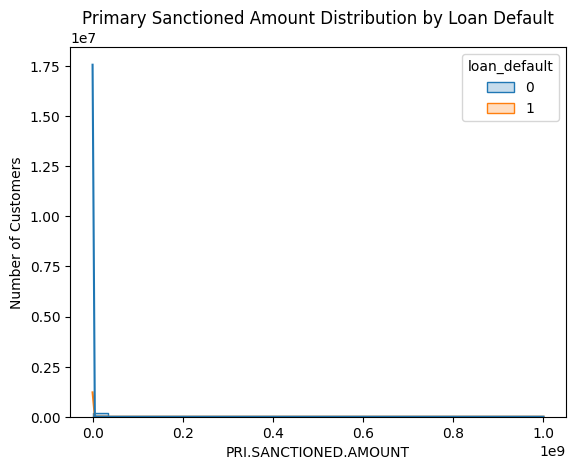

In [39]:
sns.histplot(data=df_loan_default, x="PRI.SANCTIONED.AMOUNT", hue="loan_default", bins=30, kde=True, element="step")
plt.title("Primary Sanctioned Amount Distribution by Loan Default")
plt.ylabel("Number of Customers")
plt.show()

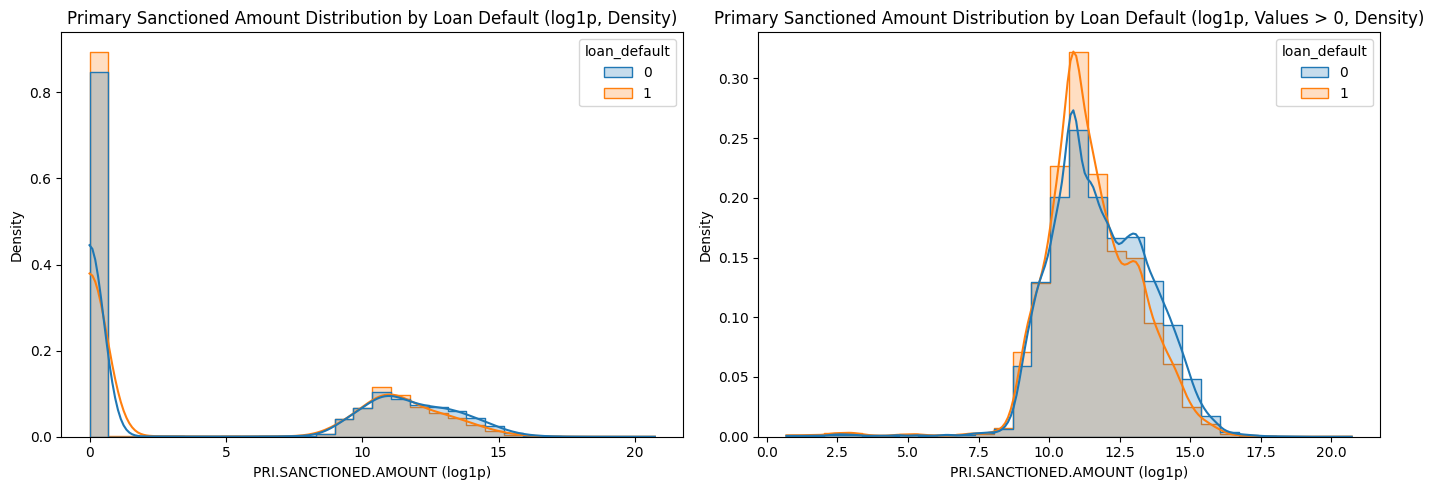

In [40]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(
    data=df_loan_default, 
    x=np.log1p(df_loan_default["PRI.SANCTIONED.AMOUNT"]), 
    hue="loan_default", 
    bins=30, 
    kde=True, 
    stat="density", 
    common_norm=False, 
    element="step", 
    ax=axes[0]
)
axes[0].set_title("Primary Sanctioned Amount Distribution by Loan Default (log1p, Density)")
axes[0].set_xlabel("PRI.SANCTIONED.AMOUNT (log1p)")
axes[0].set_ylabel("Density")

nonzero = df_loan_default[df_loan_default["PRI.SANCTIONED.AMOUNT"] > 0]

sns.histplot(
    data=nonzero, 
    x=np.log1p(nonzero["PRI.SANCTIONED.AMOUNT"]), 
    hue="loan_default", 
    bins=30, 
    kde=True, 
    stat="density", 
    common_norm=False, 
    element="step", 
    ax=axes[1]
)
axes[1].set_title("Primary Sanctioned Amount Distribution by Loan Default (log1p, Values > 0, Density)")
axes[1].set_xlabel("PRI.SANCTIONED.AMOUNT (log1p)")
axes[1].set_ylabel("Density")

plt.tight_layout()
plt.show()

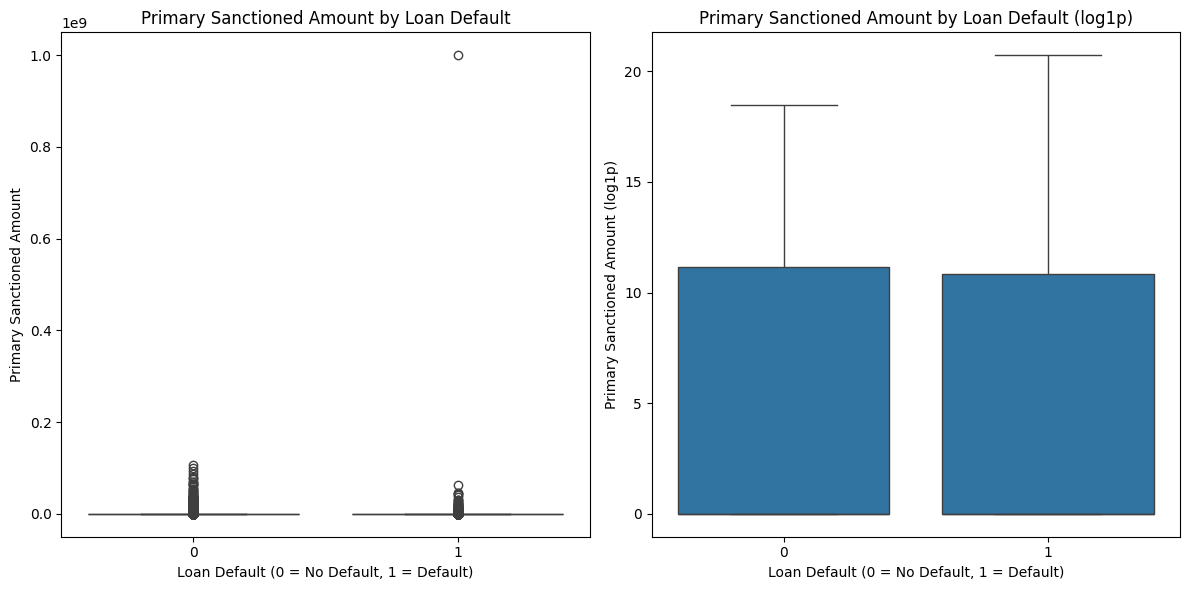

In [41]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

sns.boxplot(data=df_loan_default, x="loan_default", y="PRI.SANCTIONED.AMOUNT", ax=axes[0])
axes[0].set_title("Primary Sanctioned Amount by Loan Default")
axes[0].set_xlabel("Loan Default (0 = No Default, 1 = Default)")
axes[0].set_ylabel("Primary Sanctioned Amount")

sns.boxplot(data=df_loan_default, x="loan_default", y=np.log1p(df_loan_default["PRI.SANCTIONED.AMOUNT"]), ax=axes[1])
axes[1].set_title("Primary Sanctioned Amount by Loan Default (log1p)")
axes[1].set_xlabel("Loan Default (0 = No Default, 1 = Default)")
axes[1].set_ylabel("Primary Sanctioned Amount (log1p)")

plt.tight_layout()
plt.show()

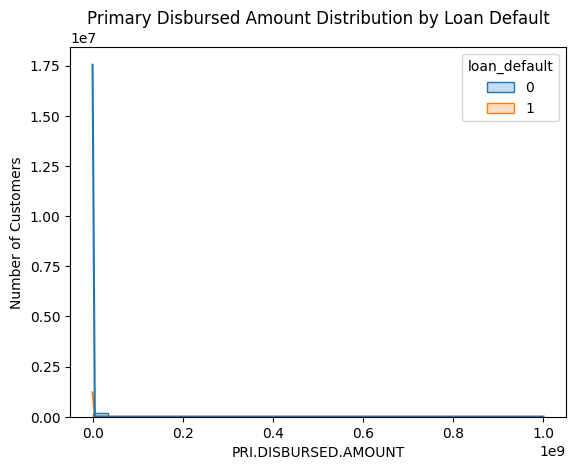

In [42]:
sns.histplot(data=df_loan_default, x="PRI.DISBURSED.AMOUNT", hue="loan_default", bins=30, kde=True, element="step")
plt.title("Primary Disbursed Amount Distribution by Loan Default")
plt.ylabel("Number of Customers")
plt.show()

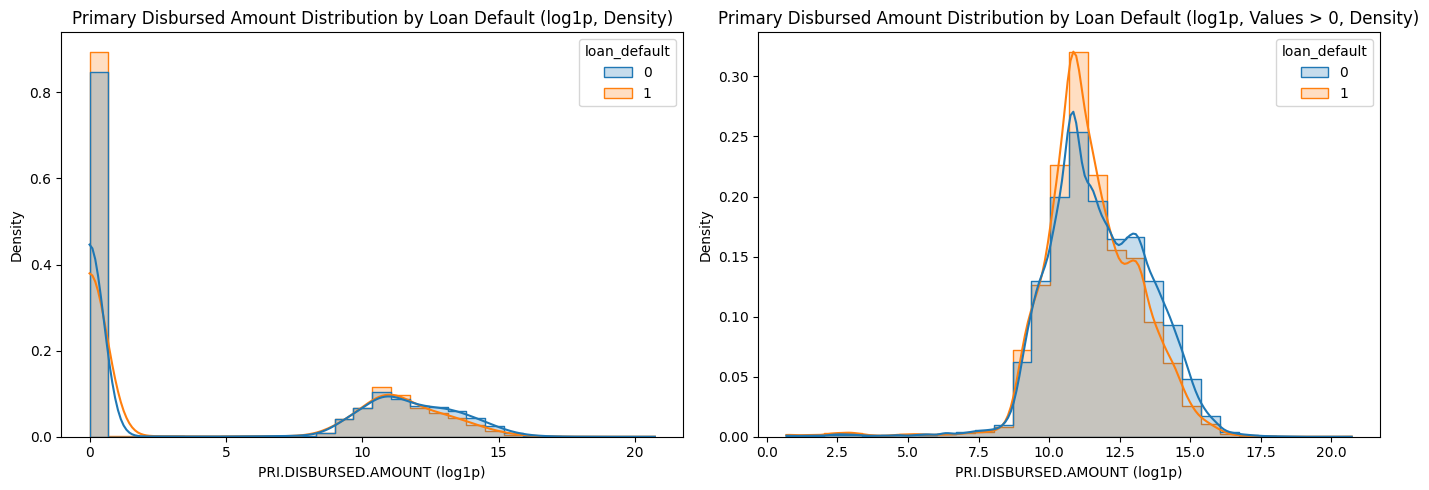

In [43]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(
    data=df_loan_default, 
    x=np.log1p(df_loan_default["PRI.DISBURSED.AMOUNT"]), 
    hue="loan_default", 
    bins=30, 
    kde=True, 
    stat="density", 
    common_norm=False, 
    element="step", 
    ax=axes[0]
)
axes[0].set_title("Primary Disbursed Amount Distribution by Loan Default (log1p, Density)")
axes[0].set_xlabel("PRI.DISBURSED.AMOUNT (log1p)")
axes[0].set_ylabel("Density")

nonzero = df_loan_default[df_loan_default["PRI.DISBURSED.AMOUNT"] > 0]

sns.histplot(
    data=nonzero, 
    x=np.log1p(nonzero["PRI.DISBURSED.AMOUNT"]), 
    hue="loan_default", 
    bins=30, 
    kde=True, 
    stat="density", 
    common_norm=False, 
    element="step", 
    ax=axes[1]
)
axes[1].set_title("Primary Disbursed Amount Distribution by Loan Default (log1p, Values > 0, Density)")
axes[1].set_xlabel("PRI.DISBURSED.AMOUNT (log1p)")
axes[1].set_ylabel("Density")

plt.tight_layout()
plt.show()

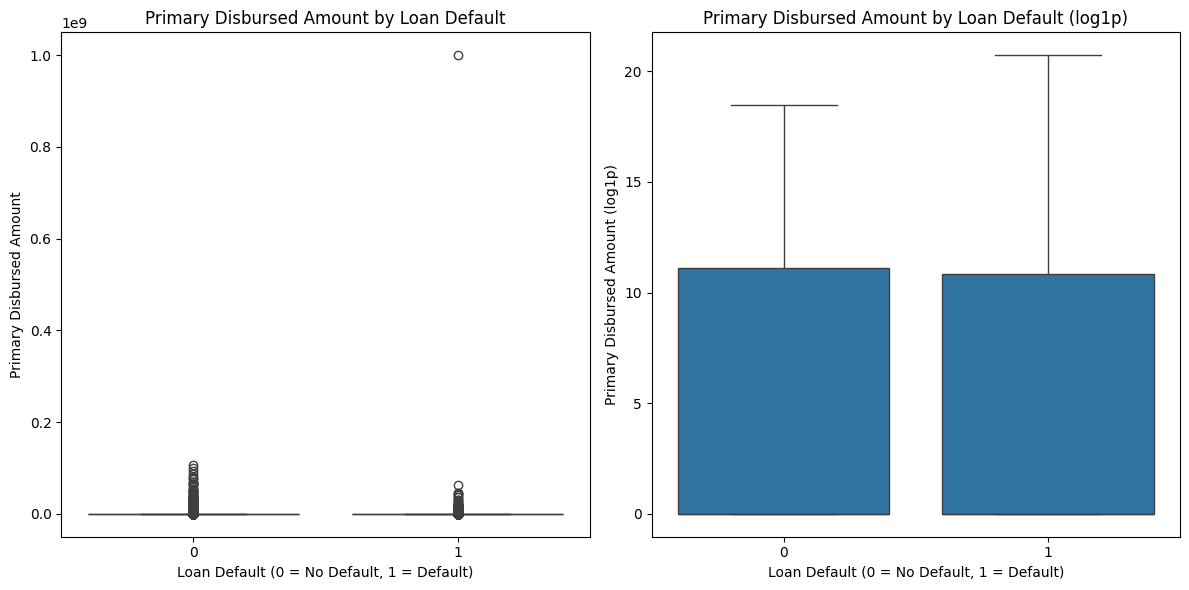

In [44]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

sns.boxplot(data=df_loan_default, x="loan_default", y="PRI.DISBURSED.AMOUNT", ax=axes[0])
axes[0].set_title("Primary Disbursed Amount by Loan Default")
axes[0].set_xlabel("Loan Default (0 = No Default, 1 = Default)")
axes[0].set_ylabel("Primary Disbursed Amount")

sns.boxplot(data=df_loan_default, x="loan_default", y=np.log1p(df_loan_default["PRI.DISBURSED.AMOUNT"]), ax=axes[1])
axes[1].set_title("Primary Disbursed Amount by Loan Default (log1p)")
axes[1].set_xlabel("Loan Default (0 = No Default, 1 = Default)")
axes[1].set_ylabel("Primary Disbursed Amount (log1p)")

plt.tight_layout()
plt.show()

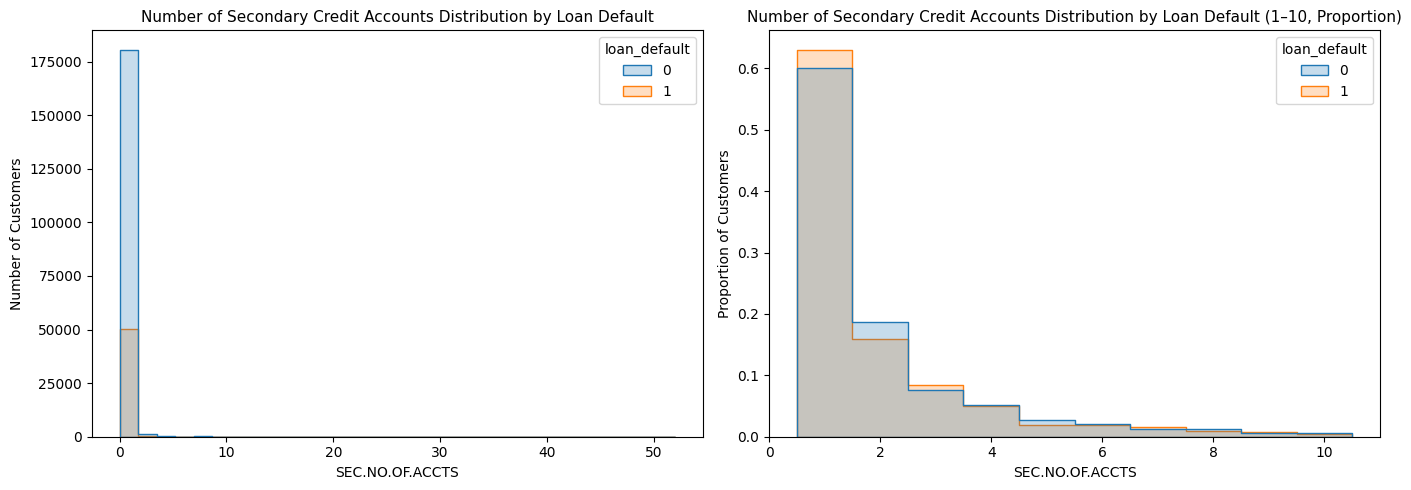

In [45]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(data=df_loan_default, x="SEC.NO.OF.ACCTS", hue="loan_default", bins=30, element="step", ax=axes[0])
axes[0].set_title("Number of Secondary Credit Accounts Distribution by Loan Default", fontsize=11)
axes[0].set_ylabel("Number of Customers")

sns.histplot(
    data=df_loan_default[df_loan_default["SEC.NO.OF.ACCTS"].between(1, 10)], 
    x="SEC.NO.OF.ACCTS", 
    hue="loan_default", 
    discrete=True,
    stat="probability",
    common_norm=False,
    element="step", 
    ax=axes[1]
)
axes[1].set_title("Number of Secondary Credit Accounts Distribution by Loan Default (1–10, Proportion)", fontsize=11)
axes[1].set_ylabel("Proportion of Customers")

plt.tight_layout()
plt.show()

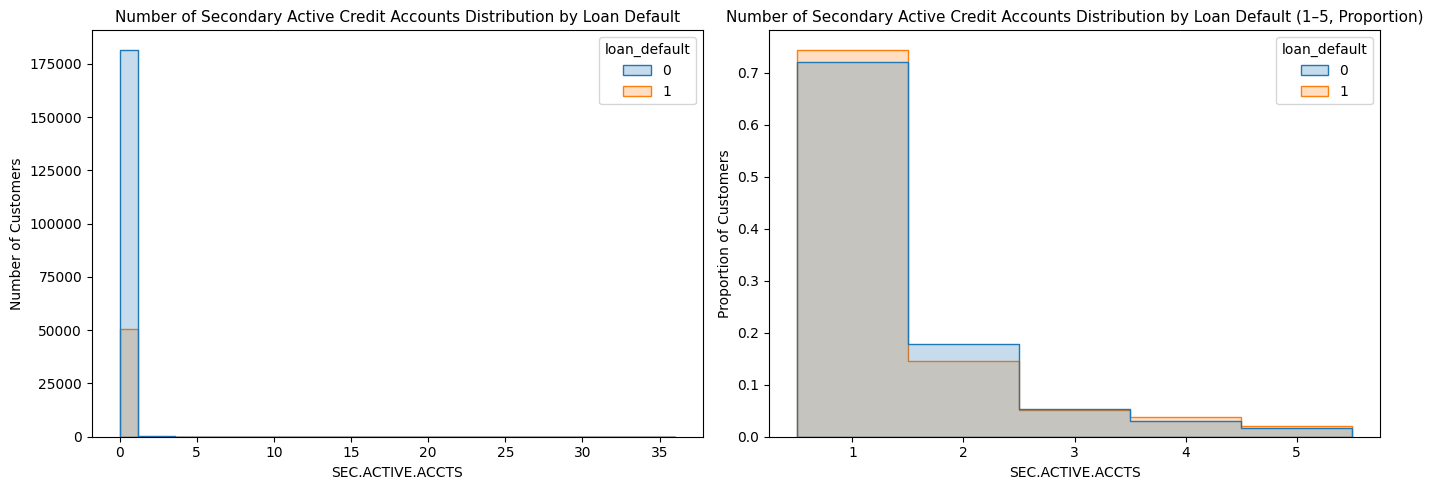

In [46]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(data=df_loan_default, x="SEC.ACTIVE.ACCTS", hue="loan_default", bins=30, element="step", ax=axes[0])
axes[0].set_title("Number of Secondary Active Credit Accounts Distribution by Loan Default", fontsize=11)
axes[0].set_ylabel("Number of Customers")

sns.histplot(
    data=df_loan_default[df_loan_default["SEC.ACTIVE.ACCTS"].between(1, 5)], 
    x="SEC.ACTIVE.ACCTS", 
    hue="loan_default", 
    discrete=True,
    stat="probability",
    common_norm=False,
    element="step", 
    ax=axes[1]
)
axes[1].set_title("Number of Secondary Active Credit Accounts Distribution by Loan Default (1–5, Proportion)", fontsize=11)
axes[1].set_ylabel("Proportion of Customers")

plt.tight_layout()
plt.show()

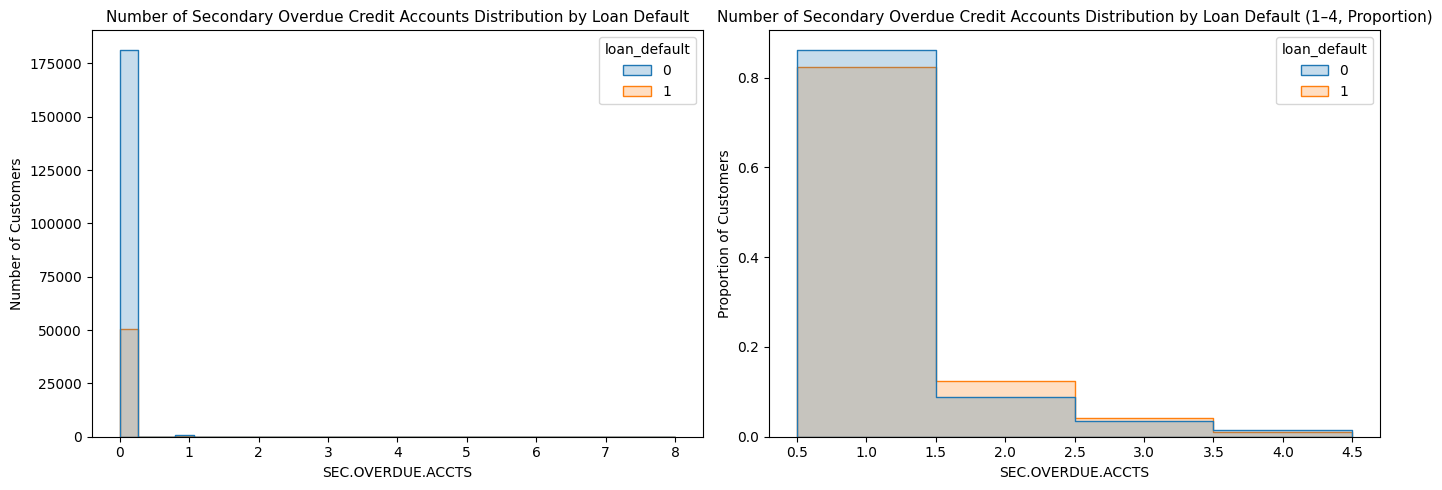

In [47]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(data=df_loan_default, x="SEC.OVERDUE.ACCTS", hue="loan_default", bins=30, element="step", ax=axes[0])
axes[0].set_title("Number of Secondary Overdue Credit Accounts Distribution by Loan Default", fontsize=11)
axes[0].set_ylabel("Number of Customers")

sns.histplot(
    data=df_loan_default[df_loan_default["SEC.OVERDUE.ACCTS"].between(1, 4)], 
    x="SEC.OVERDUE.ACCTS", 
    hue="loan_default", 
    discrete=True,
    stat="probability",
    common_norm=False,
    element="step", 
    ax=axes[1]
)
axes[1].set_title("Number of Secondary Overdue Credit Accounts Distribution by Loan Default (1–4, Proportion)", fontsize=11)
axes[1].set_ylabel("Proportion of Customers")

plt.tight_layout()
plt.show()

Checking for negative values:

In [48]:
(df_loan_default["SEC.CURRENT.BALANCE"] < 0).sum()

np.int64(61)

In [49]:
df_loan_default["SEC.CURRENT.BALANCE"].min()

np.int64(-574647)

Replacing negative values with 0:

In [50]:
df_loan_default.loc[df_loan_default["SEC.CURRENT.BALANCE"] < 0, "SEC.CURRENT.BALANCE"] = 0

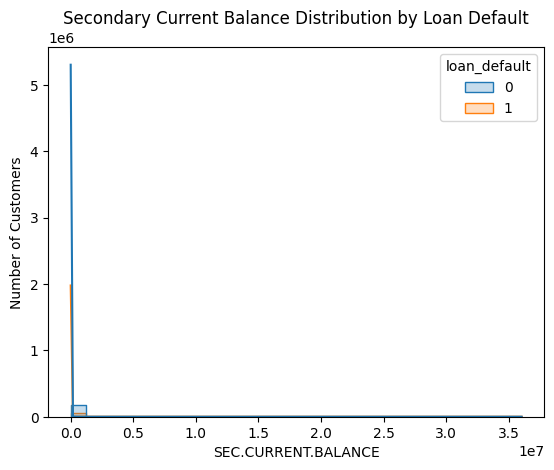

In [51]:
sns.histplot(data=df_loan_default, x="SEC.CURRENT.BALANCE", hue="loan_default", bins=30, kde=True, element="step")
plt.title("Secondary Current Balance Distribution by Loan Default")
plt.ylabel("Number of Customers")
plt.show()

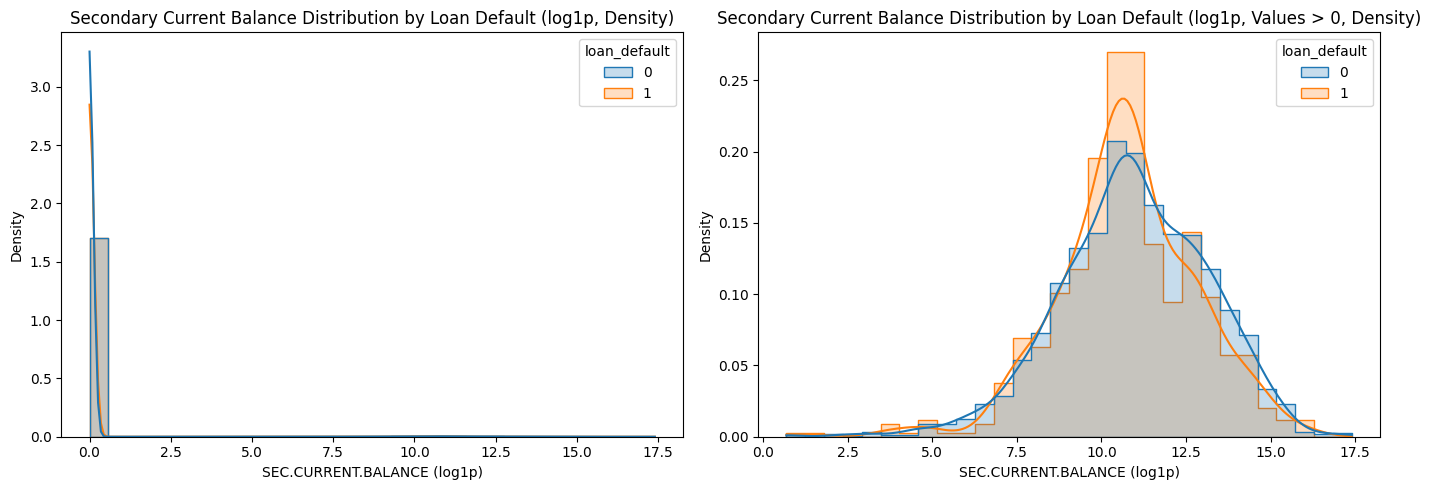

In [52]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(
    data=df_loan_default, 
    x=np.log1p(df_loan_default["SEC.CURRENT.BALANCE"]), 
    hue="loan_default", 
    bins=30, 
    kde=True, 
    stat="density", 
    common_norm=False, 
    element="step", 
    ax=axes[0]
)
axes[0].set_title("Secondary Current Balance Distribution by Loan Default (log1p, Density)")
axes[0].set_xlabel("SEC.CURRENT.BALANCE (log1p)")
axes[0].set_ylabel("Density")

nonzero = df_loan_default[df_loan_default["SEC.CURRENT.BALANCE"] > 0]

sns.histplot(
    data=nonzero, 
    x=np.log1p(nonzero["SEC.CURRENT.BALANCE"]), 
    hue="loan_default", 
    bins=30, 
    kde=True, 
    stat="density", 
    common_norm=False, 
    element="step", 
    ax=axes[1]
)
axes[1].set_title("Secondary Current Balance Distribution by Loan Default (log1p, Values > 0, Density)")
axes[1].set_xlabel("SEC.CURRENT.BALANCE (log1p)")
axes[1].set_ylabel("Density")

plt.tight_layout()
plt.show()

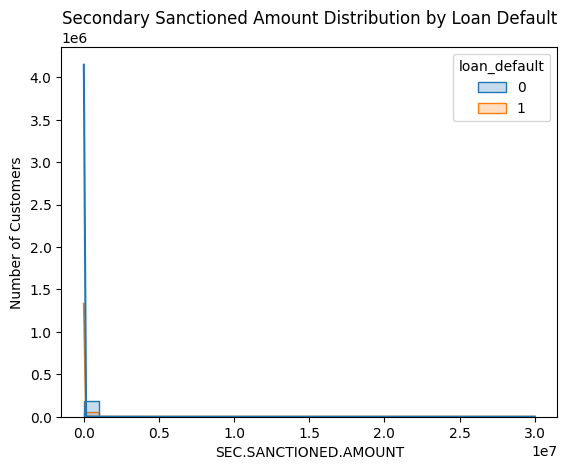

In [53]:
sns.histplot(data=df_loan_default, x="SEC.SANCTIONED.AMOUNT", hue="loan_default", bins=30, kde=True, element="step")
plt.title("Secondary Sanctioned Amount Distribution by Loan Default")
plt.ylabel("Number of Customers")
plt.show()

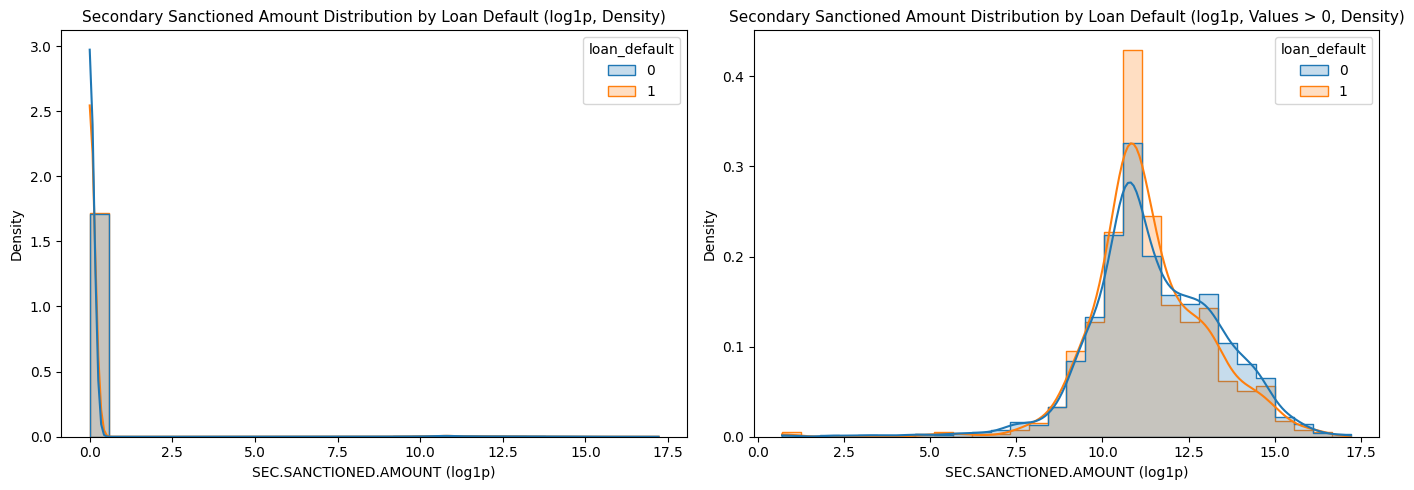

In [54]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(
    data=df_loan_default, 
    x=np.log1p(df_loan_default["SEC.SANCTIONED.AMOUNT"]), 
    hue="loan_default", 
    bins=30, 
    kde=True, 
    stat="density", 
    common_norm=False, 
    element="step", 
    ax=axes[0]
)
axes[0].set_title("Secondary Sanctioned Amount Distribution by Loan Default (log1p, Density)", fontsize=11)
axes[0].set_xlabel("SEC.SANCTIONED.AMOUNT (log1p)")
axes[0].set_ylabel("Density")

nonzero = df_loan_default[df_loan_default["SEC.SANCTIONED.AMOUNT"] > 0]

sns.histplot(
    data=nonzero, 
    x=np.log1p(nonzero["SEC.SANCTIONED.AMOUNT"]), 
    hue="loan_default", 
    bins=30, 
    kde=True, 
    stat="density", 
    common_norm=False, 
    element="step", 
    ax=axes[1]
)
axes[1].set_title("Secondary Sanctioned Amount Distribution by Loan Default (log1p, Values > 0, Density)", fontsize=11)
axes[1].set_xlabel("SEC.SANCTIONED.AMOUNT (log1p)")
axes[1].set_ylabel("Density")

plt.tight_layout()
plt.show()

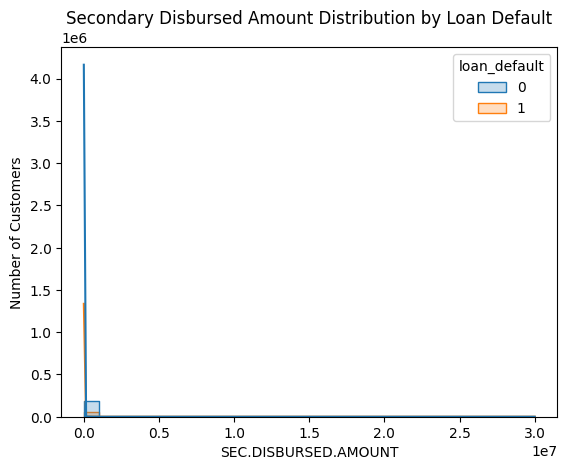

In [55]:
sns.histplot(data=df_loan_default, x="SEC.DISBURSED.AMOUNT", hue="loan_default", bins=30, kde=True, element="step")
plt.title("Secondary Disbursed Amount Distribution by Loan Default")
plt.ylabel("Number of Customers")
plt.show()

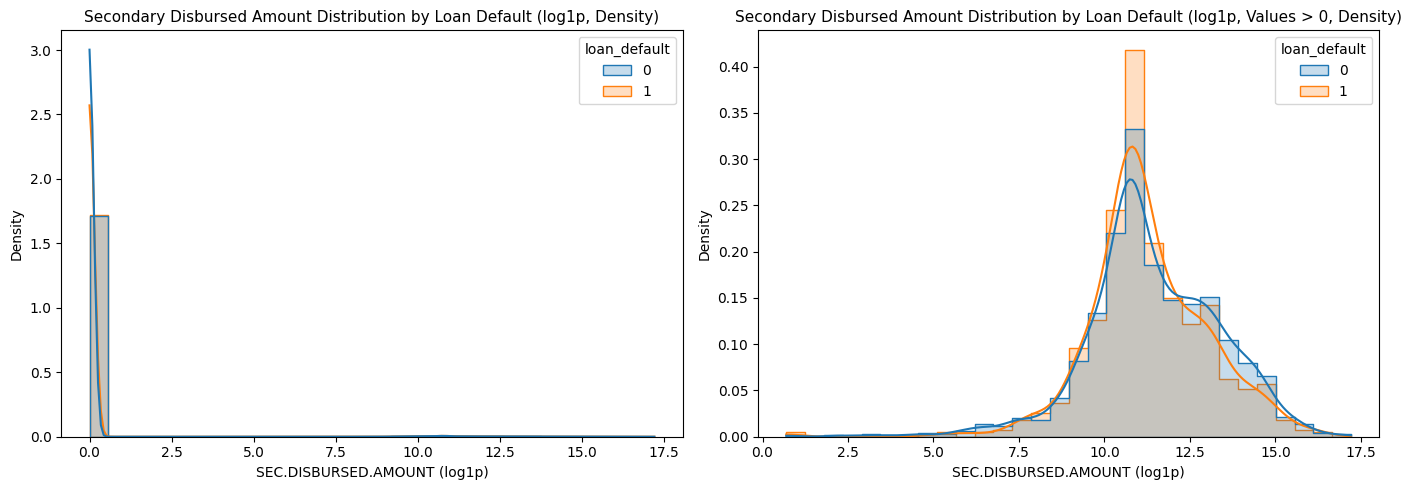

In [56]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(
    data=df_loan_default, 
    x=np.log1p(df_loan_default["SEC.DISBURSED.AMOUNT"]), 
    hue="loan_default", 
    bins=30, 
    kde=True, 
    stat="density", 
    common_norm=False, 
    element="step", 
    ax=axes[0]
)
axes[0].set_title("Secondary Disbursed Amount Distribution by Loan Default (log1p, Density)", fontsize=11)
axes[0].set_xlabel("SEC.DISBURSED.AMOUNT (log1p)")
axes[0].set_ylabel("Density")

nonzero = df_loan_default[df_loan_default["SEC.DISBURSED.AMOUNT"] > 0]

sns.histplot(
    data=nonzero, 
    x=np.log1p(nonzero["SEC.DISBURSED.AMOUNT"]), 
    hue="loan_default", 
    bins=30, 
    kde=True, 
    stat="density", 
    common_norm=False, 
    element="step", 
    ax=axes[1]
)
axes[1].set_title("Secondary Disbursed Amount Distribution by Loan Default (log1p, Values > 0, Density)", fontsize=11)
axes[1].set_xlabel("SEC.DISBURSED.AMOUNT (log1p)")
axes[1].set_ylabel("Density")

plt.tight_layout()
plt.show()

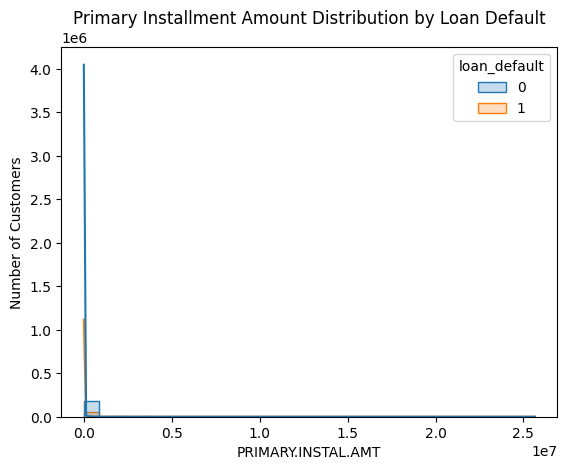

In [57]:
sns.histplot(data=df_loan_default, x="PRIMARY.INSTAL.AMT", hue="loan_default", bins=30, kde=True, element="step")
plt.title("Primary Installment Amount Distribution by Loan Default")
plt.ylabel("Number of Customers")
plt.show()

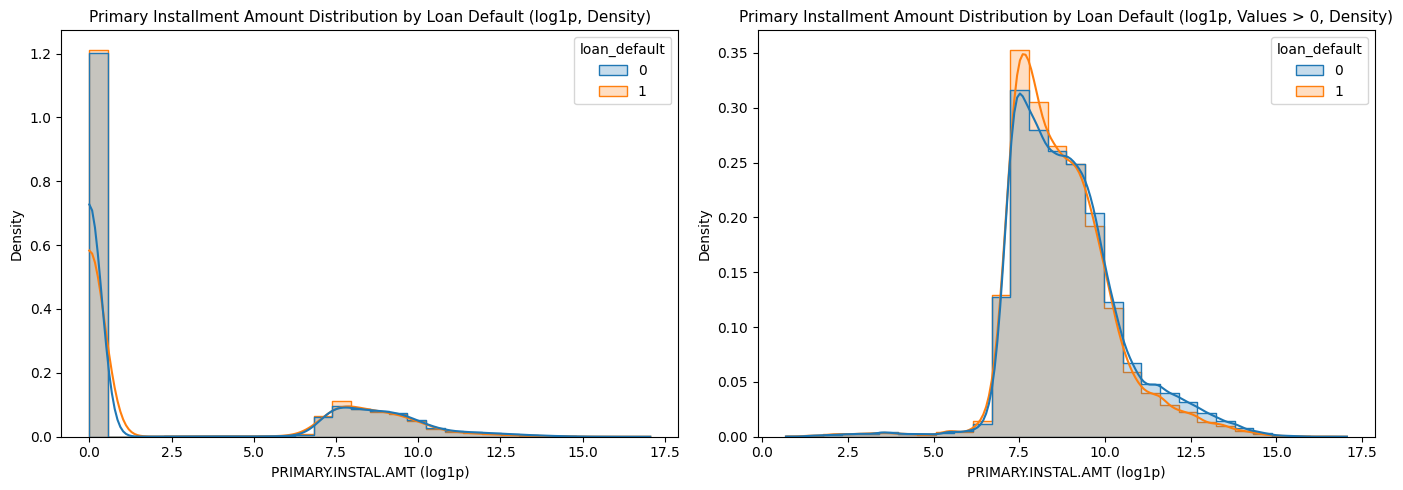

In [58]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(
    data=df_loan_default, 
    x=np.log1p(df_loan_default["PRIMARY.INSTAL.AMT"]), 
    hue="loan_default", 
    bins=30, 
    kde=True, 
    stat="density", 
    common_norm=False, 
    element="step", 
    ax=axes[0]
)
axes[0].set_title("Primary Installment Amount Distribution by Loan Default (log1p, Density)", fontsize=11)
axes[0].set_xlabel("PRIMARY.INSTAL.AMT (log1p)")
axes[0].set_ylabel("Density")

nonzero = df_loan_default[df_loan_default["PRIMARY.INSTAL.AMT"] > 0]

sns.histplot(
    data=nonzero, 
    x=np.log1p(nonzero["PRIMARY.INSTAL.AMT"]), 
    hue="loan_default", 
    bins=30, 
    kde=True, 
    stat="density", 
    common_norm=False, 
    element="step", 
    ax=axes[1]
)
axes[1].set_title("Primary Installment Amount Distribution by Loan Default (log1p, Values > 0, Density)", fontsize=11)
axes[1].set_xlabel("PRIMARY.INSTAL.AMT (log1p)")
axes[1].set_ylabel("Density")

plt.tight_layout()
plt.show()

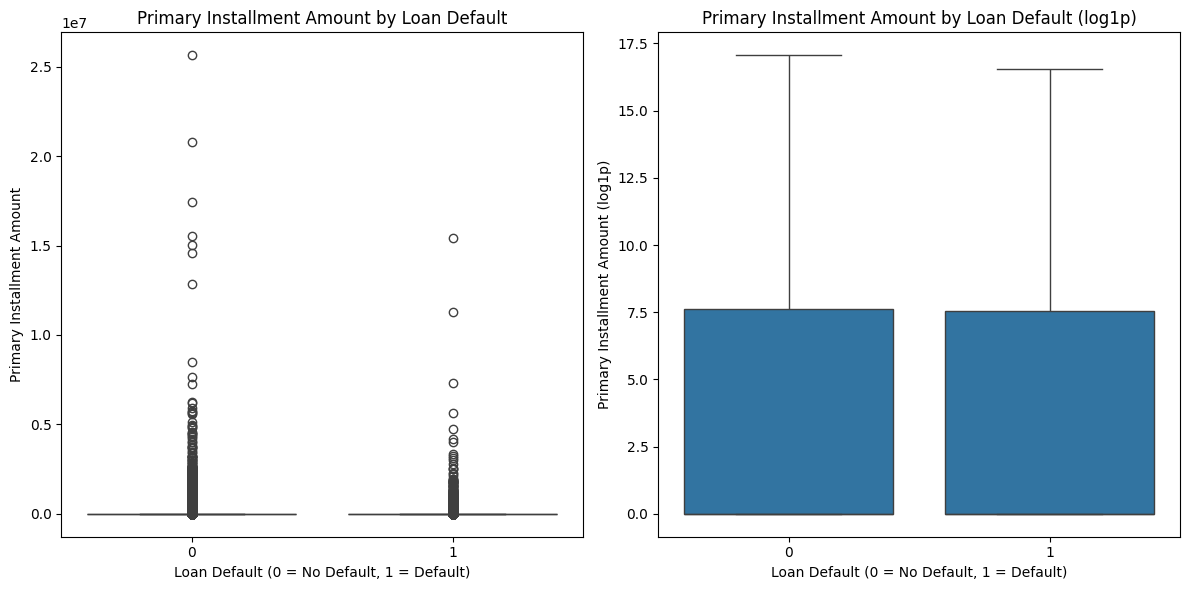

In [59]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

sns.boxplot(data=df_loan_default, x="loan_default", y="PRIMARY.INSTAL.AMT", ax=axes[0])
axes[0].set_title("Primary Installment Amount by Loan Default")
axes[0].set_xlabel("Loan Default (0 = No Default, 1 = Default)")
axes[0].set_ylabel("Primary Installment Amount")

sns.boxplot(data=df_loan_default, x="loan_default", y=np.log1p(df_loan_default["PRIMARY.INSTAL.AMT"]), ax=axes[1])
axes[1].set_title("Primary Installment Amount by Loan Default (log1p)")
axes[1].set_xlabel("Loan Default (0 = No Default, 1 = Default)")
axes[1].set_ylabel("Primary Installment Amount (log1p)")

plt.tight_layout()
plt.show()

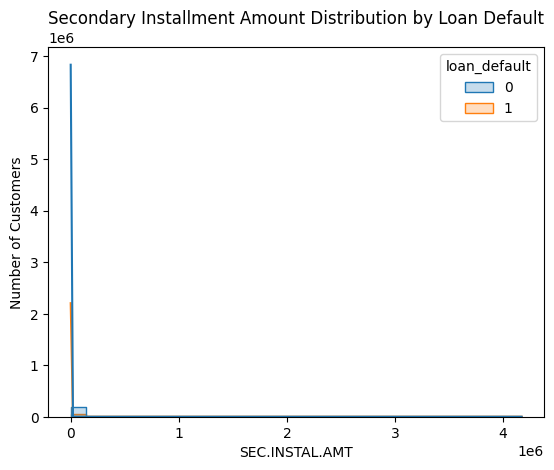

In [60]:
sns.histplot(data=df_loan_default, x="SEC.INSTAL.AMT", hue="loan_default", bins=30, kde=True, element="step")
plt.title("Secondary Installment Amount Distribution by Loan Default")
plt.ylabel("Number of Customers")
plt.show()

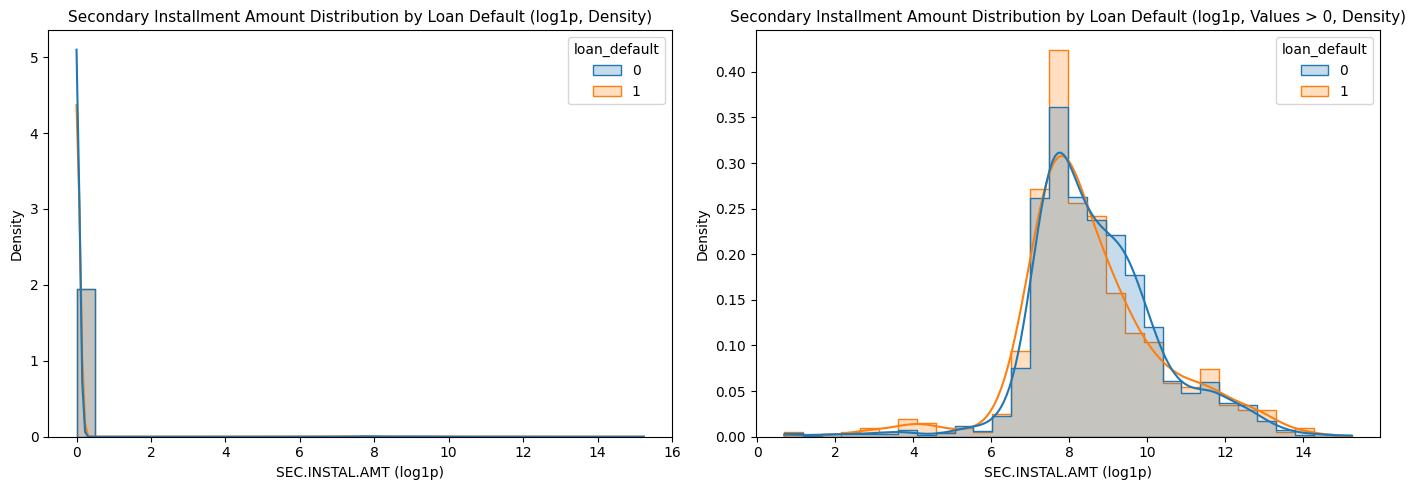

In [61]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(
    data=df_loan_default, 
    x=np.log1p(df_loan_default["SEC.INSTAL.AMT"]), 
    hue="loan_default", 
    bins=30, 
    kde=True, 
    stat="density", 
    common_norm=False, 
    element="step", 
    ax=axes[0]
)
axes[0].set_title("Secondary Installment Amount Distribution by Loan Default (log1p, Density)", fontsize=11)
axes[0].set_xlabel("SEC.INSTAL.AMT (log1p)")
axes[0].set_ylabel("Density")

nonzero = df_loan_default[df_loan_default["SEC.INSTAL.AMT"] > 0]

sns.histplot(
    data=nonzero, 
    x=np.log1p(nonzero["SEC.INSTAL.AMT"]), 
    hue="loan_default", 
    bins=30, 
    kde=True, 
    stat="density", 
    common_norm=False, 
    element="step", 
    ax=axes[1]
)
axes[1].set_title("Secondary Installment Amount Distribution by Loan Default (log1p, Values > 0, Density)", fontsize=11)
axes[1].set_xlabel("SEC.INSTAL.AMT (log1p)")
axes[1].set_ylabel("Density")

plt.tight_layout()
plt.show()

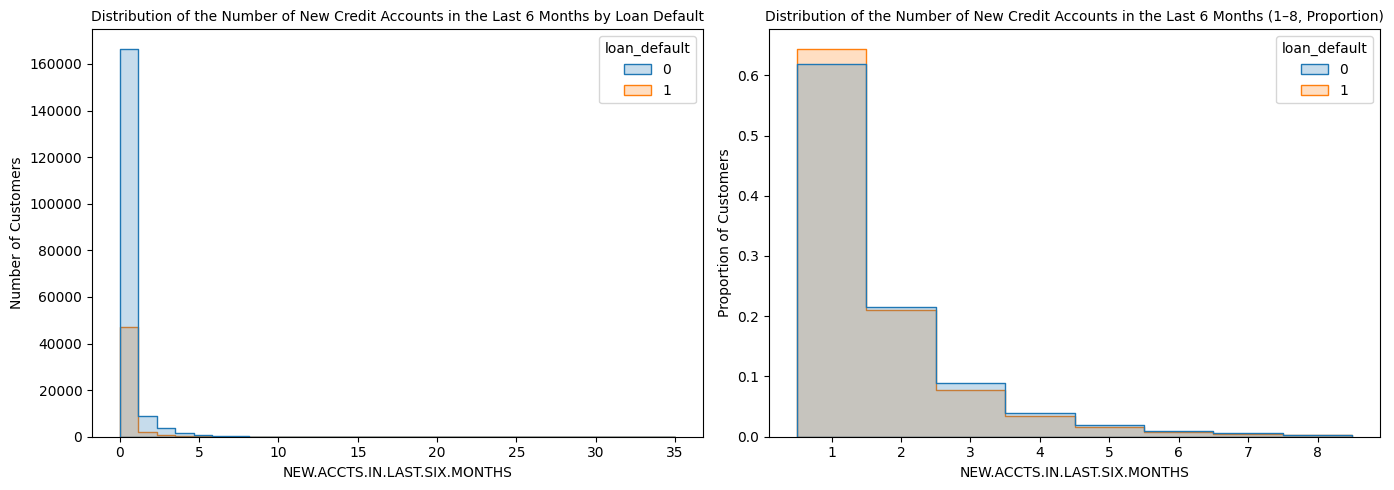

In [62]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(data=df_loan_default, x="NEW.ACCTS.IN.LAST.SIX.MONTHS", hue="loan_default", bins=30, element="step", ax=axes[0])
axes[0].set_title("Distribution of the Number of New Credit Accounts in the Last 6 Months by Loan Default", fontsize=10)
axes[0].set_ylabel("Number of Customers")

sns.histplot(
    data=df_loan_default[df_loan_default["NEW.ACCTS.IN.LAST.SIX.MONTHS"].between(1, 8)], 
    x="NEW.ACCTS.IN.LAST.SIX.MONTHS", 
    hue="loan_default", 
    discrete=True,
    stat="probability",
    common_norm=False,
    element="step", 
    ax=axes[1]
)
axes[1].set_title("Distribution of the Number of New Credit Accounts in the Last 6 Months (1–8, Proportion)", fontsize=10)
axes[1].set_ylabel("Proportion of Customers")

plt.tight_layout()
plt.show()

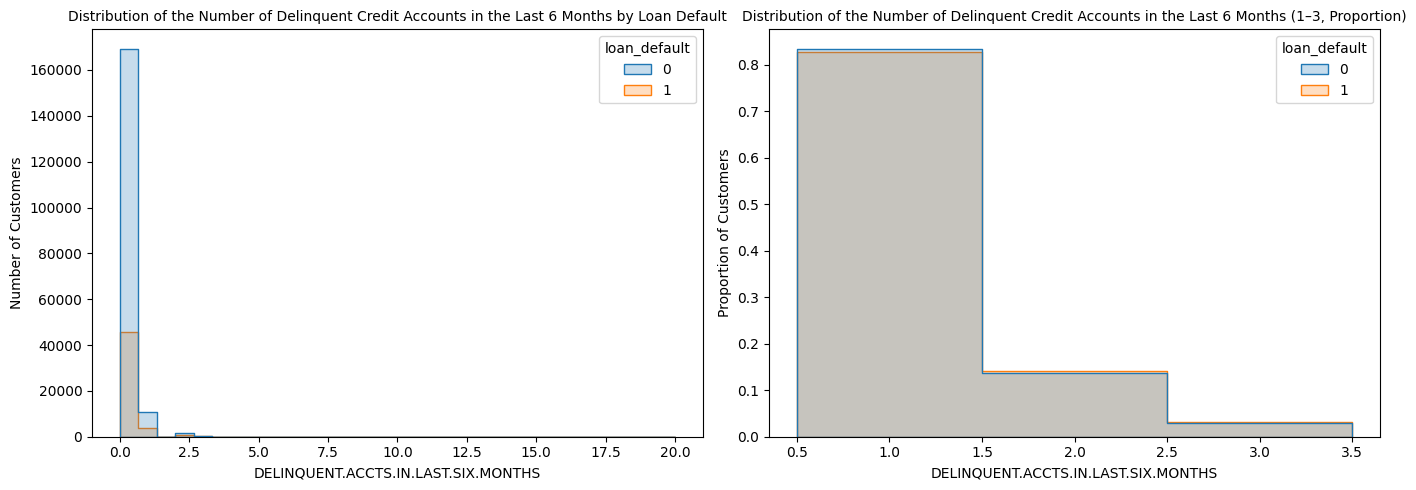

In [63]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(data=df_loan_default, x="DELINQUENT.ACCTS.IN.LAST.SIX.MONTHS", hue="loan_default", bins=30, element="step", ax=axes[0])
axes[0].set_title("Distribution of the Number of Delinquent Credit Accounts in the Last 6 Months by Loan Default", fontsize=10)
axes[0].set_ylabel("Number of Customers")

sns.histplot(
    data=df_loan_default[df_loan_default["DELINQUENT.ACCTS.IN.LAST.SIX.MONTHS"].between(1, 3)], 
    x="DELINQUENT.ACCTS.IN.LAST.SIX.MONTHS", 
    hue="loan_default", 
    discrete=True,
    stat="probability",
    common_norm=False,
    element="step", 
    ax=axes[1]
)
axes[1].set_title("Distribution of the Number of Delinquent Credit Accounts in the Last 6 Months (1–3, Proportion)", fontsize=10)
axes[1].set_ylabel("Proportion of Customers")

plt.tight_layout()
plt.show()

Converting the `AVERAGE.ACCT.AGE` feature to months:

In [64]:
def age_to_months(s):
    years = int(s.split("yrs")[0].strip())
    months = int(s.split("yrs")[1].split("mon")[0].strip())
    return years * 12 + months

df_loan_default["avg_account_age_months"] = df_loan_default["AVERAGE.ACCT.AGE"].apply(age_to_months)

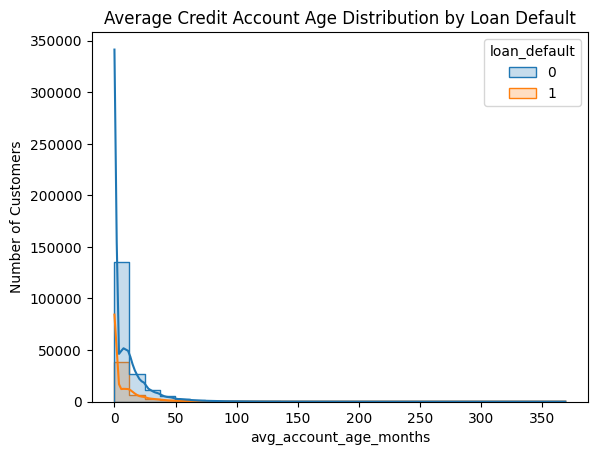

In [65]:
sns.histplot(data=df_loan_default, x="avg_account_age_months", hue="loan_default", bins=30, kde=True, element="step")
plt.title("Average Credit Account Age Distribution by Loan Default")
plt.ylabel("Number of Customers")
plt.show()

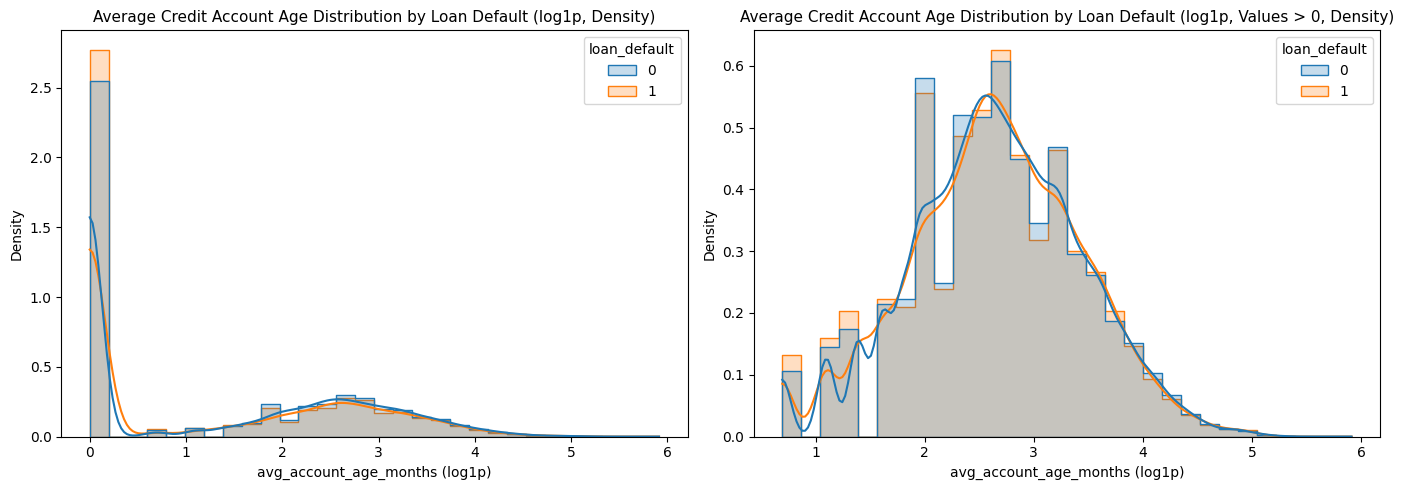

In [66]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(
    data=df_loan_default, 
    x=np.log1p(df_loan_default["avg_account_age_months"]), 
    hue="loan_default", 
    bins=30, 
    kde=True, 
    stat="density", 
    common_norm=False, 
    element="step", 
    ax=axes[0]
)
axes[0].set_title("Average Credit Account Age Distribution by Loan Default (log1p, Density)", fontsize=11)
axes[0].set_xlabel("avg_account_age_months (log1p)")
axes[0].set_ylabel("Density")

nonzero = df_loan_default[df_loan_default["avg_account_age_months"] > 0]

sns.histplot(
    data=nonzero, 
    x=np.log1p(nonzero["avg_account_age_months"]), 
    hue="loan_default", 
    bins=30, 
    kde=True, 
    stat="density", 
    common_norm=False, 
    element="step", 
    ax=axes[1]
)
axes[1].set_title("Average Credit Account Age Distribution by Loan Default (log1p, Values > 0, Density)", fontsize=11)
axes[1].set_xlabel("avg_account_age_months (log1p)")
axes[1].set_ylabel("Density")

plt.tight_layout()
plt.show()

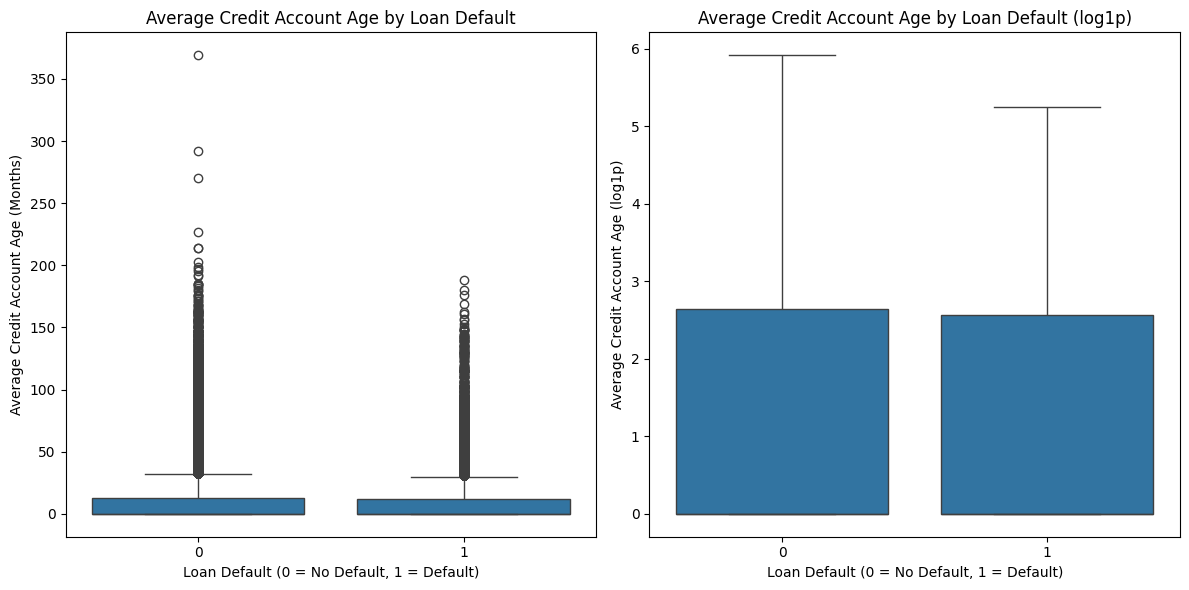

In [67]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

sns.boxplot(data=df_loan_default, x="loan_default", y="avg_account_age_months", ax=axes[0])
axes[0].set_title("Average Credit Account Age by Loan Default")
axes[0].set_xlabel("Loan Default (0 = No Default, 1 = Default)")
axes[0].set_ylabel("Average Credit Account Age (Months)")

sns.boxplot(data=df_loan_default, x="loan_default", y=np.log1p(df_loan_default["avg_account_age_months"]), ax=axes[1])
axes[1].set_title("Average Credit Account Age by Loan Default (log1p)")
axes[1].set_xlabel("Loan Default (0 = No Default, 1 = Default)")
axes[1].set_ylabel("Average Credit Account Age (log1p)")

plt.tight_layout()
plt.show()

Converting the `CREDIT.HISTORY.LENGTH` feature to months:

In [68]:
def credit_length_to_months(s):
    years = int(s.split("yrs")[0].strip())
    months = int(s.split("yrs")[1].split("mon")[0].strip())
    return years * 12 + months

df_loan_default["credit_history_length_months"] = df_loan_default["CREDIT.HISTORY.LENGTH"].apply(credit_length_to_months)

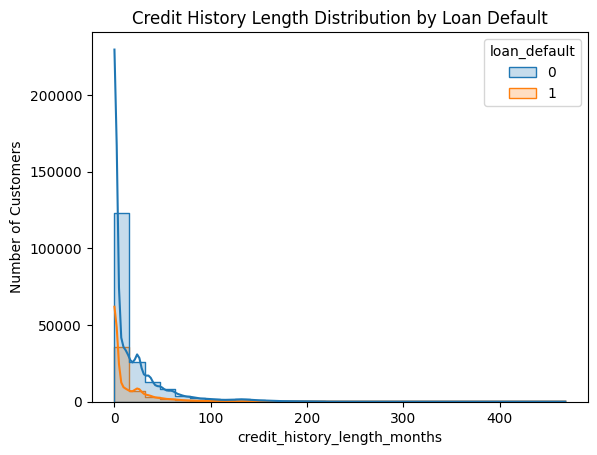

In [69]:
sns.histplot(data=df_loan_default, x="credit_history_length_months", hue="loan_default", bins=30, kde=True, element="step")
plt.title("Credit History Length Distribution by Loan Default")
plt.ylabel("Number of Customers")
plt.show()

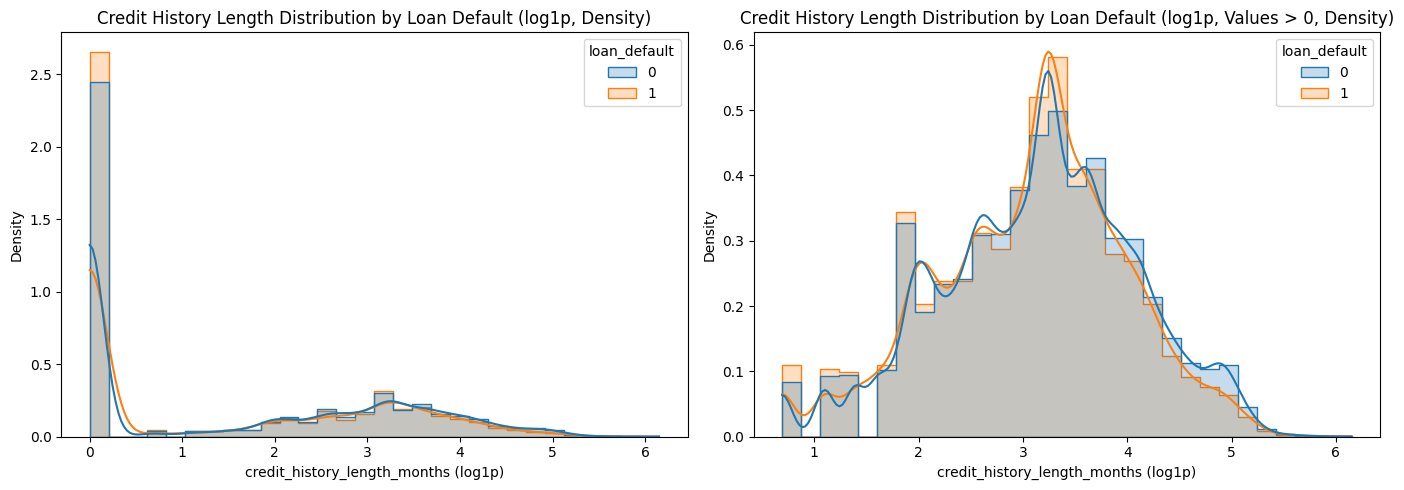

In [70]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(
    data=df_loan_default, 
    x=np.log1p(df_loan_default["credit_history_length_months"]), 
    hue="loan_default", 
    bins=30, 
    kde=True, 
    stat="density", 
    common_norm=False, 
    element="step", 
    ax=axes[0]
)
axes[0].set_title("Credit History Length Distribution by Loan Default (log1p, Density)")
axes[0].set_xlabel("credit_history_length_months (log1p)")
axes[0].set_ylabel("Density")

nonzero = df_loan_default[df_loan_default["credit_history_length_months"] > 0]

sns.histplot(
    data=nonzero, 
    x=np.log1p(nonzero["credit_history_length_months"]), 
    hue="loan_default", 
    bins=30, 
    kde=True, 
    stat="density", 
    common_norm=False, 
    element="step", 
    ax=axes[1]
)
axes[1].set_title("Credit History Length Distribution by Loan Default (log1p, Values > 0, Density)")
axes[1].set_xlabel("credit_history_length_months (log1p)")
axes[1].set_ylabel("Density")

plt.tight_layout()
plt.show()

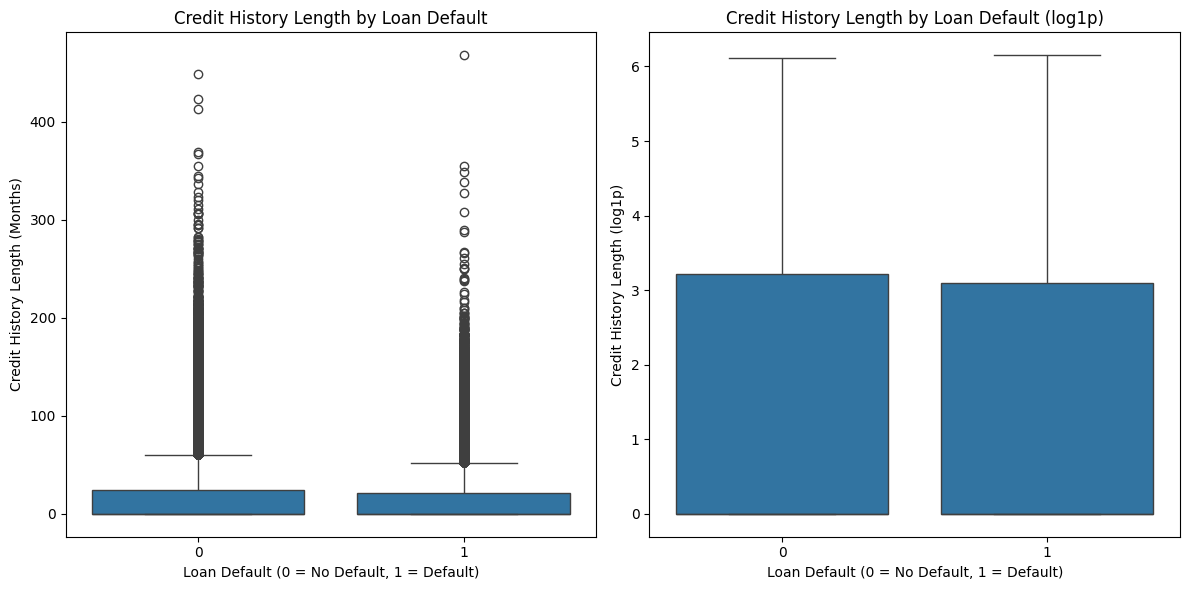

In [71]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

sns.boxplot(data=df_loan_default, x="loan_default", y="credit_history_length_months", ax=axes[0])
axes[0].set_title("Credit History Length by Loan Default")
axes[0].set_xlabel("Loan Default (0 = No Default, 1 = Default)")
axes[0].set_ylabel("Credit History Length (Months)")

sns.boxplot(data=df_loan_default, x="loan_default", y=np.log1p(df_loan_default["credit_history_length_months"]), ax=axes[1])
axes[1].set_title("Credit History Length by Loan Default (log1p)")
axes[1].set_xlabel("Loan Default (0 = No Default, 1 = Default)")
axes[1].set_ylabel("Credit History Length (log1p)")

plt.tight_layout()
plt.show()

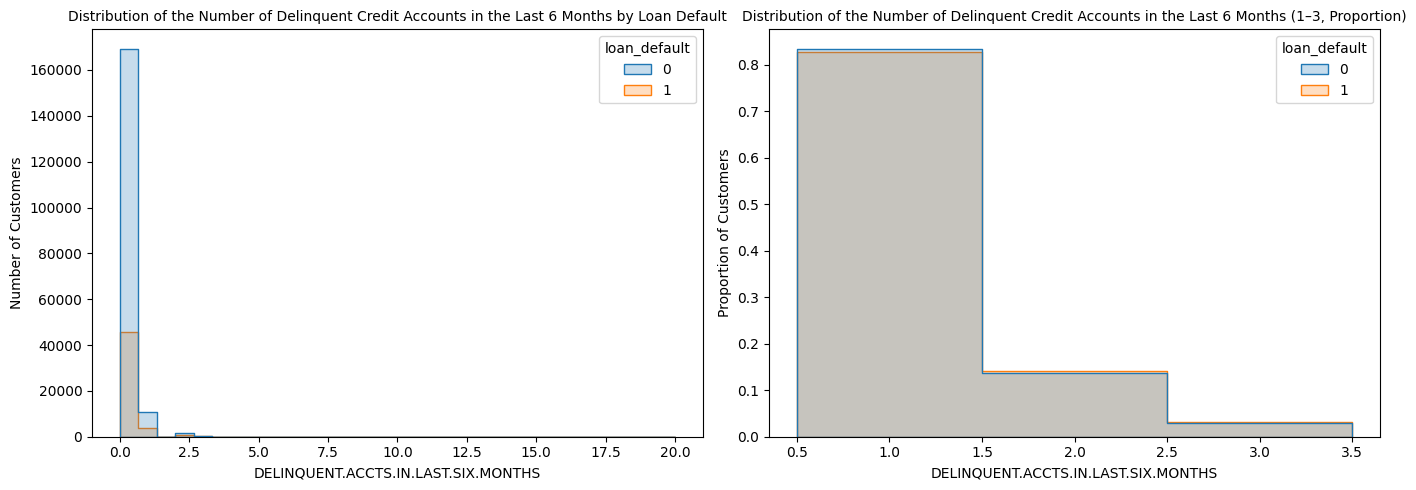

In [72]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(data=df_loan_default, x="DELINQUENT.ACCTS.IN.LAST.SIX.MONTHS", hue="loan_default", bins=30, element="step", ax=axes[0])
axes[0].set_title("Distribution of the Number of Delinquent Credit Accounts in the Last 6 Months by Loan Default", fontsize=10)
axes[0].set_ylabel("Number of Customers")

sns.histplot(
    data=df_loan_default[df_loan_default["DELINQUENT.ACCTS.IN.LAST.SIX.MONTHS"].between(1, 3)], 
    x="DELINQUENT.ACCTS.IN.LAST.SIX.MONTHS", 
    hue="loan_default", 
    discrete=True,
    stat="probability",
    common_norm=False,
    element="step", 
    ax=axes[1]
)
axes[1].set_title("Distribution of the Number of Delinquent Credit Accounts in the Last 6 Months (1–3, Proportion)", fontsize=10)
axes[1].set_ylabel("Proportion of Customers")

plt.tight_layout()
plt.show()

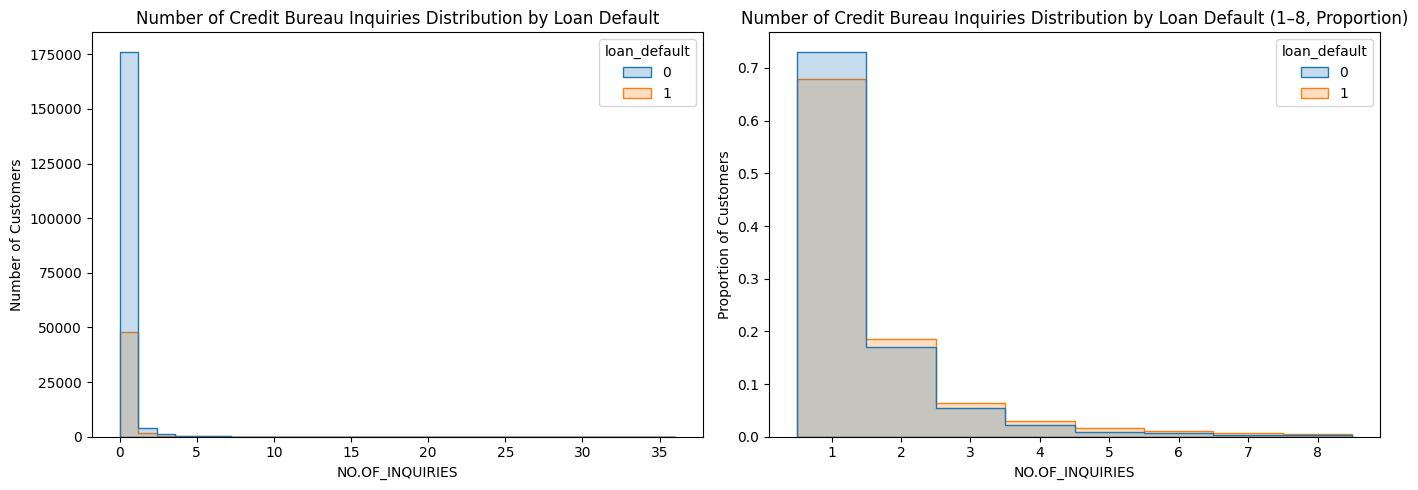

In [73]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(data=df_loan_default, x="NO.OF_INQUIRIES", hue="loan_default", bins=30, element="step", ax=axes[0])
axes[0].set_title("Number of Credit Bureau Inquiries Distribution by Loan Default")
axes[0].set_ylabel("Number of Customers")

sns.histplot(
    data=df_loan_default[df_loan_default["NO.OF_INQUIRIES"].between(1, 8)], 
    x="NO.OF_INQUIRIES", 
    hue="loan_default", 
    discrete=True,
    stat="probability",
    common_norm=False,
    element="step", 
    ax=axes[1]
)
axes[1].set_title("Number of Credit Bureau Inquiries Distribution by Loan Default (1–8, Proportion)")
axes[1].set_ylabel("Proportion of Customers")

plt.tight_layout()
plt.show()

Building the correlation matrix:

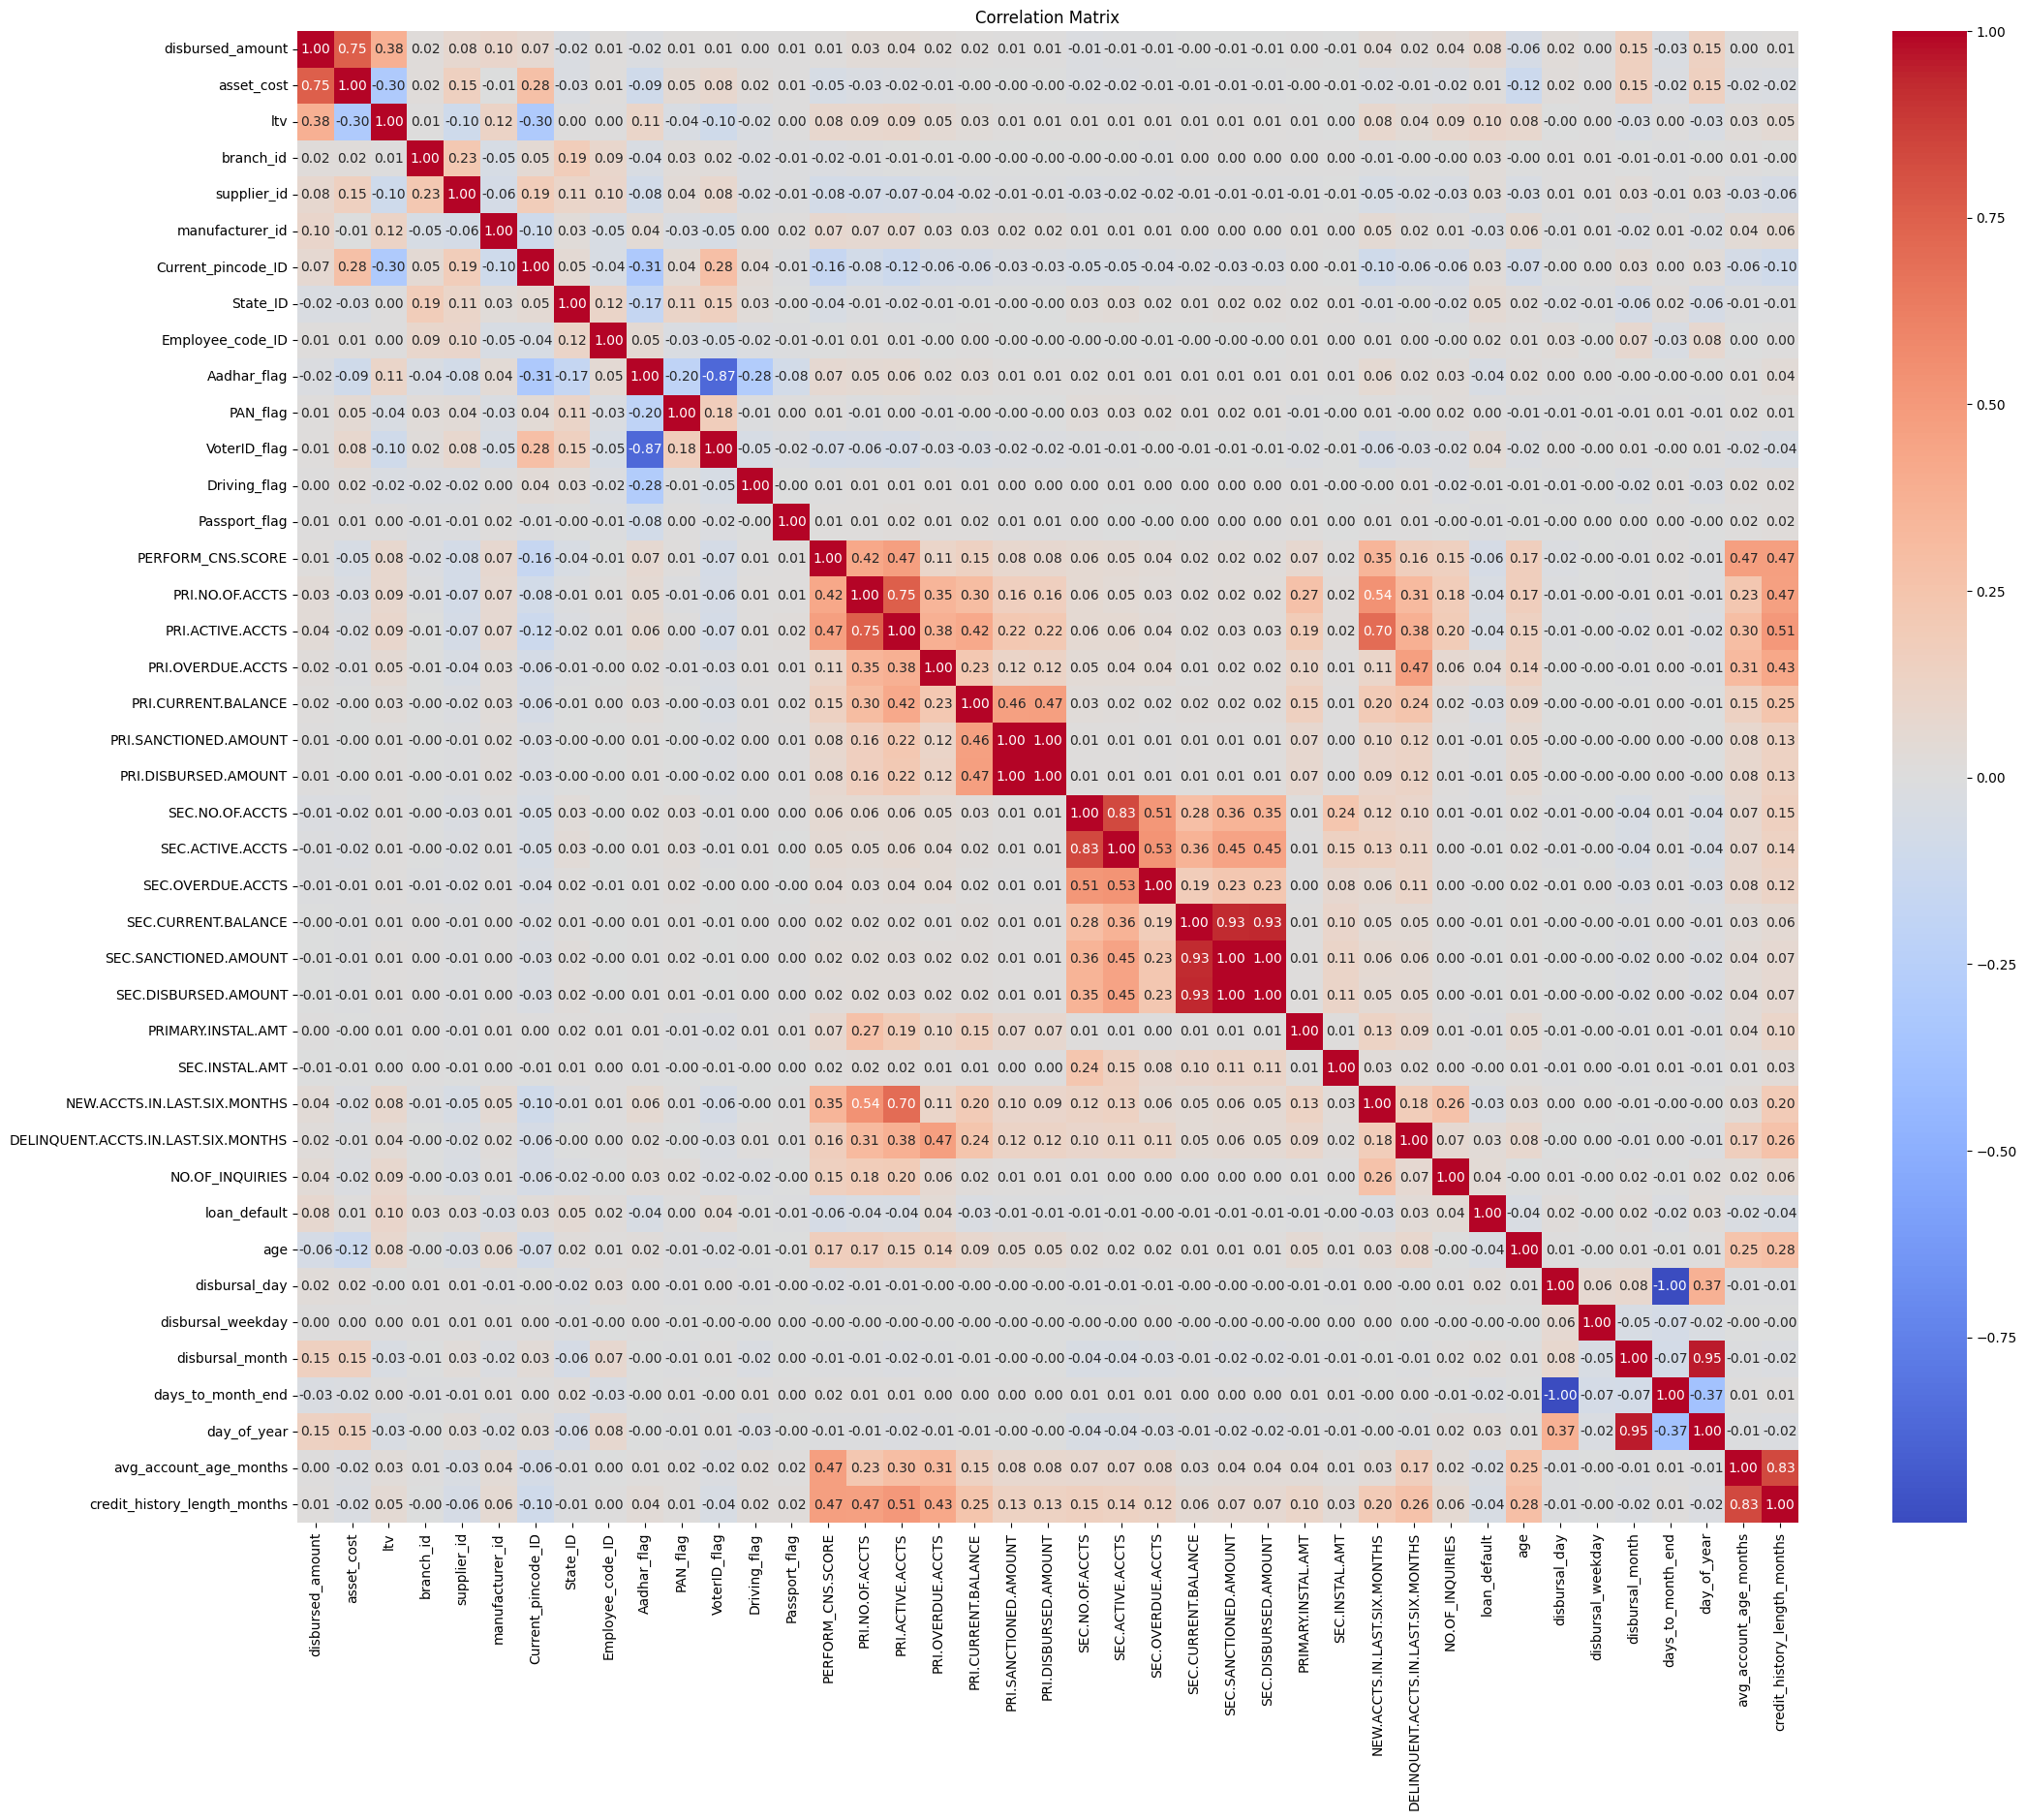

In [74]:
plt.figure(figsize=(25, 20))
sns.heatmap(df_loan_default.corr(numeric_only=True), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

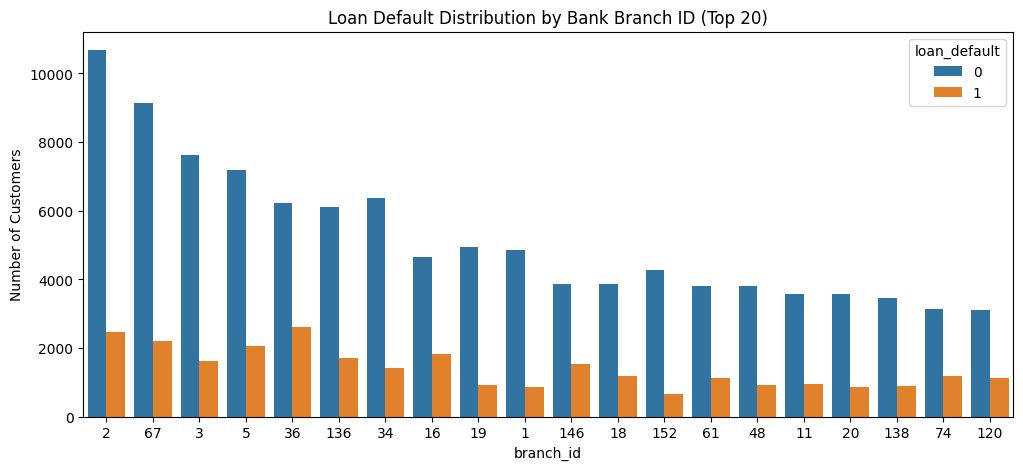

In [75]:
plt.figure(figsize=(12, 5))
top20_branch_id = df_loan_default["branch_id"].value_counts().head(20).index
sns.countplot(data=df_loan_default[df_loan_default["branch_id"].isin(top20_branch_id)], x="branch_id", hue="loan_default", order=top20_branch_id)
plt.title("Loan Default Distribution by Bank Branch ID (Top 20)")
plt.ylabel("Number of Customers")
plt.show()

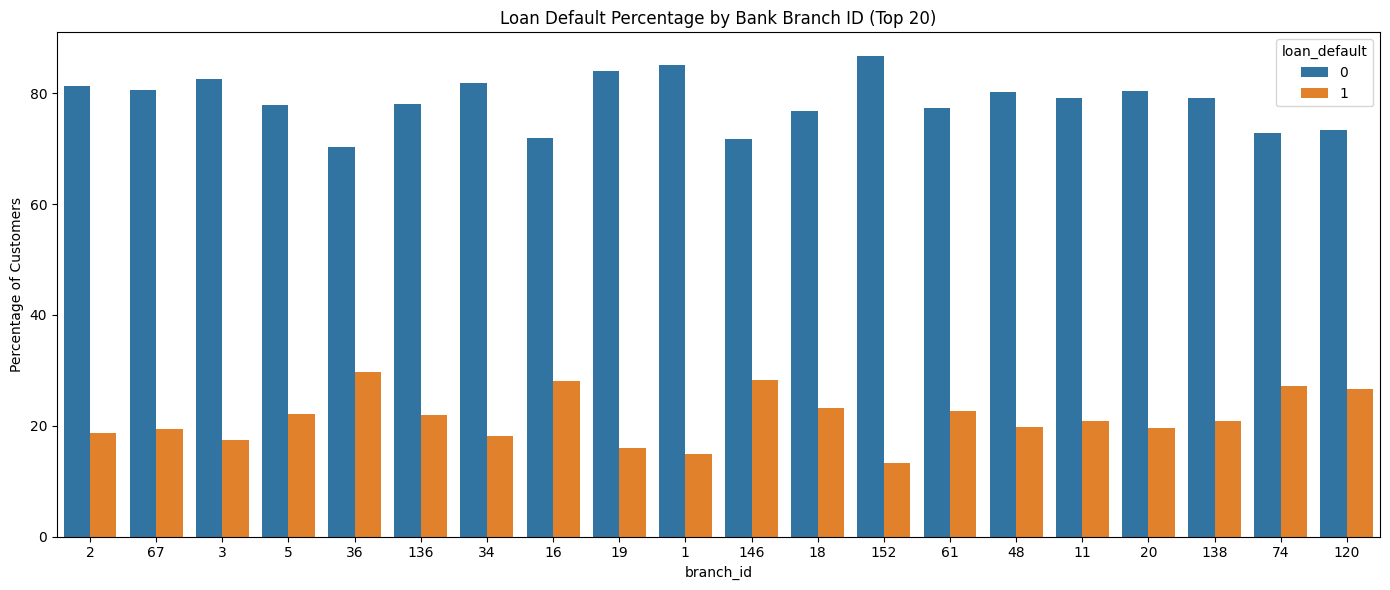

In [76]:
top20_ids = (
    df_loan_default["branch_id"]
    .value_counts()
    .head(20)
    .index
)

df_top20 = df_loan_default[df_loan_default["branch_id"].isin(top20_ids)]

df_percent = (
    df_top20.groupby("branch_id")["loan_default"]
    .value_counts(normalize=True)
    .mul(100)
    .rename("percent")
    .reset_index()
)

plt.figure(figsize=(14, 6))
sns.barplot(data=df_percent, x="branch_id", y="percent", hue="loan_default", order=top20_ids)
plt.title("Loan Default Percentage by Bank Branch ID (Top 20)")
plt.ylabel("Percentage of Customers")
plt.tight_layout()
plt.show()

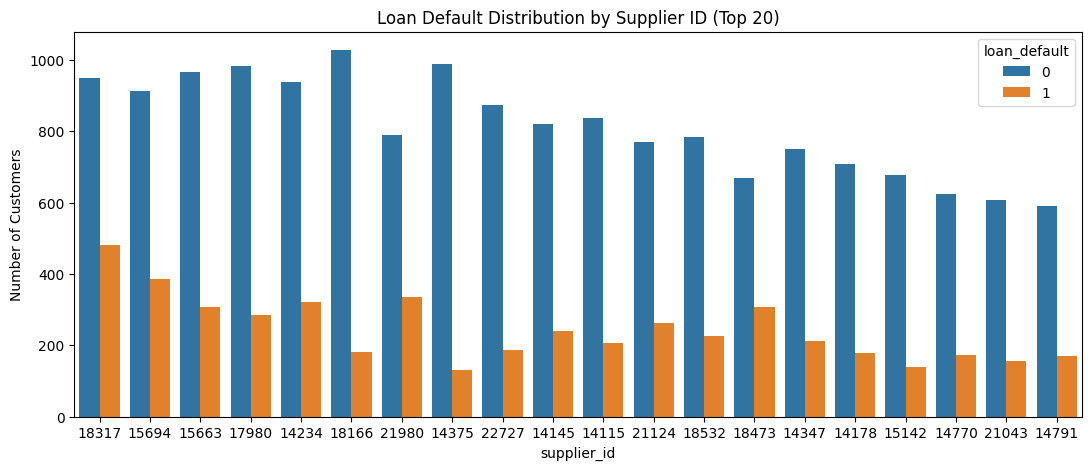

In [77]:
plt.figure(figsize=(13, 5))
top20_supplier_id = df_loan_default["supplier_id"].value_counts().head(20).index
sns.countplot(
    data=df_loan_default[df_loan_default["supplier_id"].isin(top20_supplier_id)], 
    x="supplier_id", 
    hue="loan_default", 
    order=top20_supplier_id
)
plt.title("Loan Default Distribution by Supplier ID (Top 20)")
plt.ylabel("Number of Customers")
plt.show()

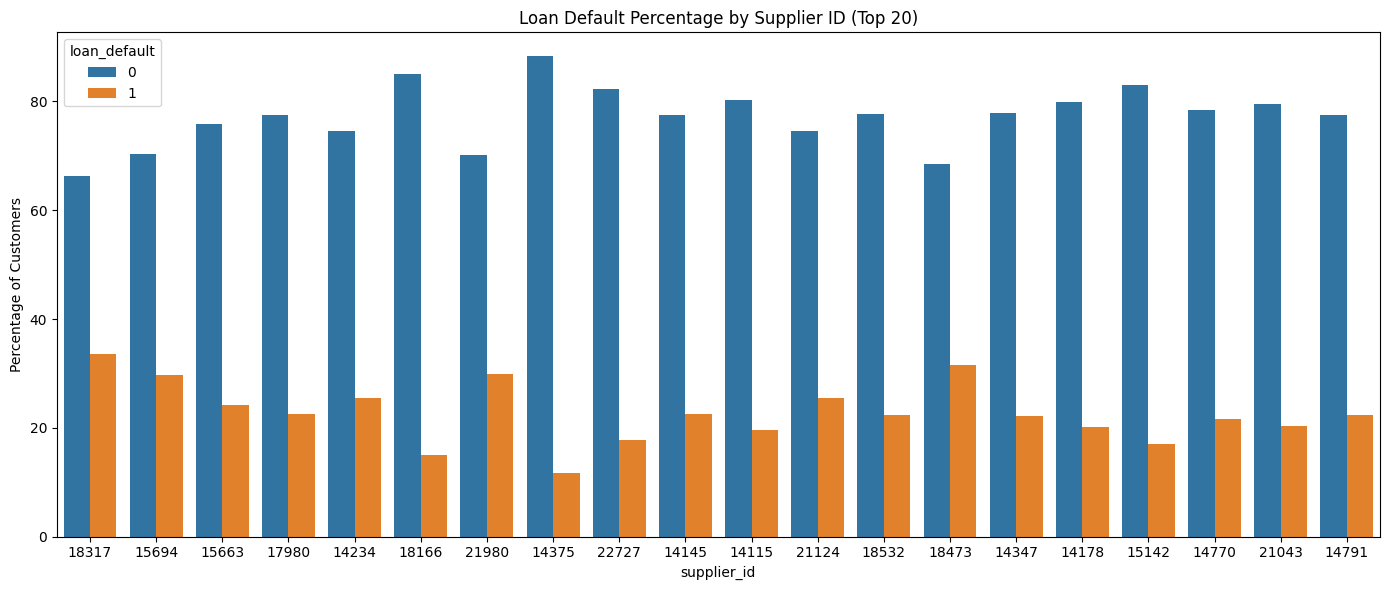

In [78]:
top20_ids = (
    df_loan_default["supplier_id"]
    .value_counts()
    .head(20)
    .index
)

df_top20 = df_loan_default[df_loan_default["supplier_id"].isin(top20_ids)]

df_percent = (
    df_top20.groupby("supplier_id")["loan_default"]
    .value_counts(normalize=True)
    .mul(100)
    .rename("percent")
    .reset_index()
)

plt.figure(figsize=(14, 6))
sns.barplot(data=df_percent, x="supplier_id", y="percent", hue="loan_default", order=top20_ids)
plt.title("Loan Default Percentage by Supplier ID (Top 20)")
plt.ylabel("Percentage of Customers")
plt.tight_layout()
plt.show()

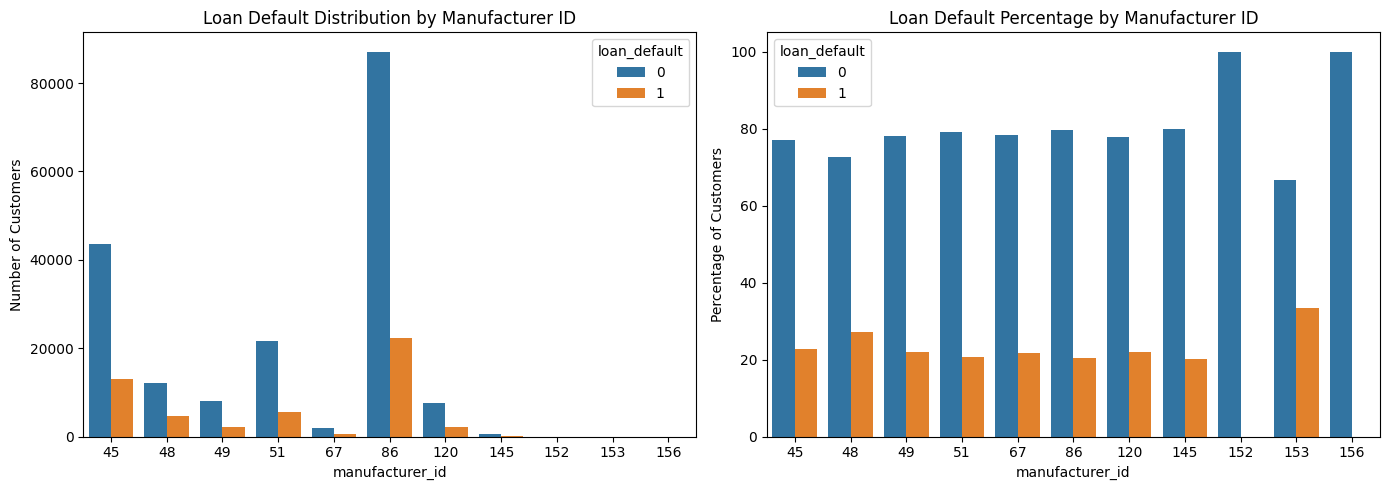

In [79]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.countplot(data=df_loan_default, x="manufacturer_id", hue="loan_default", ax=axes[0])
axes[0].set_title("Loan Default Distribution by Manufacturer ID")
axes[0].set_ylabel("Number of Customers")

df_percent = (
    df_loan_default
    .groupby("manufacturer_id")["loan_default"]
    .value_counts(normalize=True)
    .mul(100)
    .rename("percent")
    .reset_index()
)

sns.barplot(data=df_percent, x="manufacturer_id", y="percent", hue="loan_default", ax=axes[1])
axes[1].set_title("Loan Default Percentage by Manufacturer ID")
axes[1].set_ylabel("Percentage of Customers")

plt.tight_layout()
plt.show()

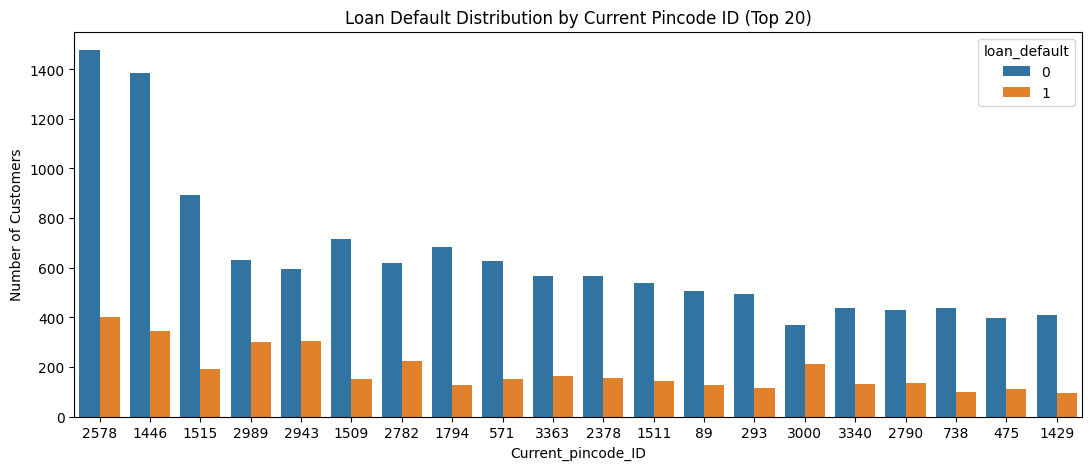

In [80]:
plt.figure(figsize=(13, 5))
top20_pincode_id = df_loan_default["Current_pincode_ID"].value_counts().head(20).index
sns.countplot(
    data=df_loan_default[df_loan_default["Current_pincode_ID"].isin(top20_pincode_id)], 
    x="Current_pincode_ID", 
    hue="loan_default", 
    order=top20_pincode_id
)
plt.title("Loan Default Distribution by Current Pincode ID (Top 20)")
plt.ylabel("Number of Customers")
plt.show()

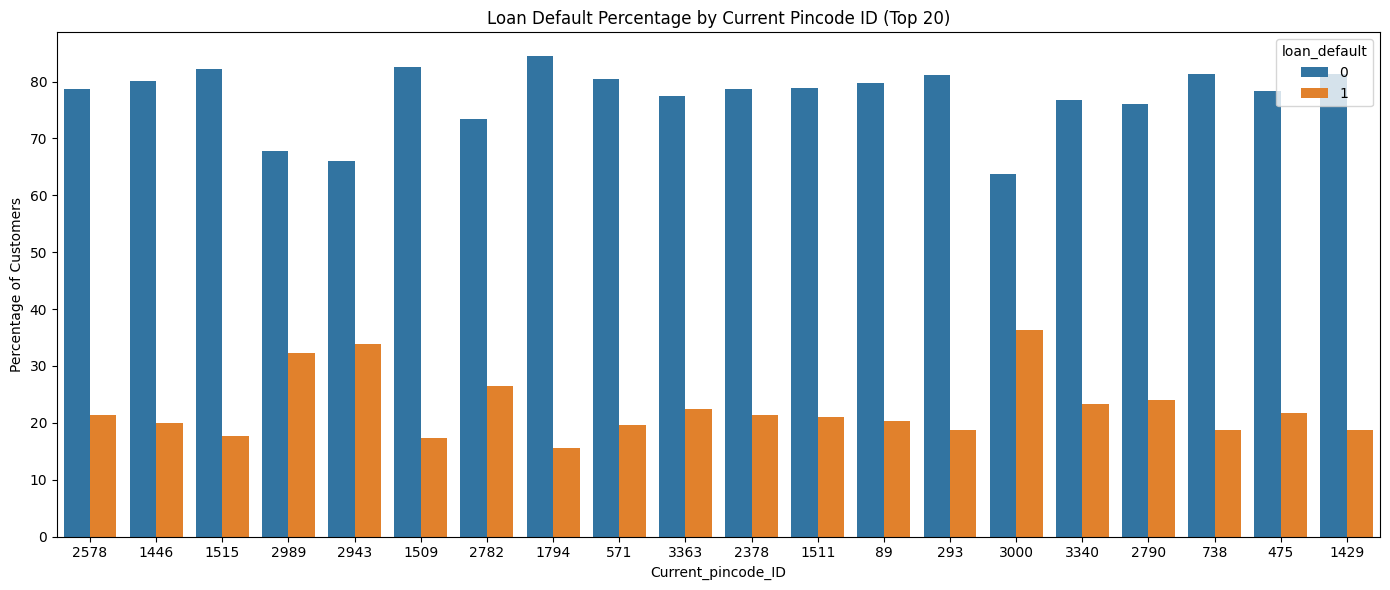

In [81]:
top20_ids = (
    df_loan_default["Current_pincode_ID"]
    .value_counts()
    .head(20)
    .index
)

df_top20 = df_loan_default[df_loan_default["Current_pincode_ID"].isin(top20_ids)]

df_percent = (
    df_top20.groupby("Current_pincode_ID")["loan_default"]
    .value_counts(normalize=True)
    .mul(100)
    .rename("percent")
    .reset_index()
)

plt.figure(figsize=(14, 6))
sns.barplot(data=df_percent, x="Current_pincode_ID", y="percent", hue="loan_default", order=top20_ids)
plt.title("Loan Default Percentage by Current Pincode ID (Top 20)")
plt.ylabel("Percentage of Customers")
plt.tight_layout()
plt.show()

Changing the `Employment.Type` feature type to category:

In [82]:
df_loan_default["Employment.Type"] = df_loan_default["Employment.Type"].astype("category")

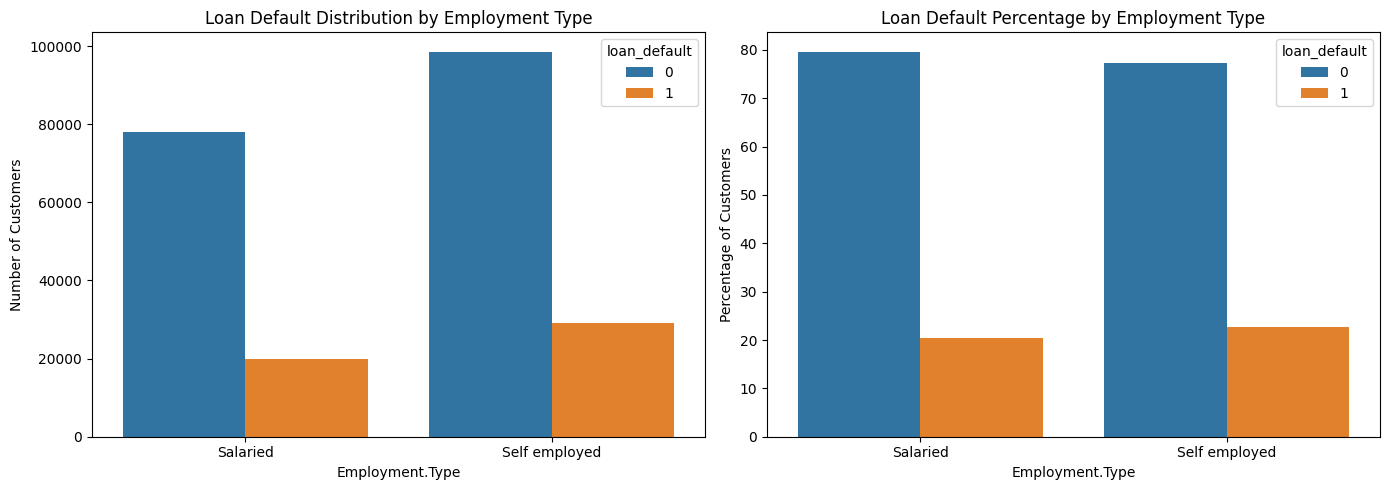

In [83]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.countplot(data=df_loan_default, x="Employment.Type", hue="loan_default", ax=axes[0])
axes[0].set_title("Loan Default Distribution by Employment Type")
axes[0].set_ylabel("Number of Customers")

df_percent = (
    df_loan_default
    .groupby("Employment.Type", observed=True)["loan_default"]
    .value_counts(normalize=True)
    .mul(100)
    .rename("percent")
    .reset_index()
)

sns.barplot(data=df_percent, x="Employment.Type", y="percent", hue="loan_default", ax=axes[1])
axes[1].set_title("Loan Default Percentage by Employment Type")
axes[1].set_ylabel("Percentage of Customers")

plt.tight_layout()
plt.show()

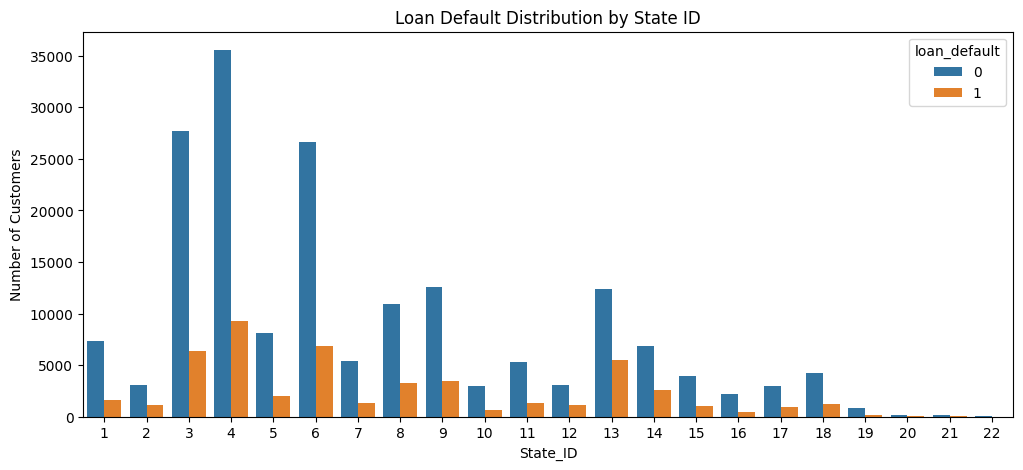

In [84]:
plt.figure(figsize=(12, 5))
sns.countplot(data=df_loan_default, x="State_ID", hue="loan_default")
plt.title("Loan Default Distribution by State ID")
plt.ylabel("Number of Customers")
plt.show()

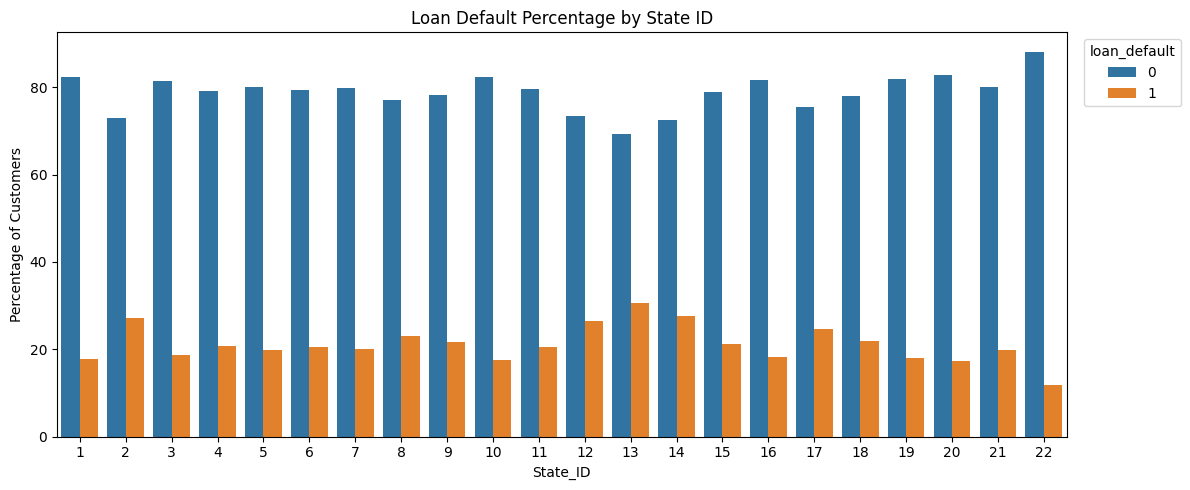

In [85]:
df_percent = (
    df_loan_default
    .groupby("State_ID")["loan_default"]
    .value_counts(normalize=True)
    .mul(100)
    .rename("percent")
    .reset_index()
)

plt.figure(figsize=(12, 5))
sns.barplot(data=df_percent, x="State_ID", y="percent", hue="loan_default")
plt.title("Loan Default Percentage by State ID")
plt.ylabel("Percentage of Customers")
plt.legend(
    title="loan_default",
    loc="upper left",
    bbox_to_anchor=(1.01, 1)
)

plt.tight_layout()
plt.show()

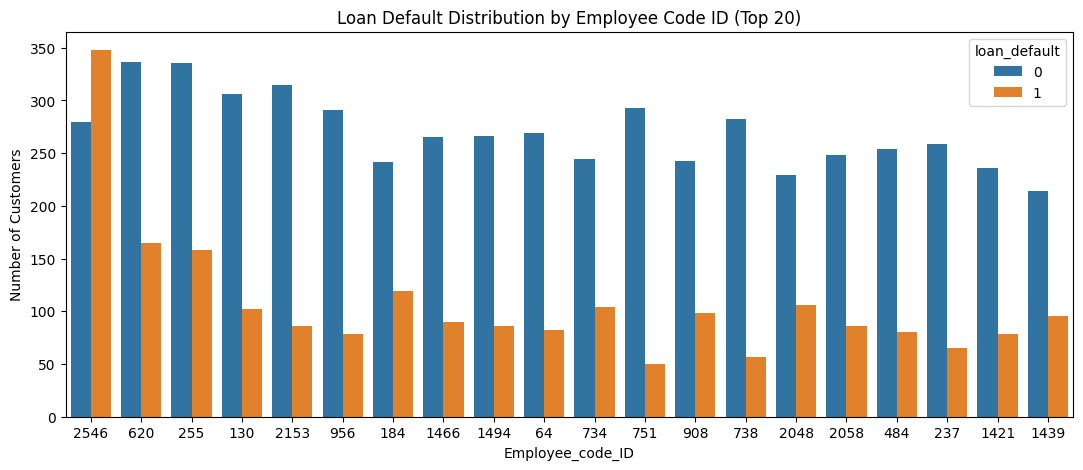

In [86]:
plt.figure(figsize=(13, 5))
top20_employee_code_id = df_loan_default["Employee_code_ID"].value_counts().head(20).index
sns.countplot(data=df_loan_default[df_loan_default["Employee_code_ID"].isin(top20_employee_code_id)], x="Employee_code_ID", hue="loan_default", order=top20_employee_code_id)
plt.title("Loan Default Distribution by Employee Code ID (Top 20)")
plt.ylabel("Number of Customers")
plt.show()

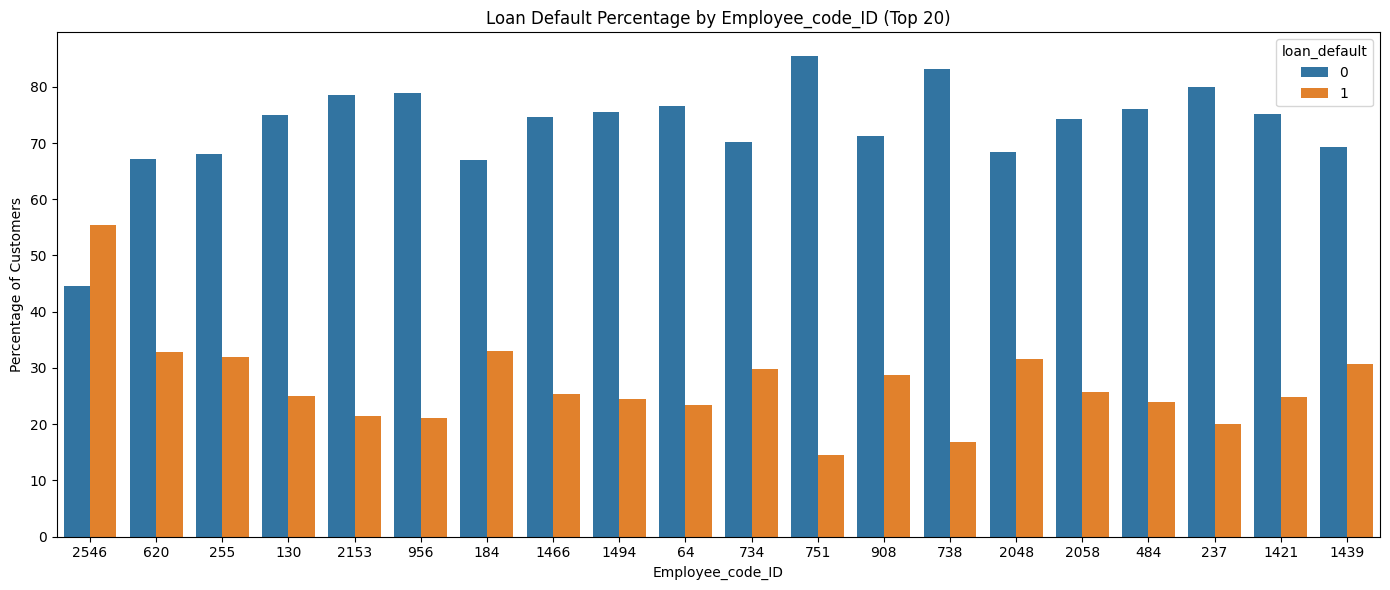

In [87]:
top20_ids = (
    df_loan_default["Employee_code_ID"]
    .value_counts()
    .head(20)
    .index
)

df_top20 = df_loan_default[df_loan_default["Employee_code_ID"].isin(top20_ids)]

df_percent = (
    df_top20.groupby("Employee_code_ID")["loan_default"]
    .value_counts(normalize=True)
    .mul(100)
    .rename("percent")
    .reset_index()
)

plt.figure(figsize=(14, 6))
sns.barplot(data=df_percent, x="Employee_code_ID", y="percent", hue="loan_default", order=top20_ids)
plt.title("Loan Default Percentage by Employee_code_ID (Top 20)")
plt.ylabel("Percentage of Customers")
plt.tight_layout()
plt.show()

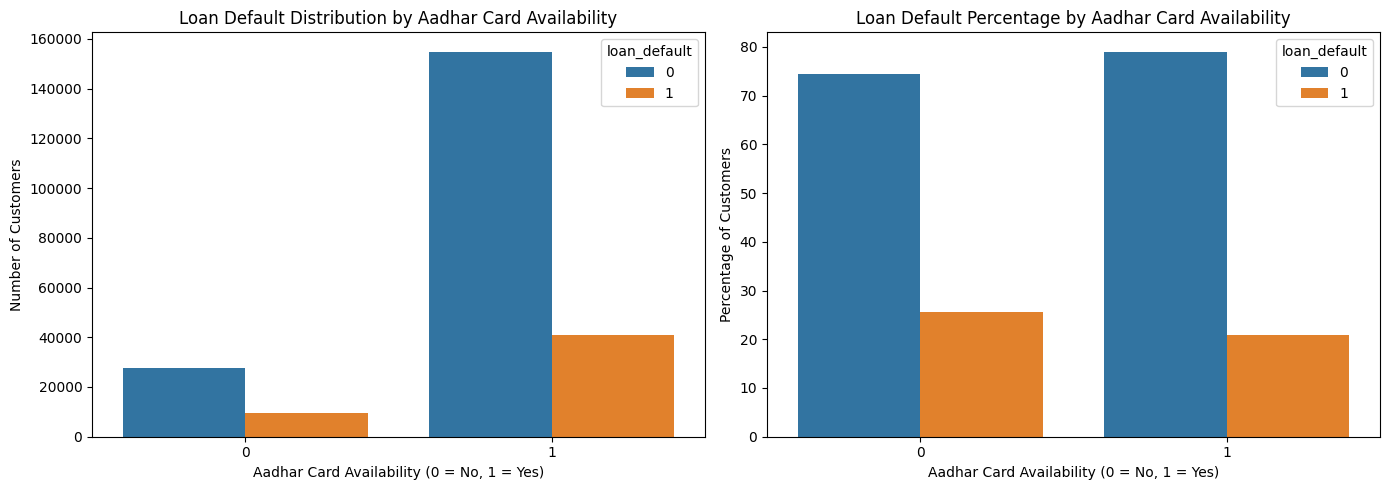

In [88]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.countplot(data=df_loan_default, x="Aadhar_flag", hue="loan_default", ax=axes[0])
axes[0].set_title("Loan Default Distribution by Aadhar Card Availability")
axes[0].set_xlabel("Aadhar Card Availability (0 = No, 1 = Yes)")
axes[0].set_ylabel("Number of Customers")

df_percent = (
    df_loan_default
    .groupby("Aadhar_flag")["loan_default"]
    .value_counts(normalize=True)
    .mul(100)
    .rename("percent")
    .reset_index()
)

sns.barplot(data=df_percent, x="Aadhar_flag", y="percent", hue="loan_default", ax=axes[1])
axes[1].set_title("Loan Default Percentage by Aadhar Card Availability")
axes[1].set_xlabel("Aadhar Card Availability (0 = No, 1 = Yes)")
axes[1].set_ylabel("Percentage of Customers")

plt.tight_layout()
plt.show()

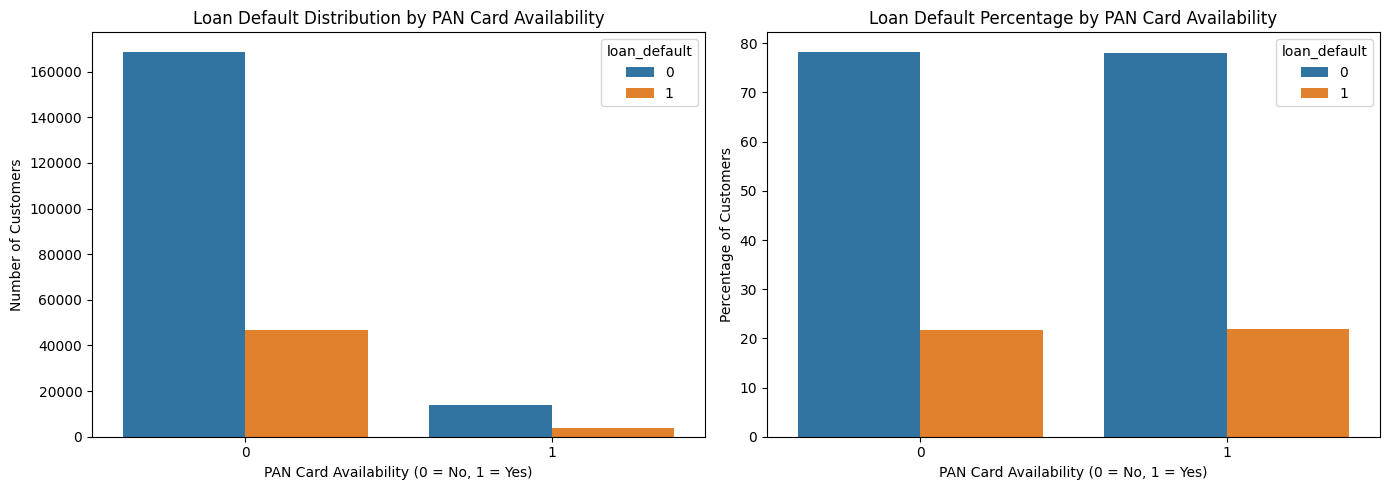

In [89]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.countplot(data=df_loan_default, x="PAN_flag", hue="loan_default", ax=axes[0])
axes[0].set_title("Loan Default Distribution by PAN Card Availability")
axes[0].set_xlabel("PAN Card Availability (0 = No, 1 = Yes)")
axes[0].set_ylabel("Number of Customers")

df_percent = (
    df_loan_default
    .groupby("PAN_flag")["loan_default"]
    .value_counts(normalize=True)
    .mul(100)
    .rename("percent")
    .reset_index()
)

sns.barplot(data=df_percent, x="PAN_flag", y="percent", hue="loan_default", ax=axes[1])
axes[1].set_title("Loan Default Percentage by PAN Card Availability")
axes[1].set_xlabel("PAN Card Availability (0 = No, 1 = Yes)")
axes[1].set_ylabel("Percentage of Customers")

plt.tight_layout()
plt.show()

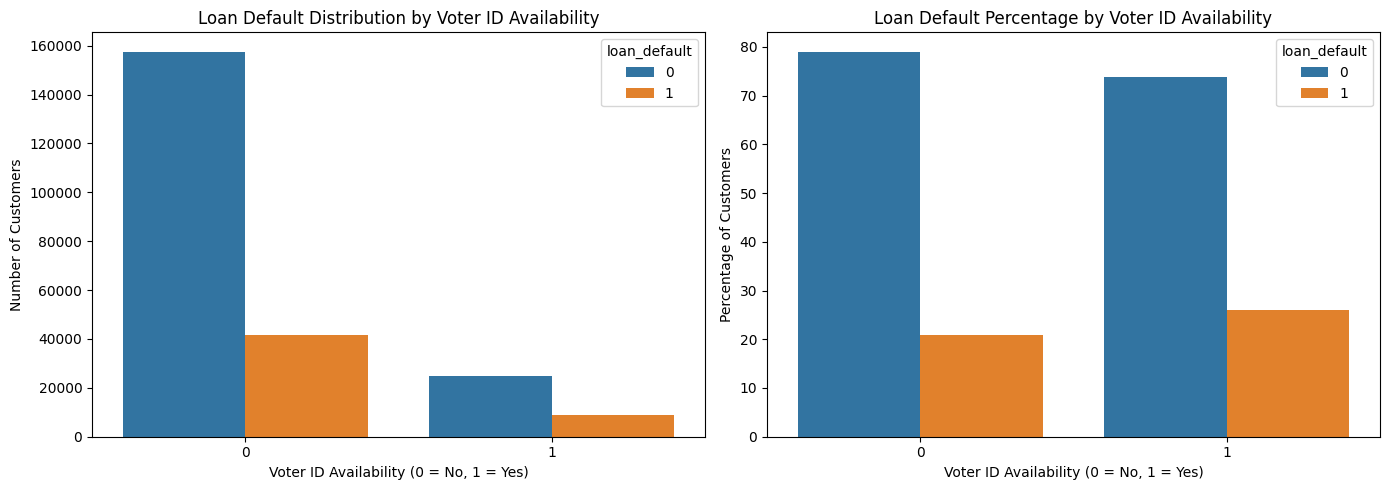

In [90]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.countplot(data=df_loan_default, x="VoterID_flag", hue="loan_default", ax=axes[0])
axes[0].set_title("Loan Default Distribution by Voter ID Availability")
axes[0].set_xlabel("Voter ID Availability (0 = No, 1 = Yes)")
axes[0].set_ylabel("Number of Customers")

df_percent = (
    df_loan_default
    .groupby("VoterID_flag")["loan_default"]
    .value_counts(normalize=True)
    .mul(100)
    .rename("percent")
    .reset_index()
)

sns.barplot(data=df_percent, x="VoterID_flag", y="percent", hue="loan_default", ax=axes[1])
axes[1].set_title("Loan Default Percentage by Voter ID Availability")
axes[1].set_xlabel("Voter ID Availability (0 = No, 1 = Yes)")
axes[1].set_ylabel("Percentage of Customers")

plt.tight_layout()
plt.show()

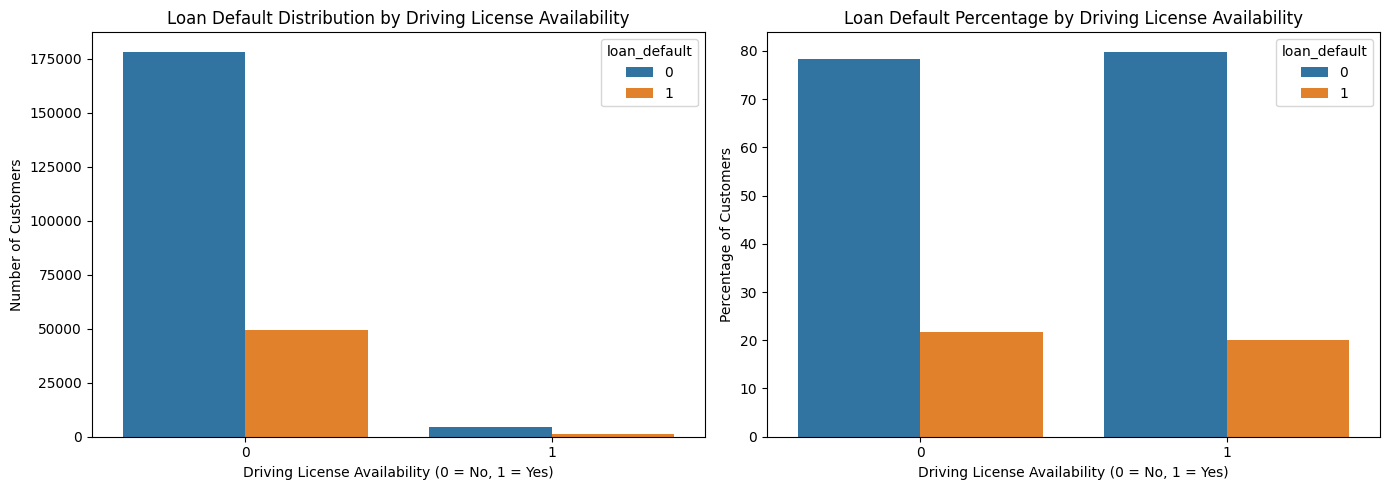

In [91]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.countplot(data=df_loan_default, x="Driving_flag", hue="loan_default", ax=axes[0])
axes[0].set_title("Loan Default Distribution by Driving License Availability")
axes[0].set_xlabel("Driving License Availability (0 = No, 1 = Yes)")
axes[0].set_ylabel("Number of Customers")

df_percent = (
    df_loan_default
    .groupby("Driving_flag")["loan_default"]
    .value_counts(normalize=True)
    .mul(100)
    .rename("percent")
    .reset_index()
)

sns.barplot(data=df_percent, x="Driving_flag", y="percent", hue="loan_default", ax=axes[1])
axes[1].set_title("Loan Default Percentage by Driving License Availability")
axes[1].set_xlabel("Driving License Availability (0 = No, 1 = Yes)")
axes[1].set_ylabel("Percentage of Customers")

plt.tight_layout()
plt.show()

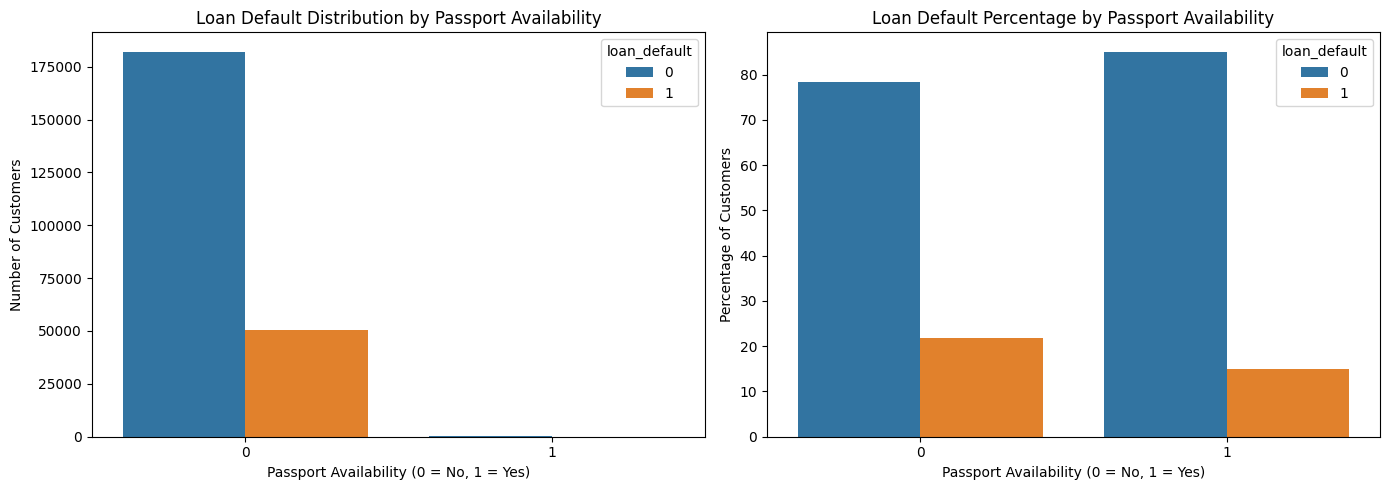

In [92]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.countplot(data=df_loan_default, x="Passport_flag", hue="loan_default", ax=axes[0])
axes[0].set_title("Loan Default Distribution by Passport Availability")
axes[0].set_xlabel("Passport Availability (0 = No, 1 = Yes)")
axes[0].set_ylabel("Number of Customers")

df_percent = (
    df_loan_default
    .groupby("Passport_flag")["loan_default"]
    .value_counts(normalize=True)
    .mul(100)
    .rename("percent")
    .reset_index()
)

sns.barplot(data=df_percent, x="Passport_flag", y="percent", hue="loan_default", ax=axes[1])
axes[1].set_title("Loan Default Percentage by Passport Availability")
axes[1].set_xlabel("Passport Availability (0 = No, 1 = Yes)")
axes[1].set_ylabel("Percentage of Customers")

plt.tight_layout()
plt.show()

Removing uninformative features (information redundancy, multicollinearity, low variability, weak correlation with `loan_default`):

In [93]:
df_loan_default = df_loan_default.drop(columns=["Date.of.Birth", "DisbursalDate", "PERFORM_CNS.SCORE.DESCRIPTION", "PRI.SANCTIONED.AMOUNT", "SEC.SANCTIONED.AMOUNT", "AVERAGE.ACCT.AGE", "CREDIT.HISTORY.LENGTH", "Aadhar_flag", "PAN_flag", "VoterID_flag", "Driving_flag", "Passport_flag"], errors="ignore")
df_loan_default

,disbursed_amount,asset_cost,ltv,branch_id,supplier_id,manufacturer_id,Current_pincode_ID,Employment.Type,State_ID,Employee_code_ID,...,NO.OF_INQUIRIES,loan_default,age,disbursal_day,disbursal_weekday,disbursal_month,days_to_month_end,day_of_year,avg_account_age_months,credit_history_length_months
0,50578,58400,89.55,67,22807,45,1441,Salaried,6,1998,...,0,0,34,3,4,8,28,215,0,0
1,47145,65550,73.23,67,22807,45,1502,Self employed,6,1998,...,0,1,33,26,2,9,4,269,23,23
2,53278,61360,89.63,67,22807,45,1497,Self employed,6,1998,...,0,0,32,1,2,8,30,213,0,0
3,57513,66113,88.48,67,22807,45,1501,Self employed,6,1998,...,1,1,24,26,4,10,5,299,8,15
4,52378,60300,88.39,67,22807,45,1495,Self employed,6,1998,...,1,1,40,26,2,9,4,269,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
233149,63213,105405,60.72,34,20700,48,1050,Salaried,6,3705,...,0,0,30,26,4,10,5,299,21,39
233150,73651,100600,74.95,34,23775,51,990,Self employed,6,3705,...,0,0,29,23,1,10,8,296,6,6
233151,33484,71212,48.45,77,22186,86,2299,Salaried,4,3479,...,0,0,42,24,2,10,7,297,0,0
233152,34259,73286,49.10,77,22186,86,2299,Salaried,4,3479,...,0,0,24,29,5,9,1,272,0,0


Performing feature engineering:

In [94]:
df_fe = df_loan_default.copy()

df_fe["disbursed_amount_log"] = np.log1p(df_fe["disbursed_amount"])
df_fe["asset_cost_log"] = np.log1p(df_fe["asset_cost"])
df_fe["PRI.CURRENT.BALANCE_log"] = np.log1p(df_fe["PRI.CURRENT.BALANCE"])
df_fe["PRI.DISBURSED.AMOUNT_log"]  = np.log1p(df_fe["PRI.DISBURSED.AMOUNT"])
df_fe["SEC.CURRENT.BALANCE_log"] = np.log1p(df_fe["SEC.CURRENT.BALANCE"])
df_fe["SEC.DISBURSED.AMOUNT_log"] = np.log1p(df_fe["SEC.DISBURSED.AMOUNT"])
df_fe["PRIMARY.INSTAL.AMT_log"] = np.log1p(df_fe["PRIMARY.INSTAL.AMT"])
df_fe["SEC.INSTAL.AMT_log"] = np.log1p(df_fe["SEC.INSTAL.AMT"])
df_fe["avg_account_age_months_log"] = np.log1p(df_fe["avg_account_age_months"])
df_fe["credit_history_length_months_log"] = np.log1p(df_fe["credit_history_length_months"])

df_loan_default_fe = df_fe.drop(columns=["disbursed_amount", "asset_cost", "PRI.CURRENT.BALANCE", "PRI.DISBURSED.AMOUNT", "SEC.CURRENT.BALANCE", "SEC.DISBURSED.AMOUNT", "PRIMARY.INSTAL.AMT", "SEC.INSTAL.AMT", "avg_account_age_months", "credit_history_length_months"], errors="ignore")
df_loan_default_fe

,ltv,branch_id,supplier_id,manufacturer_id,Current_pincode_ID,Employment.Type,State_ID,Employee_code_ID,PERFORM_CNS.SCORE,PRI.NO.OF.ACCTS,...,disbursed_amount_log,asset_cost_log,PRI.CURRENT.BALANCE_log,PRI.DISBURSED.AMOUNT_log,SEC.CURRENT.BALANCE_log,SEC.DISBURSED.AMOUNT_log,PRIMARY.INSTAL.AMT_log,SEC.INSTAL.AMT_log,avg_account_age_months_log,credit_history_length_months_log
0,89.55,67,22807,45,1441,Salaried,6,1998,0,0,...,10.831292,10.975088,0.000000,0.000000,0.0,0.0,0.000000,0.0,0.000000,0.000000
1,73.23,67,22807,45,1502,Self employed,6,1998,598,1,...,10.761004,11.090584,10.225607,10.823790,0.0,0.0,7.596894,0.0,3.178054,3.178054
2,89.63,67,22807,45,1497,Self employed,6,1998,0,0,...,10.883298,11.024530,0.000000,0.000000,0.0,0.0,0.000000,0.0,0.000000,0.000000
3,88.48,67,22807,45,1501,Self employed,6,1998,305,3,...,10.959784,11.099136,0.000000,0.000000,0.0,0.0,3.465736,0.0,2.197225,2.772589
4,88.39,67,22807,45,1495,Self employed,6,1998,0,0,...,10.866261,11.007104,0.000000,0.000000,0.0,0.0,0.000000,0.0,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
233149,60.72,34,20700,48,1050,Salaried,6,3705,735,4,...,11.054281,11.565575,12.875040,12.938763,0.0,0.0,8.315077,0.0,3.091042,3.688879
233150,74.95,34,23775,51,990,Self employed,6,3705,825,1,...,11.207107,11.518917,0.000000,0.000000,0.0,0.0,7.356280,0.0,1.945910,1.945910
233151,48.45,77,22186,86,2299,Salaried,4,3479,0,0,...,10.418853,11.173431,0.000000,0.000000,0.0,0.0,0.000000,0.0,0.000000,0.000000
233152,49.10,77,22186,86,2299,Salaried,4,3479,0,0,...,10.441734,11.202139,0.000000,0.000000,0.0,0.0,0.000000,0.0,0.000000,0.000000


Implementation of a model training and evaluation function for the default probability prediction task:

In [95]:
def lightgbm_optuna_experiment(df):

    data = df.copy()
    X = data.drop(columns=["loan_default"])
    y = data["loan_default"]

    id_features = [
        "branch_id", "supplier_id", "manufacturer_id",
        "Current_pincode_ID", "State_ID", "Employee_code_ID"
    ]

    # Frequency Encoding
    for col in id_features:
        if col in X.columns:
            freq = X[col].value_counts(normalize=True)
            X[col] = X[col].map(freq).fillna(0)

    cat_features = X.select_dtypes(include=["category"]).columns.tolist()

    for col in cat_features:
        X[col] = X[col].fillna(X[col].mode()[0]).astype("category")

    num_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()

    for col in num_features:
        X[col] = X[col].fillna(X[col].median())

    # Stratified KFold 
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    # Optuna objective
    def objective(trial):

        params = {
            "objective": "binary",
            "metric": "auc",
            "boosting_type": "gbdt",
            "learning_rate": trial.suggest_float("learning_rate", 0.003, 0.02, log=True),

            "num_leaves": trial.suggest_int("num_leaves", 31, 255),
            "max_depth": trial.suggest_int("max_depth", 6, 12),

            "min_child_samples": trial.suggest_int("min_child_samples", 50, 300),

            "lambda_l1": trial.suggest_float("lambda_l1", 0.0, 5.0),
            "lambda_l2": trial.suggest_float("lambda_l2", 0.0, 20.0),

            "feature_fraction": trial.suggest_float("feature_fraction", 0.5, 0.9),
            "bagging_fraction": trial.suggest_float("bagging_fraction", 0.6, 0.9),
            "bagging_freq": trial.suggest_int("bagging_freq", 1, 7),

            "n_estimators": 5000,
            "random_state": 42,
            "verbosity": -1,
        }

        fold_aucs = []

        for train_idx, valid_idx in skf.split(X, y):

            X_train, X_valid = X.iloc[train_idx], X.iloc[valid_idx]
            y_train, y_valid = y.iloc[train_idx], y.iloc[valid_idx]

            model = LGBMClassifier(**params)

            model.fit(
                X_train, y_train,
                eval_set=[(X_valid, y_valid)],
                eval_metric="auc",
                categorical_feature=cat_features,
                callbacks=[early_stopping(stopping_rounds=100)],
            )

            preds = model.predict_proba(X_valid)[:, 1]
            fold_auc = roc_auc_score(y_valid, preds)
            fold_aucs.append(fold_auc)

        return np.mean(fold_aucs)

    # Optuna
    study = optuna.create_study(direction="maximize")
    study.optimize(objective, n_trials=30)

    print("\n=== Best Optuna Parameters ===")
    print(study.best_params)

    print(f"\nBest mean CV ROC AUC: {study.best_value:.4f}")

    # Final model
    best_params = {
        **study.best_params,
        "objective": "binary",
        "n_estimators": 2000,
        "random_state": 42,
        "verbosity": -1
    }

    final_model = LGBMClassifier(**best_params)

    final_model.fit(X, y, categorical_feature=cat_features)

    # Feature Importance
    importances = final_model.feature_importances_
    fi_df = pd.DataFrame({
        "feature": X.columns,
        "importance": importances
    }).sort_values(by="importance", ascending=False)

    print("\n=== TOP 25 FEATURE IMPORTANCES ===")
    print(fi_df.head(25))

    plt.figure(figsize=(10, 12))
    sns.barplot(data=fi_df.head(25), x="importance", y="feature")
    plt.title("Top 25 Feature Importances")
    plt.tight_layout()
    plt.show()

   # SHAP Interpretation
    print("\n=== SHAP Interpretation ===")

    shap.initjs()

    explainer = shap.TreeExplainer(final_model)
    shap_values = explainer.shap_values(X)

    plt.figure(figsize=(10, 8))
    shap.summary_plot(shap_values, X, show=False)
    plt.show()

    plt.figure(figsize=(10, 8))
    shap.summary_plot(shap_values, X, plot_type="bar", show=False)
    plt.show()

    return final_model, study, fi_df


[I 2025-11-27 19:07:32,701] A new study created in memory with name: no-name-b2c1fbeb-6821-4fbb-84cd-13e6ca8d2819


Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[3167]	valid_0's auc: 0.673082
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[3076]	valid_0's auc: 0.674839
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[3550]	valid_0's auc: 0.671132
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[3034]	valid_0's auc: 0.673976
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[3684]	valid_0's auc: 0.673185


[I 2025-11-27 19:12:46,054] Trial 0 finished with value: 0.6732429483714713 and parameters: {'learning_rate': 0.0032591219287374526, 'num_leaves': 216, 'max_depth': 10, 'min_child_samples': 150, 'lambda_l1': 1.707753997858394, 'lambda_l2': 5.667512208235788, 'feature_fraction': 0.8166770052013873, 'bagging_fraction': 0.7369378903890975, 'bagging_freq': 3}. Best is trial 0 with value: 0.6732429483714713.


Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[3928]	valid_0's auc: 0.673866
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[4600]	valid_0's auc: 0.675179
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[3945]	valid_0's auc: 0.671644
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[3637]	valid_0's auc: 0.674623
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[4685]	valid_0's auc: 0.673844


[I 2025-11-27 19:18:05,298] Trial 1 finished with value: 0.6738312557445161 and parameters: {'learning_rate': 0.0036884357507359633, 'num_leaves': 162, 'max_depth': 8, 'min_child_samples': 60, 'lambda_l1': 1.8768372208602324, 'lambda_l2': 13.423089342931089, 'feature_fraction': 0.5158000047305341, 'bagging_fraction': 0.743947938649613, 'bagging_freq': 4}. Best is trial 1 with value: 0.6738312557445161.


Training until validation scores don't improve for 100 rounds
Did not meet early stopping. Best iteration is:
[4997]	valid_0's auc: 0.672555
Training until validation scores don't improve for 100 rounds
Did not meet early stopping. Best iteration is:
[4995]	valid_0's auc: 0.674066
Training until validation scores don't improve for 100 rounds
Did not meet early stopping. Best iteration is:
[5000]	valid_0's auc: 0.670639
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[4866]	valid_0's auc: 0.674102
Training until validation scores don't improve for 100 rounds
Did not meet early stopping. Best iteration is:
[4995]	valid_0's auc: 0.673096


[I 2025-11-27 19:22:25,436] Trial 2 finished with value: 0.6728918394027442 and parameters: {'learning_rate': 0.004850910757981346, 'num_leaves': 41, 'max_depth': 6, 'min_child_samples': 102, 'lambda_l1': 3.489235465746967, 'lambda_l2': 11.891760963545366, 'feature_fraction': 0.5242583081937535, 'bagging_fraction': 0.6513391205535006, 'bagging_freq': 6}. Best is trial 1 with value: 0.6738312557445161.


Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[2809]	valid_0's auc: 0.672793
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[2652]	valid_0's auc: 0.674642
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[3070]	valid_0's auc: 0.670983
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[2695]	valid_0's auc: 0.673896
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[3304]	valid_0's auc: 0.673092


[I 2025-11-27 19:24:55,687] Trial 3 finished with value: 0.6730809748306161 and parameters: {'learning_rate': 0.009286908205483429, 'num_leaves': 222, 'max_depth': 6, 'min_child_samples': 298, 'lambda_l1': 1.5081556854555784, 'lambda_l2': 10.134744522932099, 'feature_fraction': 0.6394789746816654, 'bagging_fraction': 0.782249515769591, 'bagging_freq': 7}. Best is trial 1 with value: 0.6738312557445161.


Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[1568]	valid_0's auc: 0.672844
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[1316]	valid_0's auc: 0.674003
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[1413]	valid_0's auc: 0.671142
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[1241]	valid_0's auc: 0.673718
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[1321]	valid_0's auc: 0.67325


[I 2025-11-27 19:26:16,466] Trial 4 finished with value: 0.6729912517337953 and parameters: {'learning_rate': 0.019687494949086518, 'num_leaves': 108, 'max_depth': 6, 'min_child_samples': 152, 'lambda_l1': 3.6960517061125135, 'lambda_l2': 19.008555628494854, 'feature_fraction': 0.711983300834409, 'bagging_fraction': 0.7532637936766502, 'bagging_freq': 2}. Best is trial 1 with value: 0.6738312557445161.


Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[3762]	valid_0's auc: 0.673083
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[4220]	valid_0's auc: 0.674984
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[4169]	valid_0's auc: 0.671615
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[3456]	valid_0's auc: 0.674643
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[4264]	valid_0's auc: 0.674191


[I 2025-11-27 19:30:33,383] Trial 5 finished with value: 0.6737031449092555 and parameters: {'learning_rate': 0.004628281910068395, 'num_leaves': 186, 'max_depth': 7, 'min_child_samples': 141, 'lambda_l1': 2.753325765649055, 'lambda_l2': 1.616010905893106, 'feature_fraction': 0.5779456381595464, 'bagging_fraction': 0.774098181184349, 'bagging_freq': 6}. Best is trial 1 with value: 0.6738312557445161.


Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[3869]	valid_0's auc: 0.67325
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[2754]	valid_0's auc: 0.674448
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[3714]	valid_0's auc: 0.671382
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[2460]	valid_0's auc: 0.674019
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[3536]	valid_0's auc: 0.673744


[I 2025-11-27 19:33:26,859] Trial 6 finished with value: 0.673368597799053 and parameters: {'learning_rate': 0.008690857364264592, 'num_leaves': 78, 'max_depth': 6, 'min_child_samples': 258, 'lambda_l1': 2.8640970968573227, 'lambda_l2': 18.77544455634146, 'feature_fraction': 0.6643225307873957, 'bagging_fraction': 0.8797091501108754, 'bagging_freq': 3}. Best is trial 1 with value: 0.6738312557445161.


Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[1853]	valid_0's auc: 0.672453
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[1838]	valid_0's auc: 0.674196
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[1028]	valid_0's auc: 0.668475
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[1818]	valid_0's auc: 0.672892
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[1995]	valid_0's auc: 0.672698


[I 2025-11-27 19:34:47,277] Trial 7 finished with value: 0.6721429633632401 and parameters: {'learning_rate': 0.014172703914876907, 'num_leaves': 40, 'max_depth': 6, 'min_child_samples': 238, 'lambda_l1': 3.0307904276485527, 'lambda_l2': 14.617572506938771, 'feature_fraction': 0.8147857570087566, 'bagging_fraction': 0.6320829991285811, 'bagging_freq': 5}. Best is trial 1 with value: 0.6738312557445161.


Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[2205]	valid_0's auc: 0.673794
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[2663]	valid_0's auc: 0.675253
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[2538]	valid_0's auc: 0.671861
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[2148]	valid_0's auc: 0.674325
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[2344]	valid_0's auc: 0.673382


[I 2025-11-27 19:38:28,201] Trial 8 finished with value: 0.6737231989159028 and parameters: {'learning_rate': 0.0039293361355311664, 'num_leaves': 196, 'max_depth': 12, 'min_child_samples': 75, 'lambda_l1': 3.5591923328256296, 'lambda_l2': 3.3803857009587657, 'feature_fraction': 0.5221782520284076, 'bagging_fraction': 0.636053880325836, 'bagging_freq': 5}. Best is trial 1 with value: 0.6738312557445161.


Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[1601]	valid_0's auc: 0.673753
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[1513]	valid_0's auc: 0.67489
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[1767]	valid_0's auc: 0.67169
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[1416]	valid_0's auc: 0.674341
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[1782]	valid_0's auc: 0.673737


[I 2025-11-27 19:40:23,076] Trial 9 finished with value: 0.6736820412696839 and parameters: {'learning_rate': 0.010386791361696734, 'num_leaves': 79, 'max_depth': 9, 'min_child_samples': 252, 'lambda_l1': 3.402179359478341, 'lambda_l2': 6.4959252517666215, 'feature_fraction': 0.6103505496297505, 'bagging_fraction': 0.8026156474917248, 'bagging_freq': 3}. Best is trial 1 with value: 0.6738312557445161.


Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[2685]	valid_0's auc: 0.673071
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[2442]	valid_0's auc: 0.674128
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[2781]	valid_0's auc: 0.670902
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[2046]	valid_0's auc: 0.674065
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[2570]	valid_0's auc: 0.672781


[I 2025-11-27 19:42:55,581] Trial 10 finished with value: 0.6729894303534609 and parameters: {'learning_rate': 0.00605714099593988, 'num_leaves': 152, 'max_depth': 8, 'min_child_samples': 67, 'lambda_l1': 0.07916179522050015, 'lambda_l2': 14.919434015700972, 'feature_fraction': 0.8986370759189961, 'bagging_fraction': 0.6993928954514053, 'bagging_freq': 1}. Best is trial 1 with value: 0.6738312557445161.


Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[3424]	valid_0's auc: 0.673797
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[3377]	valid_0's auc: 0.674868
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[3663]	valid_0's auc: 0.67163
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[3155]	valid_0's auc: 0.674351
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[3775]	valid_0's auc: 0.673795


[I 2025-11-27 19:48:22,845] Trial 11 finished with value: 0.6736880883586356 and parameters: {'learning_rate': 0.003076166709216995, 'num_leaves': 168, 'max_depth': 12, 'min_child_samples': 61, 'lambda_l1': 4.41948519890355, 'lambda_l2': 1.066401912212088, 'feature_fraction': 0.5333296123377042, 'bagging_fraction': 0.6034239164557005, 'bagging_freq': 5}. Best is trial 1 with value: 0.6738312557445161.


Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[2029]	valid_0's auc: 0.673332
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[2301]	valid_0's auc: 0.675179
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[2785]	valid_0's auc: 0.672076
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[2181]	valid_0's auc: 0.674537
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[2684]	valid_0's auc: 0.674041


[I 2025-11-27 19:52:35,334] Trial 12 finished with value: 0.6738331814997983 and parameters: {'learning_rate': 0.004215008008736959, 'num_leaves': 255, 'max_depth': 12, 'min_child_samples': 106, 'lambda_l1': 1.8082296985296382, 'lambda_l2': 6.026128704754209, 'feature_fraction': 0.5038838477842035, 'bagging_fraction': 0.6893267506401163, 'bagging_freq': 4}. Best is trial 12 with value: 0.6738331814997983.


Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[1812]	valid_0's auc: 0.673441
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[2125]	valid_0's auc: 0.674928
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[1962]	valid_0's auc: 0.671611
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[1517]	valid_0's auc: 0.674335
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[2029]	valid_0's auc: 0.673532


[I 2025-11-27 19:55:36,165] Trial 13 finished with value: 0.6735693440726018 and parameters: {'learning_rate': 0.0063236843264715, 'num_leaves': 254, 'max_depth': 10, 'min_child_samples': 108, 'lambda_l1': 1.7758459460856428, 'lambda_l2': 7.795802668615527, 'feature_fraction': 0.5906209240337472, 'bagging_fraction': 0.6852006677912966, 'bagging_freq': 4}. Best is trial 12 with value: 0.6738331814997983.


Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[2774]	valid_0's auc: 0.673156
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[2642]	valid_0's auc: 0.67513
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[2904]	valid_0's auc: 0.671456
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[2436]	valid_0's auc: 0.674085
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[2669]	valid_0's auc: 0.672959


[I 2025-11-27 19:59:47,928] Trial 14 finished with value: 0.6733569866339668 and parameters: {'learning_rate': 0.004256285444980392, 'num_leaves': 255, 'max_depth': 11, 'min_child_samples': 196, 'lambda_l1': 0.704105940349445, 'lambda_l2': 12.820604556033427, 'feature_fraction': 0.7249240401205348, 'bagging_fraction': 0.7080299362904692, 'bagging_freq': 4}. Best is trial 12 with value: 0.6738331814997983.


Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[3105]	valid_0's auc: 0.673932
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[2830]	valid_0's auc: 0.675322
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[3024]	valid_0's auc: 0.672024
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[2166]	valid_0's auc: 0.674666
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[2900]	valid_0's auc: 0.67429


[I 2025-11-27 20:03:39,058] Trial 15 finished with value: 0.6740467528380121 and parameters: {'learning_rate': 0.006086424883049587, 'num_leaves': 117, 'max_depth': 8, 'min_child_samples': 107, 'lambda_l1': 2.1467986715361524, 'lambda_l2': 8.688275267175456, 'feature_fraction': 0.5605965173698969, 'bagging_fraction': 0.8700286338455482, 'bagging_freq': 2}. Best is trial 15 with value: 0.6740467528380121.


Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[2619]	valid_0's auc: 0.674036
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[2484]	valid_0's auc: 0.67576
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[2556]	valid_0's auc: 0.672413
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[2235]	valid_0's auc: 0.674767
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[2843]	valid_0's auc: 0.674064


[I 2025-11-27 20:06:34,573] Trial 16 finished with value: 0.6742080169586658 and parameters: {'learning_rate': 0.006008775902221299, 'num_leaves': 128, 'max_depth': 9, 'min_child_samples': 110, 'lambda_l1': 1.109209276486105, 'lambda_l2': 9.008128425470053, 'feature_fraction': 0.5676229900042562, 'bagging_fraction': 0.8942482224965881, 'bagging_freq': 1}. Best is trial 16 with value: 0.6742080169586658.


Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[3186]	valid_0's auc: 0.673868
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[2996]	valid_0's auc: 0.675558
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[2556]	valid_0's auc: 0.672176
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[2550]	valid_0's auc: 0.674953
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[3054]	valid_0's auc: 0.67393


[I 2025-11-27 20:09:51,633] Trial 17 finished with value: 0.6740972278799106 and parameters: {'learning_rate': 0.00653195827392463, 'num_leaves': 121, 'max_depth': 8, 'min_child_samples': 183, 'lambda_l1': 0.9532988515287579, 'lambda_l2': 9.499253456196563, 'feature_fraction': 0.5702069208718037, 'bagging_fraction': 0.8948934357505439, 'bagging_freq': 1}. Best is trial 16 with value: 0.6742080169586658.


Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[2417]	valid_0's auc: 0.673828
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[2215]	valid_0's auc: 0.675401
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[2280]	valid_0's auc: 0.672466
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[2103]	valid_0's auc: 0.674449
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[2449]	valid_0's auc: 0.674043


[I 2025-11-27 20:12:45,090] Trial 18 finished with value: 0.6740374918092933 and parameters: {'learning_rate': 0.007289868711321926, 'num_leaves': 125, 'max_depth': 9, 'min_child_samples': 199, 'lambda_l1': 1.0417528715590505, 'lambda_l2': 10.895205321310097, 'feature_fraction': 0.6604556315587338, 'bagging_fraction': 0.8418427446957761, 'bagging_freq': 1}. Best is trial 16 with value: 0.6742080169586658.


Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[1092]	valid_0's auc: 0.672665
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[1289]	valid_0's auc: 0.67466
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[1507]	valid_0's auc: 0.671583
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[1305]	valid_0's auc: 0.674266
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[1283]	valid_0's auc: 0.673601


[I 2025-11-27 20:14:01,155] Trial 19 finished with value: 0.6733551268986602 and parameters: {'learning_rate': 0.012402827884302059, 'num_leaves': 88, 'max_depth': 9, 'min_child_samples': 180, 'lambda_l1': 0.13008996065252865, 'lambda_l2': 4.310202871723256, 'feature_fraction': 0.761967416021129, 'bagging_fraction': 0.8971180910681485, 'bagging_freq': 1}. Best is trial 16 with value: 0.6742080169586658.


Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[2956]	valid_0's auc: 0.674083
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[2628]	valid_0's auc: 0.675295
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[3021]	valid_0's auc: 0.67245
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[2267]	valid_0's auc: 0.67474
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[2629]	valid_0's auc: 0.673764


[I 2025-11-27 20:17:55,888] Trial 20 finished with value: 0.6740664098824298 and parameters: {'learning_rate': 0.005191887277641028, 'num_leaves': 130, 'max_depth': 10, 'min_child_samples': 218, 'lambda_l1': 1.002552553095821, 'lambda_l2': 16.335996881669658, 'feature_fraction': 0.6258413305565846, 'bagging_fraction': 0.8435386304053765, 'bagging_freq': 2}. Best is trial 16 with value: 0.6742080169586658.


Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[2384]	valid_0's auc: 0.673779
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[2913]	valid_0's auc: 0.675713
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[2908]	valid_0's auc: 0.672316
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[2167]	valid_0's auc: 0.674699
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[2463]	valid_0's auc: 0.673748


[I 2025-11-27 20:21:30,560] Trial 21 finished with value: 0.6740510124746867 and parameters: {'learning_rate': 0.005368265080677128, 'num_leaves': 139, 'max_depth': 10, 'min_child_samples': 219, 'lambda_l1': 0.9866177177818336, 'lambda_l2': 9.517048138586297, 'feature_fraction': 0.6181072956484975, 'bagging_fraction': 0.8331360792749123, 'bagging_freq': 2}. Best is trial 16 with value: 0.6742080169586658.


Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[2267]	valid_0's auc: 0.674033
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[1987]	valid_0's auc: 0.675544
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[2135]	valid_0's auc: 0.672288
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[1898]	valid_0's auc: 0.674746
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[2426]	valid_0's auc: 0.674325


[I 2025-11-27 20:24:00,506] Trial 22 finished with value: 0.674187258259624 and parameters: {'learning_rate': 0.007220730452131089, 'num_leaves': 98, 'max_depth': 11, 'min_child_samples': 168, 'lambda_l1': 0.6950534287065624, 'lambda_l2': 16.530646560980184, 'feature_fraction': 0.563334183440515, 'bagging_fraction': 0.8547558968225692, 'bagging_freq': 1}. Best is trial 16 with value: 0.6742080169586658.


Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[2347]	valid_0's auc: 0.67414
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[2572]	valid_0's auc: 0.675834
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[2498]	valid_0's auc: 0.67257
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[1796]	valid_0's auc: 0.67485
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[2572]	valid_0's auc: 0.674348


[I 2025-11-27 20:26:40,670] Trial 23 finished with value: 0.6743485174826097 and parameters: {'learning_rate': 0.007399417005943629, 'num_leaves': 96, 'max_depth': 11, 'min_child_samples': 131, 'lambda_l1': 0.5830667112260471, 'lambda_l2': 16.777286563091923, 'feature_fraction': 0.5585970792536588, 'bagging_fraction': 0.8975335409249777, 'bagging_freq': 1}. Best is trial 23 with value: 0.6743485174826097.


Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[1939]	valid_0's auc: 0.673907
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[1801]	valid_0's auc: 0.675199
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[1922]	valid_0's auc: 0.672053
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[1948]	valid_0's auc: 0.674715
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[2474]	valid_0's auc: 0.674649


[I 2025-11-27 20:29:02,430] Trial 24 finished with value: 0.674104708217182 and parameters: {'learning_rate': 0.00772720963851927, 'num_leaves': 95, 'max_depth': 11, 'min_child_samples': 132, 'lambda_l1': 0.4306068274208975, 'lambda_l2': 17.047160817540544, 'feature_fraction': 0.5617726847429071, 'bagging_fraction': 0.8589426461626464, 'bagging_freq': 1}. Best is trial 23 with value: 0.6743485174826097.


Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[1755]	valid_0's auc: 0.673156
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[1831]	valid_0's auc: 0.674841
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[1954]	valid_0's auc: 0.671749
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[1669]	valid_0's auc: 0.674437
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[1694]	valid_0's auc: 0.673246


[I 2025-11-27 20:31:04,494] Trial 25 finished with value: 0.6734859859117894 and parameters: {'learning_rate': 0.010755086019762293, 'num_leaves': 56, 'max_depth': 11, 'min_child_samples': 127, 'lambda_l1': 1.308470275859459, 'lambda_l2': 19.896624023167636, 'feature_fraction': 0.6659118859967074, 'bagging_fraction': 0.8117219267913587, 'bagging_freq': 2}. Best is trial 23 with value: 0.6743485174826097.


Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[2881]	valid_0's auc: 0.673876
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[2606]	valid_0's auc: 0.675419
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[2552]	valid_0's auc: 0.672193
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[2149]	valid_0's auc: 0.674654
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[2851]	valid_0's auc: 0.674223


[I 2025-11-27 20:33:41,714] Trial 26 finished with value: 0.6740731684288009 and parameters: {'learning_rate': 0.007162042797972121, 'num_leaves': 60, 'max_depth': 11, 'min_child_samples': 161, 'lambda_l1': 2.3131238733628483, 'lambda_l2': 17.126527104329803, 'feature_fraction': 0.5517797782364309, 'bagging_fraction': 0.875655974712592, 'bagging_freq': 1}. Best is trial 23 with value: 0.6743485174826097.


Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[1714]	valid_0's auc: 0.673535
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[1814]	valid_0's auc: 0.674653
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[2186]	valid_0's auc: 0.671795
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[1478]	valid_0's auc: 0.674484
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[1984]	valid_0's auc: 0.67424


[I 2025-11-27 20:36:10,481] Trial 27 finished with value: 0.6737414600611211 and parameters: {'learning_rate': 0.008658282004508496, 'num_leaves': 99, 'max_depth': 9, 'min_child_samples': 88, 'lambda_l1': 0.4864814034928807, 'lambda_l2': 14.647893141212249, 'feature_fraction': 0.6035117369472921, 'bagging_fraction': 0.8128521578450887, 'bagging_freq': 2}. Best is trial 23 with value: 0.6743485174826097.


Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[3331]	valid_0's auc: 0.673964
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[3413]	valid_0's auc: 0.675019
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[2975]	valid_0's auc: 0.671549
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[2875]	valid_0's auc: 0.674469
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[3094]	valid_0's auc: 0.6739


[I 2025-11-27 20:39:38,738] Trial 28 finished with value: 0.6737802056221585 and parameters: {'learning_rate': 0.0055032470768030415, 'num_leaves': 66, 'max_depth': 10, 'min_child_samples': 125, 'lambda_l1': 0.5030437689363898, 'lambda_l2': 12.14852074002686, 'feature_fraction': 0.6904695426275141, 'bagging_fraction': 0.8564335692078714, 'bagging_freq': 3}. Best is trial 23 with value: 0.6743485174826097.


Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[976]	valid_0's auc: 0.673122
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[1037]	valid_0's auc: 0.674225
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[1041]	valid_0's auc: 0.671226
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[826]	valid_0's auc: 0.674188
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[1068]	valid_0's auc: 0.673761


[I 2025-11-27 20:40:49,553] Trial 29 finished with value: 0.67330446050818 and parameters: {'learning_rate': 0.013944073693316874, 'num_leaves': 141, 'max_depth': 11, 'min_child_samples': 164, 'lambda_l1': 1.2327964981990924, 'lambda_l2': 15.582772965919322, 'feature_fraction': 0.750513106986988, 'bagging_fraction': 0.89348943013553, 'bagging_freq': 1}. Best is trial 23 with value: 0.6743485174826097.



=== Best Optuna Parameters ===
{'learning_rate': 0.007399417005943629, 'num_leaves': 96, 'max_depth': 11, 'min_child_samples': 131, 'lambda_l1': 0.5830667112260471, 'lambda_l2': 16.777286563091923, 'feature_fraction': 0.5585970792536588, 'bagging_fraction': 0.8975335409249777, 'bagging_freq': 1}

Best mean CV ROC AUC: 0.6743

=== TOP 25 FEATURE IMPORTANCES ===
                             feature  importance
4                 Current_pincode_ID       13311
2                        supplier_id       13087
7                   Employee_code_ID       13082
1                          branch_id       12752
0                                ltv       11744
24              disbursed_amount_log       10656
25                    asset_cost_log       10504
23                       day_of_year        9518
18                               age        9222
8                  PERFORM_CNS.SCORE        8506
6                           State_ID        7574
30            PRIMARY.INSTAL.AMT_log        6988

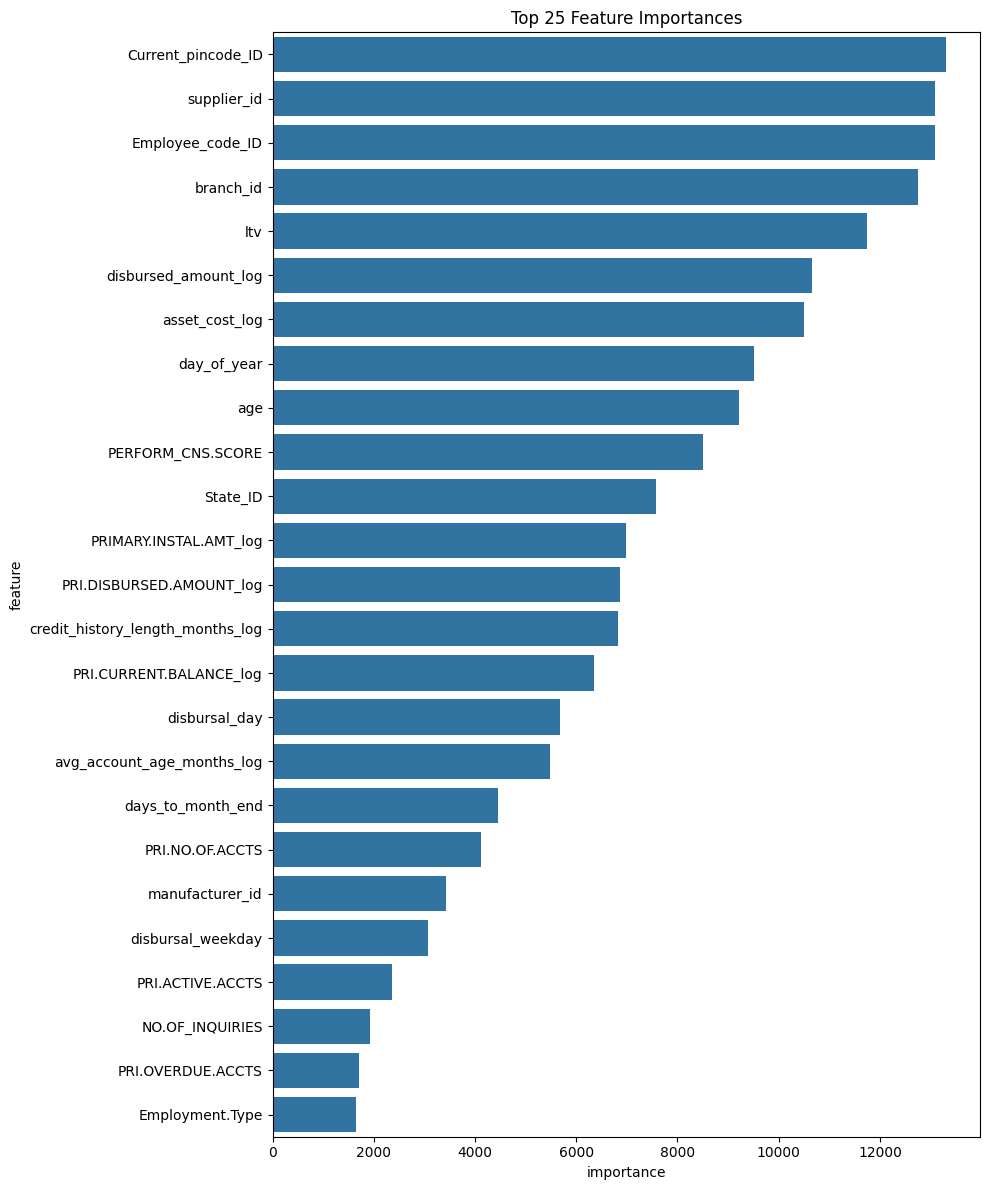


=== SHAP Interpretation ===


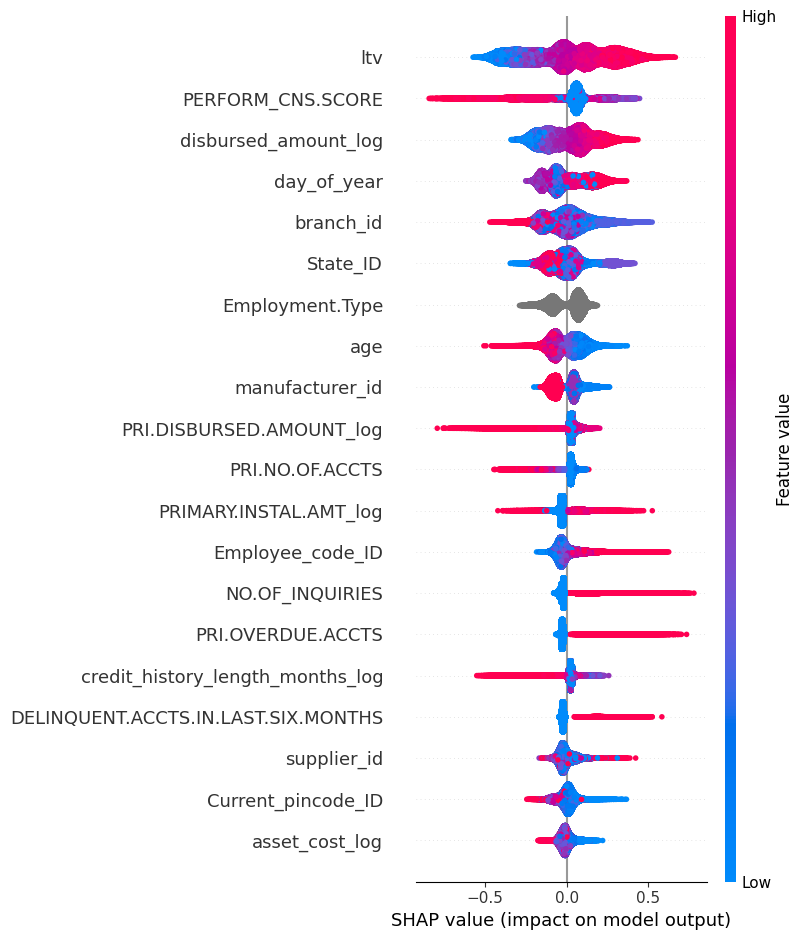

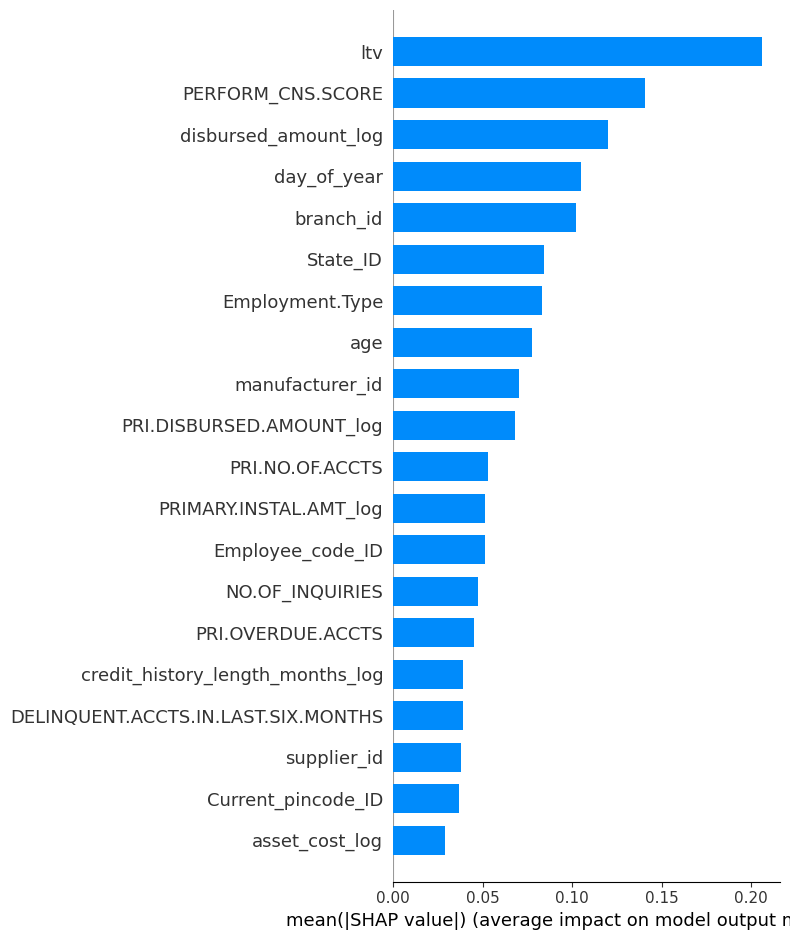

In [137]:
final_model, study, fi_df = lightgbm_optuna_experiment(df_loan_default_fe)

##### Preparing the Test Dataset for Prediction:

Loading the test dataset:

In [96]:
file_name = "test_LTFS.csv"
loan_default_test = pd.read_csv(file_name)
loan_default_test

,UniqueID,disbursed_amount,asset_cost,ltv,branch_id,supplier_id,manufacturer_id,Current_pincode_ID,Date.of.Birth,Employment.Type,...,SEC.CURRENT.BALANCE,SEC.SANCTIONED.AMOUNT,SEC.DISBURSED.AMOUNT,PRIMARY.INSTAL.AMT,SEC.INSTAL.AMT,NEW.ACCTS.IN.LAST.SIX.MONTHS,DELINQUENT.ACCTS.IN.LAST.SIX.MONTHS,AVERAGE.ACCT.AGE,CREDIT.HISTORY.LENGTH,NO.OF_INQUIRIES
0,655269,53478,63558,86.54,67,22807,45,1497,01-01-74,Salaried,...,0,0,0,0,0,0,0,0yrs 0mon,0yrs 0mon,0
1,723482,55513,63163,89.45,67,22807,45,1497,20-05-85,Self employed,...,0,0,0,5605,0,1,0,0yrs 8mon,1yrs 0mon,1
2,758529,65282,84320,79.93,78,23135,86,2071,14-10-95,Salaried,...,0,0,0,0,0,0,0,0yrs 0mon,0yrs 0mon,0
3,763449,46905,63896,76.58,78,17014,45,2070,01-06-73,Self employed,...,0,0,0,0,0,0,0,2yrs 5mon,2yrs 5mon,0
4,708663,51428,63896,86.08,78,17014,45,2069,01-06-72,Salaried,...,0,0,0,0,0,0,0,0yrs 0mon,0yrs 0mon,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
112387,755547,44875,72509,67.58,74,16646,86,2591,14-05-92,Self employed,...,0,0,0,0,0,0,0,0yrs 0mon,0yrs 0mon,0
112388,716994,53549,72509,78.61,74,16646,86,2593,24-04-84,Self employed,...,0,0,0,0,0,0,0,0yrs 0mon,0yrs 0mon,0
112389,709352,55243,72509,81.37,74,16646,86,2593,01-01-86,Self employed,...,0,0,0,0,0,0,0,4yrs 10mon,9yrs 5mon,0
112390,699795,55243,72509,81.37,74,16646,86,2593,01-01-73,Self employed,...,0,0,0,0,0,1,1,0yrs 3mon,0yrs 3mon,0


In [97]:
loan_default_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112392 entries, 0 to 112391
Data columns (total 40 columns):
 #   Column                               Non-Null Count   Dtype  
---  ------                               --------------   -----  
 0   UniqueID                             112392 non-null  int64  
 1   disbursed_amount                     112392 non-null  int64  
 2   asset_cost                           112392 non-null  int64  
 3   ltv                                  112392 non-null  float64
 4   branch_id                            112392 non-null  int64  
 5   supplier_id                          112392 non-null  int64  
 6   manufacturer_id                      112392 non-null  int64  
 7   Current_pincode_ID                   112392 non-null  int64  
 8   Date.of.Birth                        112392 non-null  object 
 9   Employment.Type                      108949 non-null  object 
 10  DisbursalDate                        112392 non-null  object 
 11  State_ID     

In [98]:
loan_default_test.isnull().sum()

UniqueID                                  0
disbursed_amount                          0
asset_cost                                0
ltv                                       0
branch_id                                 0
supplier_id                               0
manufacturer_id                           0
Current_pincode_ID                        0
Date.of.Birth                             0
Employment.Type                        3443
DisbursalDate                             0
State_ID                                  0
Employee_code_ID                          0
MobileNo_Avl_Flag                         0
Aadhar_flag                               0
PAN_flag                                  0
VoterID_flag                              0
Driving_flag                              0
Passport_flag                             0
PERFORM_CNS.SCORE                         0
PERFORM_CNS.SCORE.DESCRIPTION             0
PRI.NO.OF.ACCTS                           0
PRI.ACTIVE.ACCTS                

Converting `Date.of.Birth` and `DisbursalDate` to `datetime` and creating the `age` feature:

In [99]:
loan_default_test["Date.of.Birth"] = pd.to_datetime(loan_default_test["Date.of.Birth"], format="%d-%m-%y", dayfirst=True)
loan_default_test["DisbursalDate"] = pd.to_datetime(loan_default_test["DisbursalDate"], format="%d-%m-%y", dayfirst=True)

mask = (loan_default_test["Date.of.Birth"].dt.year > loan_default_test["DisbursalDate"].dt.year)
loan_default_test.loc[mask, "Date.of.Birth"] -= pd.DateOffset(years=100)

loan_default_test["age"] = (loan_default_test["DisbursalDate"] - loan_default_test["Date.of.Birth"]).dt.days // 365

Creating date-based features: `disbursal_day`, `disbursal_weekday`, `disbursal_month`, `days_to_month_end`, and `day_of_year`:

In [100]:
loan_default_test["disbursal_day"] = loan_default_test["DisbursalDate"].dt.day.astype("int")
loan_default_test["disbursal_weekday"] = loan_default_test["DisbursalDate"].dt.weekday.astype("int")
loan_default_test["disbursal_month"] = loan_default_test["DisbursalDate"].dt.month.astype("int")
loan_default_test["days_to_month_end"] = (loan_default_test["DisbursalDate"].dt.daysinmonth - loan_default_test["DisbursalDate"].dt.day).astype("int")
loan_default_test["day_of_year"] = loan_default_test["DisbursalDate"].dt.dayofyear.astype("int")

Checking for negative values:

In [101]:
(loan_default_test["PRI.CURRENT.BALANCE"] < 0).sum()

np.int64(218)

Replacing negative values with 0:

In [102]:
loan_default_test.loc[loan_default_test["PRI.CURRENT.BALANCE"] < 0, "PRI.CURRENT.BALANCE"] = 0

Checking for negative values:

In [103]:
(loan_default_test["SEC.CURRENT.BALANCE"] < 0).sum()

np.int64(5)

Replacing negative values with 0:

In [104]:
loan_default_test.loc[loan_default_test["SEC.CURRENT.BALANCE"] < 0, "SEC.CURRENT.BALANCE"] = 0

Converting the `AVERAGE.ACCT.AGE` feature to months:

In [105]:
loan_default_test["avg_account_age_months"] = loan_default_test["AVERAGE.ACCT.AGE"].apply(age_to_months)

Converting the `CREDIT.HISTORY.LENGTH` feature to months:

In [106]:
loan_default_test["credit_history_length_months"] = loan_default_test["CREDIT.HISTORY.LENGTH"].apply(credit_length_to_months)

Changing the `Employment.Type` feature type to category:

In [107]:
loan_default_test["Employment.Type"] = loan_default_test["Employment.Type"].astype("category")

Removing uninformative features (information redundancy, multicollinearity, low variability, weak correlation with `loan_default`):

In [108]:
loan_default_test = loan_default_test.drop(columns=["Date.of.Birth", "DisbursalDate", "PERFORM_CNS.SCORE.DESCRIPTION", "PRI.SANCTIONED.AMOUNT", "SEC.SANCTIONED.AMOUNT", "AVERAGE.ACCT.AGE", "CREDIT.HISTORY.LENGTH", "MobileNo_Avl_Flag", "Aadhar_flag", "PAN_flag", "VoterID_flag", "Driving_flag", "Passport_flag"], errors="ignore")
loan_default_test

,UniqueID,disbursed_amount,asset_cost,ltv,branch_id,supplier_id,manufacturer_id,Current_pincode_ID,Employment.Type,State_ID,...,DELINQUENT.ACCTS.IN.LAST.SIX.MONTHS,NO.OF_INQUIRIES,age,disbursal_day,disbursal_weekday,disbursal_month,days_to_month_end,day_of_year,avg_account_age_months,credit_history_length_months
0,655269,53478,63558,86.54,67,22807,45,1497,Salaried,6,...,0,0,44,3,5,11,27,307,0,0
1,723482,55513,63163,89.45,67,22807,45,1497,Self employed,6,...,0,1,33,20,1,11,10,324,8,12
2,758529,65282,84320,79.93,78,23135,86,2071,Salaried,4,...,0,0,23,29,3,11,1,333,0,0
3,763449,46905,63896,76.58,78,17014,45,2070,Self employed,4,...,0,0,45,29,3,11,1,333,29,29
4,708663,51428,63896,86.08,78,17014,45,2069,Salaried,4,...,0,0,46,17,5,11,13,321,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
112387,755547,44875,72509,67.58,74,16646,86,2591,Self employed,4,...,0,0,26,28,2,11,2,332,0,0
112388,716994,53549,72509,78.61,74,16646,86,2593,Self employed,4,...,0,0,34,19,0,11,11,323,0,0
112389,709352,55243,72509,81.37,74,16646,86,2593,Self employed,4,...,0,0,32,17,5,11,13,321,58,113
112390,699795,55243,72509,81.37,74,16646,86,2593,Self employed,4,...,1,0,45,15,3,11,15,319,3,3


Performing feature engineering:

In [109]:
df_fe_test = loan_default_test.copy()

df_fe_test["disbursed_amount_log"] = np.log1p(df_fe_test["disbursed_amount"])
df_fe_test["asset_cost_log"] = np.log1p(df_fe_test["asset_cost"])
df_fe_test["PRI.CURRENT.BALANCE_log"] = np.log1p(df_fe_test["PRI.CURRENT.BALANCE"])
df_fe_test["PRI.DISBURSED.AMOUNT_log"]  = np.log1p(df_fe_test["PRI.DISBURSED.AMOUNT"])
df_fe_test["SEC.CURRENT.BALANCE_log"] = np.log1p(df_fe_test["SEC.CURRENT.BALANCE"])
df_fe_test["SEC.DISBURSED.AMOUNT_log"] = np.log1p(df_fe_test["SEC.DISBURSED.AMOUNT"])
df_fe_test["PRIMARY.INSTAL.AMT_log"] = np.log1p(df_fe_test["PRIMARY.INSTAL.AMT"])
df_fe_test["SEC.INSTAL.AMT_log"] = np.log1p(df_fe_test["SEC.INSTAL.AMT"])
df_fe_test["avg_account_age_months_log"] = np.log1p(df_fe_test["avg_account_age_months"])
df_fe_test["credit_history_length_months_log"] = np.log1p(df_fe_test["credit_history_length_months"])

loan_default_test_fe = df_fe_test.drop(columns=["disbursed_amount", "asset_cost", "PRI.CURRENT.BALANCE", "PRI.DISBURSED.AMOUNT", "SEC.CURRENT.BALANCE", "SEC.DISBURSED.AMOUNT", "PRIMARY.INSTAL.AMT", "SEC.INSTAL.AMT", "avg_account_age_months", "credit_history_length_months"], errors="ignore")
loan_default_test_fe

,UniqueID,ltv,branch_id,supplier_id,manufacturer_id,Current_pincode_ID,Employment.Type,State_ID,Employee_code_ID,PERFORM_CNS.SCORE,...,disbursed_amount_log,asset_cost_log,PRI.CURRENT.BALANCE_log,PRI.DISBURSED.AMOUNT_log,SEC.CURRENT.BALANCE_log,SEC.DISBURSED.AMOUNT_log,PRIMARY.INSTAL.AMT_log,SEC.INSTAL.AMT_log,avg_account_age_months_log,credit_history_length_months_log
0,655269,86.54,67,22807,45,1497,Salaried,6,1998,0,...,10.887044,11.059724,0.000000,0.000000,0.0,0.0,0.000000,0.0,0.000000,0.000000
1,723482,89.45,67,22807,45,1497,Self employed,6,1998,749,...,10.924391,11.053490,10.689647,10.795096,0.0,0.0,8.631593,0.0,2.197225,2.564949
2,758529,79.93,78,23135,86,2071,Salaried,4,1646,0,...,11.086487,11.342386,0.000000,0.000000,0.0,0.0,0.000000,0.0,0.000000,0.000000
3,763449,76.58,78,17014,45,2070,Self employed,4,1646,14,...,10.755901,11.065028,11.794195,12.449023,0.0,0.0,0.000000,0.0,3.401197,3.401197
4,708663,86.08,78,17014,45,2069,Salaried,4,1646,0,...,10.847957,11.065028,0.000000,0.000000,0.0,0.0,0.000000,0.0,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
112387,755547,67.58,74,16646,86,2591,Self employed,4,3823,0,...,10.711658,11.191480,0.000000,0.000000,0.0,0.0,0.000000,0.0,0.000000,0.000000
112388,716994,78.61,74,16646,86,2593,Self employed,4,3823,0,...,10.888371,11.191480,0.000000,0.000000,0.0,0.0,0.000000,0.0,0.000000,0.000000
112389,709352,81.37,74,16646,86,2593,Self employed,4,3823,785,...,10.919515,11.191480,0.000000,0.000000,0.0,0.0,0.000000,0.0,4.077537,4.736198
112390,699795,81.37,74,16646,86,2593,Self employed,4,3823,714,...,10.919515,11.191480,10.501802,11.512935,0.0,0.0,0.000000,0.0,1.386294,1.386294


Implementation of a function for submission preparation:

In [110]:
def prepare_submission(train_df, test_df_id, final_model):

    train = train_df.copy()
    X_train = train.drop(columns=["loan_default"])
    y_train = train["loan_default"]

    test = test_df_id.copy()
    X_test = test.drop(columns=["UniqueID"])

    id_features = [
        "branch_id", "supplier_id", "manufacturer_id",
        "Current_pincode_ID", "State_ID", "Employee_code_ID"
    ]

    # Frequency Encoding
    for col in id_features:
        if col in X_train.columns:
            freq = X_train[col].value_counts(normalize=True)
            X_train[col] = X_train[col].map(freq).fillna(0)
            X_test[col] = X_test[col].map(freq).fillna(0)

    cat_features = X_train.select_dtypes(include=["category"]).columns.tolist()

    for col in cat_features:
        mode_val = X_train[col].mode()[0]
        X_train[col] = X_train[col].fillna(mode_val)
        X_test[col] = X_test[col].fillna(mode_val)

    num_features = X_train.select_dtypes(include=["int64", "float64"]).columns.tolist()
    
    for col in num_features:
        med = X_train[col].median()
        X_train[col] = X_train[col].fillna(med)
        X_test[col] = X_test[col].fillna(med)

    # Training the final_model on the entire training dataset:
    final_model.fit(
        X_train, y_train,
        eval_metric="auc",
        categorical_feature=cat_features,
    )

    # Probability predictions
    preds = final_model.predict_proba(X_test)[:, 1]

    # Submission
    submission = pd.DataFrame({
        "UniqueID": test_df_id["UniqueID"],
        "loan_default": preds
    })

    submission.to_csv("submission4.csv", index=False)
    print("submission.csv saved successfully!")

    return submission

In [ ]:
submission = prepare_submission(df_loan_default_fe, loan_default_test_fe, final_model)